# Bharat Portfolio Lab v0.4 — Forecasting and Risk Models

## Objective

This notebook develops forecasting and volatility-risk models for Indian
listed equities.

The v0.4 framework will include:

- ARIMA return forecasting
- naive benchmark forecasts
- forecast-confidence intervals
- stationarity and residual diagnostics
- ARCH/GARCH volatility forecasting
- forecast evaluation using a chronological test period
- dynamic volatility forecasts for portfolio allocation

## Research principle

Forecasting models will be evaluated against simple benchmarks rather than
assumed to be useful.

The objective is to quantify uncertainty and forecast risk, not to claim
that tomorrow's stock price can be predicted accurately.

## Dynamic-portfolio requirement

All forecasting functions must accept arbitrary NSE/BSE ticker inputs so
that they can later support user-selected portfolios in the final
application.

In [1]:
%pip install -q yfinance statsmodels arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.0 MB/s eta 0:00:00


In [2]:
# ---------------------------------------------------------
# v0.4 environment setup
# ---------------------------------------------------------

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

from arch import arch_model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf,
)

from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch,
)

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

TRADING_DAYS = 252
RISK_FREE_RATE = 0.065

DEFAULT_BENCHMARK_TICKER = "^NSEI"
DEFAULT_BENCHMARK_NAME = "Nifty 50"

DEFAULT_FORECAST_TICKERS = [
    "HDFCBANK.NS",
    "TCS.NS",
    "HINDUNILVR.NS",
    "SUNPHARMA.NS",
    "POWERGRID.NS",
    "BHARTIARTL.NS",
    "LT.NS",
    "M&M.NS",
    "BEL.NS",
    "TRENT.NS",
]

FORECAST_DATA_START = "2016-01-01"
FORECAST_TEST_START = pd.Timestamp("2024-01-01")

print("v0.4 forecasting environment prepared.")
print("Default equities:", len(DEFAULT_FORECAST_TICKERS))
print("Forecast test period begins:", FORECAST_TEST_START.date())

v0.4 forecasting environment prepared.
Default equities: 10
Forecast test period begins: 2024-01-01


## 1. Market Data and Chronological Split

Daily adjusted closing prices are downloaded for the selected Indian
equities and benchmark.

Forecasting models will be trained using observations before
1 January 2024 and evaluated only on observations from 1 January 2024
onward.

Daily log returns are used for return forecasting because stock-price
levels are generally non-stationary.

The data function accepts arbitrary ticker lists so it can later support
user-selected portfolios in the Streamlit application.

In [3]:
# ---------------------------------------------------------
# Reusable Indian market-data loader
# ---------------------------------------------------------

def download_adjusted_close_prices(
    tickers,
    benchmark_ticker="^NSEI",
    start_date="2016-01-01",
    end_date=None,
):
    """
    Download adjusted closing prices for an arbitrary list of
    NSE/BSE securities and an Indian market benchmark.
    """

    if not tickers:
        raise ValueError(
            "At least one equity ticker must be supplied."
        )

    cleaned_tickers = [
        str(ticker).strip().upper()
        for ticker in tickers
        if str(ticker).strip()
    ]

    all_tickers = list(
        dict.fromkeys(
            cleaned_tickers
            + [benchmark_ticker]
        )
    )

    if end_date is None:
        end_date = (
            pd.Timestamp.today().normalize()
            + pd.Timedelta(days=1)
        )

    raw_data = yf.download(
        tickers=all_tickers,
        start=str(pd.Timestamp(start_date).date()),
        end=str(pd.Timestamp(end_date).date()),
        auto_adjust=True,
        progress=False,
        threads=True,
    )

    if raw_data.empty:
        raise ValueError(
            "No market data was returned."
        )

    # Handle Yahoo Finance's possible column structures
    if isinstance(raw_data.columns, pd.MultiIndex):

        if "Close" in raw_data.columns.get_level_values(0):

            close_prices = (
                raw_data["Close"]
                .copy()
            )

        elif "Close" in raw_data.columns.get_level_values(1):

            close_prices = (
                raw_data
                .xs(
                    "Close",
                    axis=1,
                    level=1,
                )
                .copy()
            )

        else:
            raise ValueError(
                "Closing-price data was not returned."
            )

    else:

        if "Close" not in raw_data.columns:
            raise ValueError(
                "Closing-price data was not returned."
            )

        close_prices = raw_data[["Close"]].copy()

        if len(all_tickers) == 1:
            close_prices.columns = all_tickers

    close_prices = (
        close_prices
        .reindex(columns=all_tickers)
        .sort_index()
        .dropna(how="all")
    )

    missing_tickers = [
        ticker
        for ticker in all_tickers
        if (
            ticker not in close_prices.columns
            or close_prices[ticker].dropna().empty
        )
    ]

    if missing_tickers:
        raise ValueError(
            "No usable price history was found for: "
            + ", ".join(missing_tickers)
        )

    return close_prices

In [4]:
# ---------------------------------------------------------
# Download forecasting dataset
# ---------------------------------------------------------

forecast_price_data = download_adjusted_close_prices(
    tickers=DEFAULT_FORECAST_TICKERS,
    benchmark_ticker=DEFAULT_BENCHMARK_TICKER,
    start_date=FORECAST_DATA_START,
)

forecast_stock_prices = (
    forecast_price_data[
        DEFAULT_FORECAST_TICKERS
    ]
    .copy()
)

forecast_benchmark_prices = (
    forecast_price_data[
        DEFAULT_BENCHMARK_TICKER
    ]
    .rename(DEFAULT_BENCHMARK_NAME)
)

print("Forecasting market data downloaded.")
print("-" * 60)
print(
    "Available period:",
    forecast_price_data.index.min().date(),
    "to",
    forecast_price_data.index.max().date(),
)
print(
    "Securities:",
    len(DEFAULT_FORECAST_TICKERS),
)
print(
    "Benchmark:",
    DEFAULT_BENCHMARK_NAME,
)

Forecasting market data downloaded.
------------------------------------------------------------
Available period: 2016-01-01 to 2026-07-30
Securities: 10
Benchmark: Nifty 50


In [5]:
# ---------------------------------------------------------
# Calculate log returns and chronological split
# ---------------------------------------------------------

forecast_log_returns = (
    np.log(
        forecast_price_data
        / forecast_price_data.shift(1)
    )
)

development_log_returns = (
    forecast_log_returns.loc[
        forecast_log_returns.index
        < FORECAST_TEST_START
    ]
)

test_log_returns = (
    forecast_log_returns.loc[
        forecast_log_returns.index
        >= FORECAST_TEST_START
    ]
)

assert not development_log_returns.empty
assert not test_log_returns.empty
assert (
    development_log_returns.index.max()
    < FORECAST_TEST_START
)
assert (
    test_log_returns.index.min()
    >= FORECAST_TEST_START
)

print("Chronological forecasting split completed.")
print("-" * 60)
print(
    "Development period:",
    development_log_returns.index.min().date(),
    "to",
    development_log_returns.index.max().date(),
)
print(
    "Test period:",
    test_log_returns.index.min().date(),
    "to",
    test_log_returns.index.max().date(),
)

Chronological forecasting split completed.
------------------------------------------------------------
Development period: 2016-01-01 to 2023-12-29
Test period: 2024-01-01 to 2026-07-30


In [6]:
# ---------------------------------------------------------
# Data-quality summary by security
# ---------------------------------------------------------

data_quality_records = []

for ticker in forecast_price_data.columns:

    ticker_prices = (
        forecast_price_data[ticker]
        .dropna()
    )

    ticker_development_returns = (
        development_log_returns[ticker]
        .dropna()
    )

    ticker_test_returns = (
        test_log_returns[ticker]
        .dropna()
    )

    data_quality_records.append(
        {
            "Ticker": ticker,
            "First Price Date":
                ticker_prices.index.min().date(),

            "Latest Price Date":
                ticker_prices.index.max().date(),

            "Price Observations":
                len(ticker_prices),

            "Development Returns":
                len(ticker_development_returns),

            "Test Returns":
                len(ticker_test_returns),

            "Missing Price Values":
                forecast_price_data[ticker]
                .isna()
                .sum(),
        }
    )


forecast_data_quality = (
    pd.DataFrame(data_quality_records)
    .set_index("Ticker")
)

display(forecast_data_quality)

assert (
    forecast_data_quality[
        "Development Returns"
    ] >= 500
).all()

assert (
    forecast_data_quality[
        "Test Returns"
    ] >= 100
).all()

,First Price Date,Latest Price Date,Price Observations,Development Returns,Test Returns,Missing Price Values
Ticker,,,,,,
HDFCBANK.NS,2016-01-01,2026-07-30,2615,1974,640,0
TCS.NS,2016-01-01,2026-07-30,2615,1974,640,0
HINDUNILVR.NS,2016-01-01,2026-07-30,2615,1974,640,0
SUNPHARMA.NS,2016-01-01,2026-07-30,2615,1974,640,0
POWERGRID.NS,2016-01-01,2026-07-30,2615,1974,640,0
BHARTIARTL.NS,2016-01-01,2026-07-30,2615,1974,640,0
LT.NS,2016-01-01,2026-07-30,2615,1974,640,0
M&M.NS,2016-01-01,2026-07-30,2615,1974,640,0
BEL.NS,2016-01-01,2026-07-30,2615,1974,640,0


## 2. Return-Series Stationarity Diagnostics

ARIMA models require the modelled time series to be reasonably
stationary.

A stationary series has statistical properties such as its mean and
variance that remain broadly stable through time.

Daily stock-price levels are usually non-stationary. Daily log returns
are generally more suitable for ARIMA modelling.

The Augmented Dickey–Fuller test is applied only to development-period
returns.

### Hypotheses

- **Null hypothesis:** the series contains a unit root and is non-stationary
- **Alternative hypothesis:** the series is stationary

A p-value below 5% leads to rejection of the null hypothesis.

In [7]:
# ---------------------------------------------------------
# Reusable Augmented Dickey–Fuller diagnostic
# ---------------------------------------------------------

def run_adf_stationarity_test(
    time_series,
    significance_level=0.05,
):
    """
    Run the Augmented Dickey–Fuller stationarity test
    on one return series.
    """

    clean_series = (
        pd.Series(time_series)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    if len(clean_series) < 100:
        raise ValueError(
            "At least 100 observations are required "
            "for the stationarity test."
        )

    adf_result = adfuller(
        clean_series,
        autolag="AIC",
    )

    adf_statistic = adf_result[0]
    p_value = adf_result[1]
    selected_lags = adf_result[2]
    observations = adf_result[3]
    critical_values = adf_result[4]

    is_stationary = (
        p_value < significance_level
    )

    return {
        "ADF Statistic": adf_statistic,
        "P-Value": p_value,
        "Selected Lags": selected_lags,
        "Observations": observations,
        "1% Critical Value": critical_values["1%"],
        "5% Critical Value": critical_values["5%"],
        "10% Critical Value": critical_values["10%"],
        "Stationary at 5%": is_stationary,
    }

In [8]:
# ---------------------------------------------------------
# Development-period stationarity testing
# ---------------------------------------------------------

stationarity_records = []

for ticker in development_log_returns.columns:

    ticker_result = run_adf_stationarity_test(
        development_log_returns[ticker]
    )

    stationarity_records.append(
        {
            "Ticker": ticker,
            **ticker_result,
        }
    )

stationarity_results = (
    pd.DataFrame(stationarity_records)
    .set_index("Ticker")
)

print("Development-Period ADF Stationarity Results")
display(
    stationarity_results.style.format(
        {
            "ADF Statistic": "{:.4f}",
            "P-Value": "{:.6f}",
            "1% Critical Value": "{:.4f}",
            "5% Critical Value": "{:.4f}",
            "10% Critical Value": "{:.4f}",
        }
    )
)

Development-Period ADF Stationarity Results


,ADF Statistic,P-Value,Selected Lags,Observations,1% Critical Value,5% Critical Value,10% Critical Value,Stationary at 5%
Ticker,,,,,,,,
HDFCBANK.NS,-9.9991,0.000000,21,1952,-3.4337,-2.8630,-2.5676,True
TCS.NS,-45.1341,0.000000,0,1973,-3.4337,-2.8630,-2.5676,True
HINDUNILVR.NS,-15.9853,0.000000,6,1967,-3.4337,-2.8630,-2.5676,True
SUNPHARMA.NS,-44.8964,0.000000,0,1973,-3.4337,-2.8630,-2.5676,True
POWERGRID.NS,-19.3835,0.000000,6,1967,-3.4337,-2.8630,-2.5676,True
BHARTIARTL.NS,-33.2717,0.000000,1,1972,-3.4337,-2.8630,-2.5676,True
LT.NS,-14.2411,0.000000,8,1965,-3.4337,-2.8630,-2.5676,True
M&M.NS,-17.1088,0.000000,5,1968,-3.4337,-2.8630,-2.5676,True
BEL.NS,-16.3297,0.000000,6,1967,-3.4337,-2.8630,-2.5676,True


In [9]:
stationary_series_count = int(
    stationarity_results[
        "Stationary at 5%"
    ].sum()
)

total_series_count = len(
    stationarity_results
)

stationarity_summary = pd.DataFrame(
    {
        "Result": [
            total_series_count,
            stationary_series_count,
            total_series_count
            - stationary_series_count,
            stationary_series_count
            / total_series_count,
        ],
    },
    index=[
        "Series Tested",
        "Stationary at 5%",
        "Non-Stationary at 5%",
        "Stationary Percentage",
    ],
)

formatted_stationarity_summary = (
    stationarity_summary
    .copy()
    .astype(object)
)

formatted_stationarity_summary.loc[
    "Stationary Percentage",
    "Result",
] = (
    f"{stationary_series_count / total_series_count:.2%}"
)

print("Stationarity Summary")
display(formatted_stationarity_summary)

Stationarity Summary


,Result
Series Tested,11.0
Stationary at 5%,11.0
Non-Stationary at 5%,0.0
Stationary Percentage,100.00%


## 3. ARIMA Order Selection

Because all development-period log-return series passed the stationarity
test, the integration order is fixed at zero.

Candidate ARIMA(p, 0, q) models are compared using only development-period
data.

The preferred order is selected using the Bayesian Information Criterion
(BIC). BIC rewards goodness of fit but penalises unnecessary model
complexity more strongly than AIC.

No observations from the out-of-sample test period are used during model
selection.

In [10]:
# ---------------------------------------------------------
# Reusable ARIMA order-selection function
# ---------------------------------------------------------

def select_arima_order(
    time_series,
    p_values=range(0, 4),
    q_values=range(0, 4),
    selection_criterion="BIC",
):
    """
    Compare ARIMA(p, 0, q) models using development data only.

    Returns:
        selected_order
        ranked_results
        fitted_models
    """

    clean_series = (
        pd.Series(time_series)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    if len(clean_series) < 500:
        raise ValueError(
            "At least 500 observations are required "
            "for ARIMA order selection."
        )

    # Percentage scaling improves numerical optimisation.
    scaled_series = clean_series * 100

    selection_records = []
    fitted_models = {}

    for p_value in p_values:

        for q_value in q_values:

            model_order = (
                int(p_value),
                0,
                int(q_value),
            )

            try:

                with warnings.catch_warnings():

                    warnings.simplefilter(
                        "ignore"
                    )

                    fitted_model = ARIMA(
                        scaled_series,
                        order=model_order,
                        trend="c",
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit()

                converged = bool(
                    fitted_model.mle_retvals.get(
                        "converged",
                        True,
                    )
                )

                selection_records.append(
                    {
                        "Order": model_order,
                        "p": p_value,
                        "d": 0,
                        "q": q_value,
                        "AIC": fitted_model.aic,
                        "BIC": fitted_model.bic,
                        "HQIC": fitted_model.hqic,
                        "Log Likelihood": fitted_model.llf,
                        "Parameters": len(
                            fitted_model.params
                        ),
                        "Converged": converged,
                    }
                )

                fitted_models[
                    model_order
                ] = fitted_model

            except Exception as error:

                selection_records.append(
                    {
                        "Order": model_order,
                        "p": p_value,
                        "d": 0,
                        "q": q_value,
                        "AIC": np.nan,
                        "BIC": np.nan,
                        "HQIC": np.nan,
                        "Log Likelihood": np.nan,
                        "Parameters": np.nan,
                        "Converged": False,
                        "Error": str(error),
                    }
                )

    order_results = pd.DataFrame(
        selection_records
    )

    criterion_column = (
        selection_criterion
        .strip()
        .upper()
    )

    allowed_criteria = {
        "AIC",
        "BIC",
        "HQIC",
    }

    if criterion_column not in allowed_criteria:
        raise ValueError(
            "Selection criterion must be AIC, BIC or HQIC."
        )

    valid_results = (
        order_results.loc[
            order_results["Converged"]
            & order_results[
                criterion_column
            ].notna()
        ]
        .sort_values(
            criterion_column,
            ascending=True,
        )
        .reset_index(drop=True)
    )

    if valid_results.empty:
        raise RuntimeError(
            "No ARIMA candidate converged successfully."
        )

    selected_order = tuple(
        valid_results.loc[
            0,
            ["p", "d", "q"],
        ].astype(int)
    )

    return {
        "Selected Order": selected_order,
        "Ranked Results": valid_results,
        "All Results": order_results,
        "Fitted Models": fitted_models,
        "Selection Criterion": criterion_column,
    }

In [11]:
# ---------------------------------------------------------
# Nifty 50 development-period ARIMA selection
# ---------------------------------------------------------

benchmark_arima_selection = select_arima_order(
    time_series=development_log_returns[
        DEFAULT_BENCHMARK_TICKER
    ],
    p_values=range(0, 4),
    q_values=range(0, 4),
    selection_criterion="BIC",
)

benchmark_arima_order = (
    benchmark_arima_selection[
        "Selected Order"
    ]
)

benchmark_arima_ranking = (
    benchmark_arima_selection[
        "Ranked Results"
    ]
)

print("Nifty 50 ARIMA Order Selection")
print("-" * 60)
print(
    "Selected order:",
    benchmark_arima_order,
)
print(
    "Selection criterion:",
    benchmark_arima_selection[
        "Selection Criterion"
    ],
)
print(
    "Successful candidate models:",
    len(benchmark_arima_ranking),
)

display(
    benchmark_arima_ranking[
        [
            "Order",
            "AIC",
            "BIC",
            "HQIC",
            "Log Likelihood",
            "Parameters",
        ]
    ]
    .head(10)
    .style.format(
        {
            "AIC": "{:.2f}",
            "BIC": "{:.2f}",
            "HQIC": "{:.2f}",
            "Log Likelihood": "{:.2f}",
            "Parameters": "{:.0f}",
        }
    )
)

Nifty 50 ARIMA Order Selection
------------------------------------------------------------
Selected order: (2, 0, 3)
Selection criterion: BIC
Successful candidate models: 15


,Order,AIC,BIC,HQIC,Log Likelihood,Parameters
0,"(2, 0, 3)",5799.69,5838.75,5814.05,-2892.84,7
1,"(3, 0, 3)",5802.79,5847.43,5819.20,-2893.40,8
2,"(0, 0, 0)",5856.33,5867.49,5860.43,-2926.16,2
3,"(0, 0, 1)",5854.66,5871.40,5860.81,-2924.33,3
4,"(0, 0, 2)",5849.35,5871.67,5857.55,-2920.67,4
5,"(1, 0, 3)",5839.20,5872.68,5851.51,-2913.60,6
6,"(1, 0, 0)",5856.98,5873.73,5863.14,-2925.49,3
7,"(3, 0, 1)",5840.92,5874.41,5853.23,-2914.46,6
8,"(0, 0, 3)",5848.83,5876.73,5859.09,-2919.42,5
9,"(1, 0, 1)",5855.89,5878.21,5864.09,-2923.94,4


## 4. ARIMA Residual Diagnostics

A fitted ARIMA model should leave residuals that resemble unpredictable
noise.

The following development-period diagnostics are applied:

- **Ljung–Box test:** checks whether residual autocorrelation remains
- **ARCH LM test:** checks whether residual volatility clustering remains
- **Jarque–Bera test:** checks whether residuals are normally distributed

### Interpretation

For the Ljung–Box test, a p-value above 5% suggests that the ARIMA model
has adequately captured linear return dependence.

For the ARCH LM test, a p-value below 5% indicates remaining volatility
clustering and supports the later use of an ARCH/GARCH model.

For the Jarque–Bera test, a p-value below 5% indicates non-normal residuals,
such as skewness or fat tails.

In [12]:
# ---------------------------------------------------------
# Retrieve the selected development-period ARIMA model
# ---------------------------------------------------------

from scipy.stats import (
    jarque_bera,
    kurtosis,
    skew,
)

benchmark_arima_model = (
    benchmark_arima_selection[
        "Fitted Models"
    ][benchmark_arima_order]
)

benchmark_arima_residuals = (
    pd.Series(
        benchmark_arima_model.resid
    )
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .astype(float)
)

selected_p = benchmark_arima_order[0]
selected_q = benchmark_arima_order[2]

print("Selected ARIMA order:", benchmark_arima_order)
print(
    "Residual observations:",
    f"{len(benchmark_arima_residuals):,}",
)
print(
    "Residual mean:",
    f"{benchmark_arima_residuals.mean():.6f}",
)
print(
    "Residual standard deviation:",
    f"{benchmark_arima_residuals.std(ddof=1):.6f}",
)

Selected ARIMA order: (2, 0, 3)
Residual observations: 1,963
Residual mean: -0.003903
Residual standard deviation: 1.065262


In [13]:
# ---------------------------------------------------------
# Ljung–Box residual-autocorrelation tests
# ---------------------------------------------------------

ljung_box_results = acorr_ljungbox(
    benchmark_arima_residuals,
    lags=[10, 20],
    model_df=selected_p + selected_q,
    return_df=True,
)


# ---------------------------------------------------------
# ARCH LM volatility-clustering test
# ---------------------------------------------------------

(
    arch_lm_statistic,
    arch_lm_p_value,
    arch_f_statistic,
    arch_f_p_value,
) = het_arch(
    benchmark_arima_residuals,
    nlags=10,
)


# ---------------------------------------------------------
# Jarque–Bera residual-normality test
# ---------------------------------------------------------

jarque_bera_result = jarque_bera(
    benchmark_arima_residuals
)

jarque_bera_statistic = (
    jarque_bera_result.statistic
)

jarque_bera_p_value = (
    jarque_bera_result.pvalue
)


# ---------------------------------------------------------
# Combine diagnostic results
# ---------------------------------------------------------

arima_diagnostic_results = pd.DataFrame(
    {
        "Test Statistic": [
            ljung_box_results.loc[
                10,
                "lb_stat",
            ],
            ljung_box_results.loc[
                20,
                "lb_stat",
            ],
            arch_lm_statistic,
            jarque_bera_statistic,
        ],
        "P-Value": [
            ljung_box_results.loc[
                10,
                "lb_pvalue",
            ],
            ljung_box_results.loc[
                20,
                "lb_pvalue",
            ],
            arch_lm_p_value,
            jarque_bera_p_value,
        ],
    },
    index=[
        "Ljung–Box Residual Autocorrelation — 10 Lags",
        "Ljung–Box Residual Autocorrelation — 20 Lags",
        "ARCH LM Volatility Clustering — 10 Lags",
        "Jarque–Bera Residual Normality",
    ],
)

arima_diagnostic_results[
    "Result at 5%"
] = [
    (
        "No significant residual autocorrelation"
        if ljung_box_results.loc[10, "lb_pvalue"] >= 0.05
        else "Residual autocorrelation remains"
    ),
    (
        "No significant residual autocorrelation"
        if ljung_box_results.loc[20, "lb_pvalue"] >= 0.05
        else "Residual autocorrelation remains"
    ),
    (
        "ARCH effects remain"
        if arch_lm_p_value < 0.05
        else "No significant ARCH effects"
    ),
    (
        "Residuals are non-normal"
        if jarque_bera_p_value < 0.05
        else "Normality not rejected"
    ),
]

print("Nifty 50 ARIMA Residual Diagnostics")

display(
    arima_diagnostic_results.style.format(
        {
            "Test Statistic": "{:.4f}",
            "P-Value": "{:.6f}",
        }
    )
)

print("\nResidual distribution statistics")
print("-" * 55)
print(
    "Skewness:",
    f"{skew(benchmark_arima_residuals):.4f}",
)
print(
    "Excess kurtosis:",
    f"{kurtosis(benchmark_arima_residuals):.4f}",
)

Nifty 50 ARIMA Residual Diagnostics


,Test Statistic,P-Value,Result at 5%
Ljung–Box Residual Autocorrelation — 10 Lags,18.8888,0.002016,Residual autocorrelation remains
Ljung–Box Residual Autocorrelation — 20 Lags,23.3407,0.077169,No significant residual autocorrelation
ARCH LM Volatility Clustering — 10 Lags,579.1630,0.000000,ARCH effects remain
Jarque–Bera Residual Normality,25942.2475,0.000000,Residuals are non-normal



Residual distribution statistics
-------------------------------------------------------
Skewness: -1.1442
Excess kurtosis: 17.6618


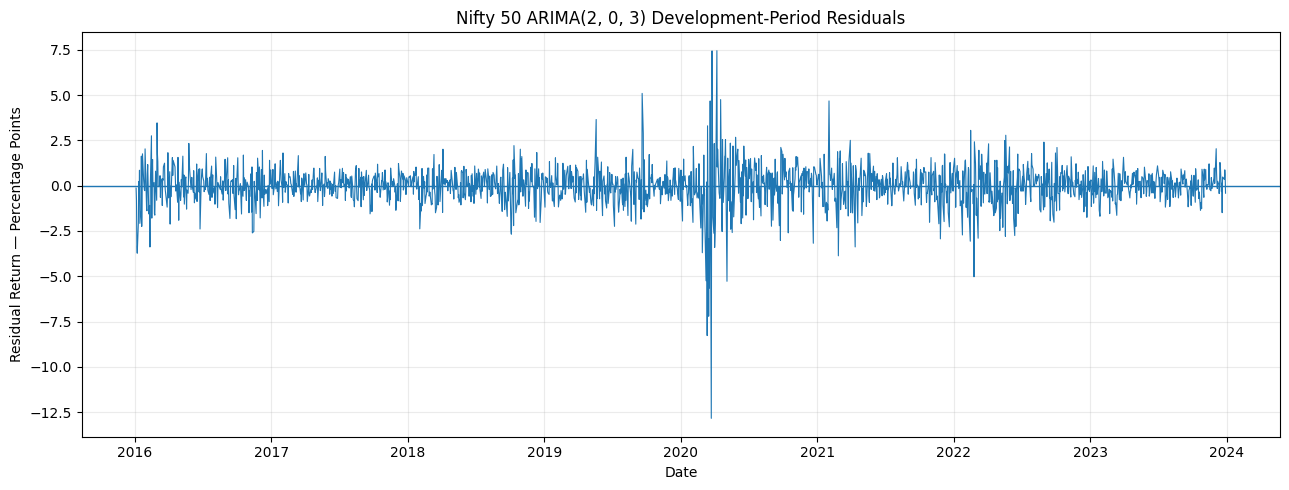

In [14]:
plt.figure(figsize=(13, 5))

plt.plot(
    benchmark_arima_residuals.index,
    benchmark_arima_residuals,
    linewidth=0.8,
)

plt.axhline(
    0,
    linewidth=1,
)

plt.title(
    "Nifty 50 ARIMA(2, 0, 3) Development-Period Residuals"
)
plt.xlabel("Date")
plt.ylabel("Residual Return — Percentage Points")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

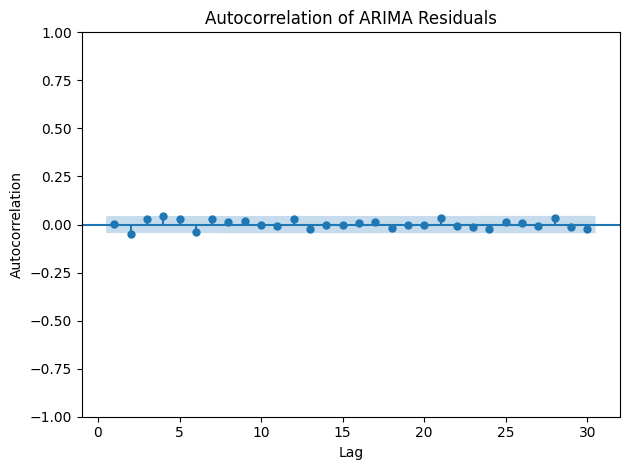

In [15]:
plot_acf(
    benchmark_arima_residuals,
    lags=30,
    zero=False,
)

plt.title(
    "Autocorrelation of ARIMA Residuals"
)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

## 5. ARIMA Diagnostic Interpretation

The selected ARIMA(2, 0, 3) model does not fully explain Nifty 50
daily log-return behaviour.

### Residual autocorrelation

The Ljung–Box test at 10 lags produced a p-value of 0.0020.

The null hypothesis of no residual autocorrelation is therefore rejected
at the 5% significance level. Some short-horizon linear dependence remains
after fitting the ARIMA model.

At 20 lags, the Ljung–Box p-value was 0.0772. The null hypothesis is not
rejected at the 5% level, suggesting that residual autocorrelation is less
evident across the broader lag window.

The mixed result means that the ARIMA model captures part, but not all, of
the return-series dependence.

### Volatility clustering

The ARCH LM test produced a p-value below 0.001.

Strong conditional heteroskedasticity therefore remains in the ARIMA
residuals. Large residual movements tend to be followed by further large
movements, while quiet observations tend to cluster together.

This provides statistical justification for modelling residual volatility
using an ARCH or GARCH framework.

### Residual distribution

The Jarque–Bera test rejected residual normality with a p-value below
0.001.

The residual distribution therefore contains material departures from
normality, such as asymmetry, fat tails or extreme observations.

Normal-distribution forecast intervals may consequently understate the
probability of large market movements.

### Research conclusion

ARIMA(2, 0, 3) should be treated as a candidate conditional-mean model,
not as a complete return-generating model.

Its forecasting value must still be tested against simple naive
benchmarks during the out-of-sample period.

The remaining volatility clustering supports combining the mean model
with GARCH volatility forecasts. A heavy-tailed innovation distribution,
such as the Student's t distribution, should also be considered.

## 6. Out-of-Sample ARIMA Forecast Evaluation

The selected ARIMA(2, 0, 3) model is evaluated using sequential
one-trading-day-ahead forecasts during the test period.

For each test observation:

1. A forecast is generated using only information available before that day.
2. The actual return is then revealed.
3. The observation is added to the model history without refitting the
   model parameters.

The ARIMA forecasts are compared with three simple benchmarks:

- zero-return forecast,
- previous-day return forecast, and
- expanding historical-mean forecast.

A complex model should not be considered useful merely because it fits
historical data. It must improve meaningfully on these naive alternatives.

In [16]:
# ---------------------------------------------------------
# Sequential one-step-ahead forecasts
# ---------------------------------------------------------

benchmark_test_returns = (
    test_log_returns[
        DEFAULT_BENCHMARK_TICKER
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .astype(float)
)

benchmark_development_returns = (
    development_log_returns[
        DEFAULT_BENCHMARK_TICKER
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .astype(float)
)

recursive_arima_model = (
    benchmark_arima_model
)

return_history = (
    benchmark_development_returns
    .copy()
)

forecast_records = []

for forecast_date, actual_return in (
    benchmark_test_returns.items()
):

    # Forecast is in percentage-point units because
    # the ARIMA model was fitted to returns multiplied by 100.
    forecast_result = (
        recursive_arima_model
        .get_forecast(steps=1)
    )

    arima_forecast_percentage = float(
        np.asarray(
            forecast_result.predicted_mean
        ).reshape(-1)[0]
    )

    confidence_interval = np.asarray(
        forecast_result.conf_int(
            alpha=0.05
        )
    ).reshape(-1, 2)[0]

    lower_forecast_percentage = float(
        confidence_interval[0]
    )

    upper_forecast_percentage = float(
        confidence_interval[1]
    )

    previous_day_forecast = float(
        return_history.iloc[-1]
    )

    expanding_mean_forecast = float(
        return_history.mean()
    )

    forecast_records.append(
        {
            "Date": forecast_date,
            "Actual Return": actual_return,
            "ARIMA Forecast":
                arima_forecast_percentage / 100,
            "ARIMA Lower 95%":
                lower_forecast_percentage / 100,
            "ARIMA Upper 95%":
                upper_forecast_percentage / 100,
            "Zero-Return Forecast": 0.0,
            "Previous-Day Forecast":
                previous_day_forecast,
            "Expanding-Mean Forecast":
                expanding_mean_forecast,
        }
    )

    # Reveal the actual observation only after forecasting.
    recursive_arima_model = (
        recursive_arima_model.append(
            [actual_return * 100],
            refit=False,
        )
    )

    return_history.loc[
        forecast_date
    ] = actual_return


benchmark_forecasts = (
    pd.DataFrame(forecast_records)
    .set_index("Date")
    .sort_index()
)

assert len(benchmark_forecasts) == len(
    benchmark_test_returns
)

assert benchmark_forecasts.isna().sum().sum() == 0

print("Sequential ARIMA forecasts completed.")
print("-" * 60)
print(
    "Forecast period:",
    benchmark_forecasts.index.min().date(),
    "to",
    benchmark_forecasts.index.max().date(),
)
print(
    "One-step forecasts:",
    f"{len(benchmark_forecasts):,}",
)

display(benchmark_forecasts.head())

Sequential ARIMA forecasts completed.
------------------------------------------------------------
Forecast period: 2024-01-01 to 2026-07-30
One-step forecasts: 632


,Actual Return,ARIMA Forecast,ARIMA Lower 95%,ARIMA Upper 95%,Zero-Return Forecast,Previous-Day Forecast,Expanding-Mean Forecast
Date,,,,,,,
2024-01-01,0.000483,0.000038,-0.020710,0.020785,0.0,-0.002174,0.000512
2024-01-02,-0.003506,0.000090,-0.020658,0.020838,0.0,0.000483,0.000512
2024-01-03,-0.006875,0.001272,-0.019476,0.022020,0.0,-0.003506,0.000510
2024-01-04,0.006543,-0.000547,-0.021295,0.020201,0.0,-0.006875,0.000506
2024-01-05,0.002407,0.000613,-0.020134,0.021361,0.0,0.006543,0.000509


In [17]:
# ---------------------------------------------------------
# Reusable forecast-evaluation function
# ---------------------------------------------------------

def calculate_forecast_accuracy(
    actual_returns,
    forecast_returns,
):
    """
    Calculate standard point-forecast accuracy statistics.
    """

    evaluation_data = pd.concat(
        [
            pd.Series(
                actual_returns,
                name="Actual",
            ),
            pd.Series(
                forecast_returns,
                name="Forecast",
            ),
        ],
        axis=1,
    ).dropna()

    errors = (
        evaluation_data["Forecast"]
        - evaluation_data["Actual"]
    )

    mae = mean_absolute_error(
        evaluation_data["Actual"],
        evaluation_data["Forecast"],
    )

    rmse = np.sqrt(
        mean_squared_error(
            evaluation_data["Actual"],
            evaluation_data["Forecast"],
        )
    )

    directional_accuracy = (
        np.sign(
            evaluation_data["Forecast"]
        )
        == np.sign(
            evaluation_data["Actual"]
        )
    ).mean()

    return {
        "Observations": len(evaluation_data),
        "MAE": mae,
        "RMSE": rmse,
        "Forecast Bias": errors.mean(),
        "Directional Accuracy":
            directional_accuracy,
        "Forecast–Actual Correlation":
            evaluation_data[
                "Forecast"
            ].corr(
                evaluation_data["Actual"]
            ),
    }


forecast_model_columns = {
    "ARIMA(2, 0, 3)":
        "ARIMA Forecast",

    "Zero-Return Benchmark":
        "Zero-Return Forecast",

    "Previous-Day Benchmark":
        "Previous-Day Forecast",

    "Expanding-Mean Benchmark":
        "Expanding-Mean Forecast",
}

forecast_accuracy_records = []

for model_name, forecast_column in (
    forecast_model_columns.items()
):

    model_metrics = (
        calculate_forecast_accuracy(
            actual_returns=
                benchmark_forecasts[
                    "Actual Return"
                ],
            forecast_returns=
                benchmark_forecasts[
                    forecast_column
                ],
        )
    )

    forecast_accuracy_records.append(
        {
            "Forecast Model": model_name,
            **model_metrics,
        }
    )


forecast_accuracy_results = (
    pd.DataFrame(
        forecast_accuracy_records
    )
    .set_index("Forecast Model")
    .sort_values("RMSE")
)

zero_benchmark_rmse = (
    forecast_accuracy_results.loc[
        "Zero-Return Benchmark",
        "RMSE",
    ]
)

forecast_accuracy_results[
    "RMSE Improvement vs Zero"
] = (
    1
    - forecast_accuracy_results["RMSE"]
    / zero_benchmark_rmse
)

print("Out-of-Sample Forecast Accuracy")

display(
    forecast_accuracy_results.style.format(
        {
            "Observations": "{:,.0f}",
            "MAE": "{:.4%}",
            "RMSE": "{:.4%}",
            "Forecast Bias": "{:+.4%}",
            "Directional Accuracy": "{:.2%}",
            "Forecast–Actual Correlation": "{:.4f}",
            "RMSE Improvement vs Zero": "{:+.2%}",
        }
    )
)

Out-of-Sample Forecast Accuracy


,Observations,MAE,RMSE,Forecast Bias,Directional Accuracy,Forecast–Actual Correlation,RMSE Improvement vs Zero
Forecast Model,,,,,,,
Zero-Return Benchmark,632,0.6160%,0.8648%,-0.0199%,0.16%,nan,+0.00%
Expanding-Mean Benchmark,632,0.6158%,0.8652%,+0.0289%,52.22%,-0.0413,-0.05%
"ARIMA(2, 0, 3)",632,0.6308%,0.8780%,+0.0300%,49.05%,-0.0301,-1.52%
Previous-Day Benchmark,632,0.8907%,1.2780%,-0.0008%,52.37%,-0.0925,-47.78%


In [18]:
# ---------------------------------------------------------
# Forecast-interval coverage
# ---------------------------------------------------------

arima_interval_coverage = (
    (
        benchmark_forecasts[
            "Actual Return"
        ]
        >= benchmark_forecasts[
            "ARIMA Lower 95%"
        ]
    )
    & (
        benchmark_forecasts[
            "Actual Return"
        ]
        <= benchmark_forecasts[
            "ARIMA Upper 95%"
        ]
    )
).mean()

average_interval_width = (
    benchmark_forecasts[
        "ARIMA Upper 95%"
    ]
    - benchmark_forecasts[
        "ARIMA Lower 95%"
    ]
).mean()

arima_interval_summary = pd.DataFrame(
    {
        "Result": [
            arima_interval_coverage,
            average_interval_width,
            0.95,
        ],
    },
    index=[
        "Observed 95% Interval Coverage",
        "Average 95% Interval Width",
        "Target Interval Coverage",
    ],
)

formatted_interval_summary = (
    arima_interval_summary
    .copy()
    .astype(object)
)

for metric in formatted_interval_summary.index:

    formatted_interval_summary.loc[
        metric,
        "Result",
    ] = (
        f"{arima_interval_summary.loc[metric, 'Result']:.2%}"
    )

print("ARIMA Forecast-Interval Summary")
display(formatted_interval_summary)

ARIMA Forecast-Interval Summary


,Result
Observed 95% Interval Coverage,97.63%
Average 95% Interval Width,4.15%
Target Interval Coverage,95.00%


## 7. ARCH and GARCH Model Selection

The ARIMA residual diagnostics revealed strong volatility clustering and
non-normality.

ARCH-family models are therefore fitted to the development-period ARIMA
residuals.

The candidate set includes:

- ARCH(1) with normal innovations
- ARCH(1) with Student's t innovations
- GARCH(1,1) with normal innovations
- GARCH(1,1) with Student's t innovations
- GJR-GARCH(1,1) with normal innovations
- GJR-GARCH(1,1) with Student's t innovations

The GJR-GARCH specification allows negative and positive shocks to have
different effects on future volatility.

Student's t innovations allow for heavier tails than the normal
distribution.

Models are ranked using BIC and only development-period residuals are used.

In [19]:
# ---------------------------------------------------------
# Prepare development-period ARIMA residuals
# ---------------------------------------------------------

arima_residual_burn_in = max(
    benchmark_arima_order[0],
    benchmark_arima_order[2],
    1,
)

garch_development_residuals = (
    benchmark_arima_residuals
    .iloc[arima_residual_burn_in:]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .astype(float)
)

print("GARCH development residuals prepared.")
print("-" * 60)
print(
    "Observations:",
    f"{len(garch_development_residuals):,}",
)
print(
    "Units:",
    "daily return percentage points",
)

GARCH development residuals prepared.
------------------------------------------------------------
Observations: 1,960
Units: daily return percentage points


In [20]:
# ---------------------------------------------------------
# ARCH/GARCH candidate specifications
# ---------------------------------------------------------

volatility_candidate_specs = {
    "ARCH(1) — Normal": {
        "vol": "ARCH",
        "p": 1,
        "o": 0,
        "q": 0,
        "dist": "normal",
    },
    "ARCH(1) — Student's t": {
        "vol": "ARCH",
        "p": 1,
        "o": 0,
        "q": 0,
        "dist": "t",
    },
    "GARCH(1,1) — Normal": {
        "vol": "GARCH",
        "p": 1,
        "o": 0,
        "q": 1,
        "dist": "normal",
    },
    "GARCH(1,1) — Student's t": {
        "vol": "GARCH",
        "p": 1,
        "o": 0,
        "q": 1,
        "dist": "t",
    },
    "GJR-GARCH(1,1) — Normal": {
        "vol": "GARCH",
        "p": 1,
        "o": 1,
        "q": 1,
        "dist": "normal",
    },
    "GJR-GARCH(1,1) — Student's t": {
        "vol": "GARCH",
        "p": 1,
        "o": 1,
        "q": 1,
        "dist": "t",
    },
}

In [21]:
# ---------------------------------------------------------
# Fit and compare volatility models
# ---------------------------------------------------------

volatility_selection_records = []
fitted_volatility_models = {}

for model_name, model_spec in (
    volatility_candidate_specs.items()
):

    try:

        with warnings.catch_warnings():

            warnings.simplefilter("ignore")

            candidate_model = arch_model(
                garch_development_residuals,
                mean="Zero",
                vol=model_spec["vol"],
                p=model_spec["p"],
                o=model_spec["o"],
                q=model_spec["q"],
                dist=model_spec["dist"],
                rescale=False,
            )

            fitted_model = candidate_model.fit(
                disp="off",
            )

        converged = (
            fitted_model.convergence_flag == 0
        )

        model_parameters = fitted_model.params

        alpha_value = float(
            model_parameters.get(
                "alpha[1]",
                0.0,
            )
        )

        beta_value = float(
            model_parameters.get(
                "beta[1]",
                0.0,
            )
        )

        gamma_value = float(
            model_parameters.get(
                "gamma[1]",
                0.0,
            )
        )

        # Under a symmetric innovation distribution, the
        # GJR persistence approximation includes half gamma.
        persistence = (
            alpha_value
            + beta_value
            + 0.5 * gamma_value
        )

        volatility_selection_records.append(
            {
                "Model": model_name,
                "AIC": fitted_model.aic,
                "BIC": fitted_model.bic,
                "Log Likelihood":
                    fitted_model.loglikelihood,
                "Parameters":
                    len(fitted_model.params),
                "Alpha": alpha_value,
                "Beta": beta_value,
                "Gamma": gamma_value,
                "Persistence": persistence,
                "Degrees of Freedom":
                    float(
                        model_parameters.get(
                            "nu",
                            np.nan,
                        )
                    ),
                "Converged": converged,
            }
        )

        fitted_volatility_models[
            model_name
        ] = fitted_model

    except Exception as error:

        volatility_selection_records.append(
            {
                "Model": model_name,
                "AIC": np.nan,
                "BIC": np.nan,
                "Log Likelihood": np.nan,
                "Parameters": np.nan,
                "Alpha": np.nan,
                "Beta": np.nan,
                "Gamma": np.nan,
                "Persistence": np.nan,
                "Degrees of Freedom": np.nan,
                "Converged": False,
                "Error": str(error),
            }
        )


volatility_model_comparison = (
    pd.DataFrame(
        volatility_selection_records
    )
    .set_index("Model")
)

valid_volatility_models = (
    volatility_model_comparison.loc[
        volatility_model_comparison[
            "Converged"
        ]
        & volatility_model_comparison[
            "BIC"
        ].notna()
    ]
    .sort_values("BIC")
)

if valid_volatility_models.empty:
    raise RuntimeError(
        "No ARCH/GARCH candidate converged."
    )

selected_volatility_model_name = (
    valid_volatility_models.index[0]
)

selected_volatility_model = (
    fitted_volatility_models[
        selected_volatility_model_name
    ]
)

print("ARCH/GARCH Model Selection")
print("-" * 60)
print(
    "Selected model:",
    selected_volatility_model_name,
)
print(
    "Selection criterion: BIC"
)

display(
    valid_volatility_models.style.format(
        {
            "AIC": "{:.2f}",
            "BIC": "{:.2f}",
            "Log Likelihood": "{:.2f}",
            "Parameters": "{:.0f}",
            "Alpha": "{:.4f}",
            "Beta": "{:.4f}",
            "Gamma": "{:.4f}",
            "Persistence": "{:.4f}",
            "Degrees of Freedom": "{:.2f}",
        },
        na_rep="—",
    )
)

ARCH/GARCH Model Selection
------------------------------------------------------------
Selected model: GJR-GARCH(1,1) — Student's t
Selection criterion: BIC


,AIC,BIC,Log Likelihood,Parameters,Alpha,Beta,Gamma,Persistence,Degrees of Freedom,Converged
Model,,,,,,,,,,
"GJR-GARCH(1,1) — Student's t",4930.27,4958.17,-2460.14,5,0.0000,0.8950,0.1458,0.9679,9.56,True
"GJR-GARCH(1,1) — Normal",4973.02,4995.35,-2482.51,4,0.0000,0.8912,0.1516,0.9670,—,True
"GARCH(1,1) — Student's t",4990.04,5012.36,-2491.02,4,0.0786,0.8986,0.0000,0.9771,8.25,True
"GARCH(1,1) — Normal",5046.28,5063.02,-2520.14,3,0.0946,0.8869,0.0000,0.9816,—,True
ARCH(1) — Student's t,5175.97,5192.72,-2584.99,3,0.3481,0.0000,0.0000,0.3481,4.62,True
ARCH(1) — Normal,5442.58,5453.74,-2719.29,2,0.4056,0.0000,0.0000,0.4056,—,True


## 8. GJR-GARCH Residual Diagnostics

A successful volatility model should remove most volatility clustering
from the ARIMA residuals.

The selected model is assessed using its standardised residuals.

Standardised residuals divide each residual by its estimated conditional
volatility. A well-specified model should produce standardised residuals
with:

- a mean close to zero,
- a standard deviation close to one,
- little remaining serial correlation, and
- little remaining autocorrelation in squared residuals.

The Ljung–Box test on standardised residuals checks remaining linear
dependence.

The Ljung–Box test on squared standardised residuals and the ARCH LM test
check whether volatility clustering remains.

Normality is not required because the selected model explicitly assumes
Student's t innovations.

In [22]:
# ---------------------------------------------------------
# Selected GJR-GARCH standardised residuals
# ---------------------------------------------------------

selected_garch_standardised_residuals = (
    pd.Series(
        selected_volatility_model.std_resid,
        index=garch_development_residuals.index,
        name="Standardised Residual",
    )
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .astype(float)
)

selected_garch_squared_residuals = (
    selected_garch_standardised_residuals ** 2
)

print("Selected volatility model diagnostics")
print("-" * 60)
print(
    "Model:",
    selected_volatility_model_name,
)
print(
    "Observations:",
    f"{len(selected_garch_standardised_residuals):,}",
)
print(
    "Standardised residual mean:",
    f"{selected_garch_standardised_residuals.mean():.4f}",
)
print(
    "Standardised residual standard deviation:",
    f"{selected_garch_standardised_residuals.std(ddof=1):.4f}",
)

Selected volatility model diagnostics
------------------------------------------------------------
Model: GJR-GARCH(1,1) — Student's t
Observations: 1,960
Standardised residual mean: 0.0001
Standardised residual standard deviation: 1.0022


In [23]:
# ---------------------------------------------------------
# Standardised-residual Ljung–Box tests
# ---------------------------------------------------------

garch_residual_ljung_box = acorr_ljungbox(
    selected_garch_standardised_residuals,
    lags=[10, 20],
    return_df=True,
)

garch_squared_ljung_box = acorr_ljungbox(
    selected_garch_squared_residuals,
    lags=[10, 20],
    return_df=True,
)


# ---------------------------------------------------------
# Remaining ARCH-effects test
# ---------------------------------------------------------

(
    garch_arch_lm_statistic,
    garch_arch_lm_p_value,
    garch_arch_f_statistic,
    garch_arch_f_p_value,
) = het_arch(
    selected_garch_standardised_residuals,
    nlags=10,
)


# ---------------------------------------------------------
# Distribution diagnostics
# ---------------------------------------------------------

garch_jarque_bera = jarque_bera(
    selected_garch_standardised_residuals
)

garch_diagnostic_results = pd.DataFrame(
    {
        "Test Statistic": [
            garch_residual_ljung_box.loc[
                10,
                "lb_stat",
            ],
            garch_residual_ljung_box.loc[
                20,
                "lb_stat",
            ],
            garch_squared_ljung_box.loc[
                10,
                "lb_stat",
            ],
            garch_squared_ljung_box.loc[
                20,
                "lb_stat",
            ],
            garch_arch_lm_statistic,
            garch_jarque_bera.statistic,
        ],
        "P-Value": [
            garch_residual_ljung_box.loc[
                10,
                "lb_pvalue",
            ],
            garch_residual_ljung_box.loc[
                20,
                "lb_pvalue",
            ],
            garch_squared_ljung_box.loc[
                10,
                "lb_pvalue",
            ],
            garch_squared_ljung_box.loc[
                20,
                "lb_pvalue",
            ],
            garch_arch_lm_p_value,
            garch_jarque_bera.pvalue,
        ],
    },
    index=[
        "Ljung–Box Standardised Residuals — 10 Lags",
        "Ljung–Box Standardised Residuals — 20 Lags",
        "Ljung–Box Squared Residuals — 10 Lags",
        "Ljung–Box Squared Residuals — 20 Lags",
        "ARCH LM Remaining Volatility Clustering — 10 Lags",
        "Jarque–Bera Distribution Diagnostic",
    ],
)

garch_diagnostic_results[
    "Interpretation at 5%"
] = [
    (
        "No significant residual autocorrelation"
        if garch_residual_ljung_box.loc[
            10,
            "lb_pvalue",
        ] >= 0.05
        else "Residual autocorrelation remains"
    ),
    (
        "No significant residual autocorrelation"
        if garch_residual_ljung_box.loc[
            20,
            "lb_pvalue",
        ] >= 0.05
        else "Residual autocorrelation remains"
    ),
    (
        "No significant squared-residual dependence"
        if garch_squared_ljung_box.loc[
            10,
            "lb_pvalue",
        ] >= 0.05
        else "Squared-residual dependence remains"
    ),
    (
        "No significant squared-residual dependence"
        if garch_squared_ljung_box.loc[
            20,
            "lb_pvalue",
        ] >= 0.05
        else "Squared-residual dependence remains"
    ),
    (
        "No significant remaining ARCH effects"
        if garch_arch_lm_p_value >= 0.05
        else "ARCH effects remain"
    ),
    (
        "Non-normality remains; acceptable under Student's t"
        if garch_jarque_bera.pvalue < 0.05
        else "Normality not rejected"
    ),
]

print("GJR-GARCH Standardised-Residual Diagnostics")

display(
    garch_diagnostic_results.style.format(
        {
            "Test Statistic": "{:.4f}",
            "P-Value": "{:.6f}",
        }
    )
)

GJR-GARCH Standardised-Residual Diagnostics


,Test Statistic,P-Value,Interpretation at 5%
Ljung–Box Standardised Residuals — 10 Lags,18.6371,0.045121,Residual autocorrelation remains
Ljung–Box Standardised Residuals — 20 Lags,34.7740,0.021342,Residual autocorrelation remains
Ljung–Box Squared Residuals — 10 Lags,8.3562,0.594091,No significant squared-residual dependence
Ljung–Box Squared Residuals — 20 Lags,17.9290,0.592082,No significant squared-residual dependence
ARCH LM Remaining Volatility Clustering — 10 Lags,8.3138,0.598218,No significant remaining ARCH effects
Jarque–Bera Distribution Diagnostic,144.1490,0.000000,Non-normality remains; acceptable under Student's t


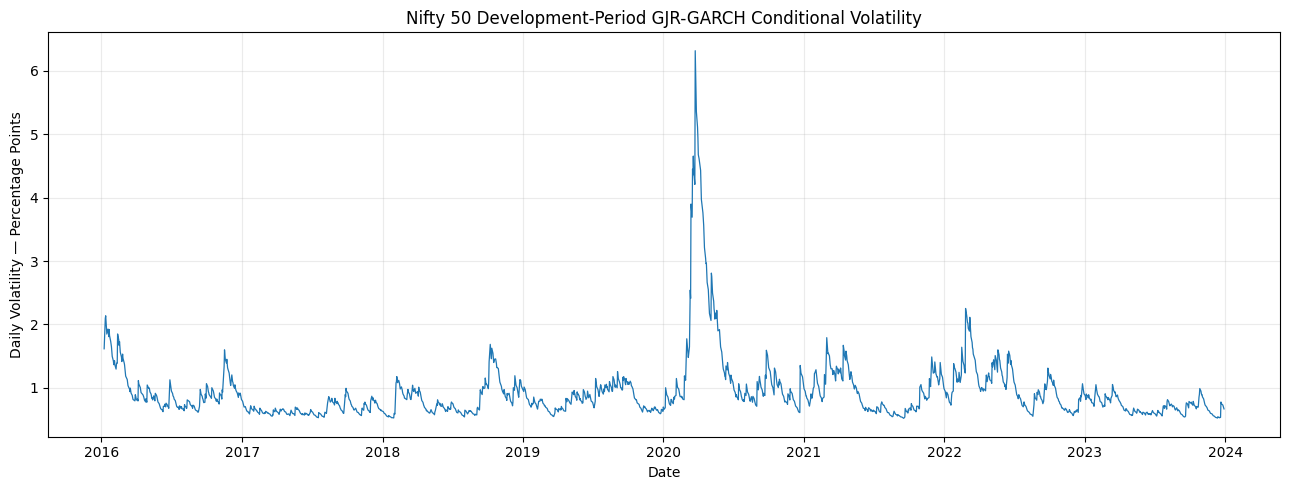

In [24]:
selected_conditional_volatility = (
    pd.Series(
        selected_volatility_model.conditional_volatility,
        index=garch_development_residuals.index,
        name="Daily Conditional Volatility",
    )
)

plt.figure(figsize=(13, 5))

plt.plot(
    selected_conditional_volatility.index,
    selected_conditional_volatility,
    linewidth=0.9,
)

plt.title(
    "Nifty 50 Development-Period GJR-GARCH Conditional Volatility"
)
plt.xlabel("Date")
plt.ylabel("Daily Volatility — Percentage Points")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 9. GJR-GARCH Diagnostic Interpretation

The selected GJR-GARCH(1,1) model with Student's t innovations captures
the principal volatility-clustering behaviour present in the Nifty 50
ARIMA residuals.

### Remaining linear dependence

The Ljung–Box tests on standardised residuals produced p-values of:

- 0.0451 at 10 lags
- 0.0213 at 20 lags

The null hypothesis of no residual autocorrelation is rejected at the 5%
level in both cases.

Some linear return dependence therefore remains after combining the
ARIMA conditional-mean model with GJR-GARCH volatility.

This limitation should be acknowledged, although it does not by itself
invalidate the conditional-volatility forecasts.

### Remaining volatility clustering

The Ljung–Box tests on squared standardised residuals produced p-values
of:

- 0.5941 at 10 lags
- 0.5921 at 20 lags

The ARCH LM test produced a p-value of 0.5982.

These tests do not reject the null hypothesis of no remaining volatility
dependence.

The selected GJR-GARCH model therefore appears to have captured the
material ARCH effects and volatility clustering present in the original
ARIMA residuals.

### Residual distribution

The Jarque–Bera test continues to reject normality.

This is not unexpected and does not directly contradict the selected
model because Student's t innovations were used specifically to allow for
heavy-tailed residual behaviour.

The fitted degrees-of-freedom parameter of approximately 9.56 also
supports a distribution with heavier tails than the normal distribution.

### Research conclusion

The GJR-GARCH specification is materially more successful as a volatility
model than ARIMA was as a point-return forecasting model.

The ARIMA model did not beat the zero-return benchmark, while the
GJR-GARCH model removed the statistically significant volatility
clustering from the residual series.

The forecasting framework should therefore place greater confidence in
dynamic risk forecasts than in predicted return direction.

The next test will evaluate whether one-day-ahead GJR-GARCH volatility
forecasts outperform simple historical-volatility benchmarks during the
out-of-sample period.

## 10. Out-of-Sample Volatility Forecast Evaluation

The selected GJR-GARCH model is evaluated using sequential one-day-ahead
volatility forecasts during the test period.

The model is compared with:

- trailing 21-day historical volatility,
- trailing 63-day historical volatility, and
- EWMA volatility using a decay factor of 0.94.

Because true daily volatility is not directly observable, the absolute
ARIMA forecast error is used as a daily volatility proxy and the squared
forecast error is used as a realised-variance proxy.

Forecasts are evaluated using:

- volatility MAE,
- volatility RMSE,
- variance MSE,
- QLIKE loss, and
- correlation with absolute forecast errors.

Lower MAE, RMSE, variance MSE and QLIKE values indicate better forecasts.

In [25]:
# ---------------------------------------------------------
# Frozen GJR-GARCH parameters
# ---------------------------------------------------------

selected_garch_parameters = (
    selected_volatility_model.params
)

garch_omega = float(
    selected_garch_parameters.get(
        "omega",
        0.0,
    )
)

garch_alpha = float(
    selected_garch_parameters.get(
        "alpha[1]",
        0.0,
    )
)

garch_gamma = float(
    selected_garch_parameters.get(
        "gamma[1]",
        0.0,
    )
)

garch_beta = float(
    selected_garch_parameters.get(
        "beta[1]",
        0.0,
    )
)

garch_degrees_of_freedom = float(
    selected_garch_parameters.get(
        "nu",
        np.nan,
    )
)

print("Frozen GJR-GARCH parameters")
print("-" * 60)
print("Omega:", f"{garch_omega:.6f}")
print("Alpha:", f"{garch_alpha:.6f}")
print("Gamma:", f"{garch_gamma:.6f}")
print("Beta:", f"{garch_beta:.6f}")
print(
    "Degrees of freedom:",
    f"{garch_degrees_of_freedom:.2f}",
)

Frozen GJR-GARCH parameters
------------------------------------------------------------
Omega: 0.024431
Alpha: 0.000000
Gamma: 0.145772
Beta: 0.894998
Degrees of freedom: 9.56


In [26]:
# ---------------------------------------------------------
# Initial conditions from development data
# ---------------------------------------------------------

development_residual_history = (
    garch_development_residuals
    .copy()
    .astype(float)
)

last_garch_residual = float(
    development_residual_history.iloc[-1]
)

last_garch_variance = float(
    selected_volatility_model
    .conditional_volatility
    .iloc[-1] ** 2
)

ewma_decay = 0.94

ewma_variance = float(
    development_residual_history
    .tail(63)
    .pow(2)
    .mean()
)

recursive_residual_history = (
    development_residual_history
    .tolist()
)

volatility_forecast_records = []

In [27]:
# ---------------------------------------------------------
# Sequential one-day-ahead volatility forecasts
# ---------------------------------------------------------

for forecast_date, forecast_row in (
    benchmark_forecasts.iterrows()
):

    # GJR-GARCH forecast uses the previous known residual.
    negative_shock_indicator = float(
        last_garch_residual < 0
    )

    gjr_garch_variance_forecast = (
        garch_omega
        + garch_alpha
        * last_garch_residual ** 2
        + garch_gamma
        * last_garch_residual ** 2
        * negative_shock_indicator
        + garch_beta
        * last_garch_variance
    )

    gjr_garch_variance_forecast = max(
        gjr_garch_variance_forecast,
        1e-12,
    )

    gjr_garch_volatility_forecast = np.sqrt(
        gjr_garch_variance_forecast
    )

    # Historical volatility benchmarks use prior residuals only.
    trailing_21_residuals = np.asarray(
        recursive_residual_history[-21:],
        dtype=float,
    )

    trailing_63_residuals = np.asarray(
        recursive_residual_history[-63:],
        dtype=float,
    )

    volatility_21_day = float(
        np.std(
            trailing_21_residuals,
            ddof=1,
        )
    )

    volatility_63_day = float(
        np.std(
            trailing_63_residuals,
            ddof=1,
        )
    )

    # EWMA forecast incorporates the latest known residual.
    ewma_variance_forecast = (
        ewma_decay * ewma_variance
        + (1 - ewma_decay)
        * last_garch_residual ** 2
    )

    ewma_variance_forecast = max(
        ewma_variance_forecast,
        1e-12,
    )

    ewma_volatility_forecast = np.sqrt(
        ewma_variance_forecast
    )

    # Actual ARIMA forecast error is revealed only now.
    actual_arima_residual = (
        (
            forecast_row["Actual Return"]
            - forecast_row["ARIMA Forecast"]
        )
        * 100
    )

    volatility_forecast_records.append(
        {
            "Date": forecast_date,

            "Actual ARIMA Residual":
                actual_arima_residual,

            "Absolute Residual":
                abs(actual_arima_residual),

            "Realised Variance Proxy":
                actual_arima_residual ** 2,

            "GJR-GARCH Volatility":
                gjr_garch_volatility_forecast,

            "21-Day Historical Volatility":
                volatility_21_day,

            "63-Day Historical Volatility":
                volatility_63_day,

            "EWMA Volatility":
                ewma_volatility_forecast,
        }
    )

    # Update state only after observing the current residual.
    last_garch_residual = (
        actual_arima_residual
    )

    last_garch_variance = (
        gjr_garch_variance_forecast
    )

    ewma_variance = (
        ewma_variance_forecast
    )

    recursive_residual_history.append(
        actual_arima_residual
    )


volatility_forecasts = (
    pd.DataFrame(
        volatility_forecast_records
    )
    .set_index("Date")
    .sort_index()
)

assert len(volatility_forecasts) == len(
    benchmark_forecasts
)

assert (
    volatility_forecasts
    .isna()
    .sum()
    .sum()
    == 0
)

print("Sequential volatility forecasts completed.")
print("-" * 60)
print(
    "Forecast observations:",
    f"{len(volatility_forecasts):,}",
)

display(volatility_forecasts.head())

Sequential volatility forecasts completed.
------------------------------------------------------------
Forecast observations: 632


,Actual ARIMA Residual,Absolute Residual,Realised Variance Proxy,GJR-GARCH Volatility,21-Day Historical Volatility,63-Day Historical Volatility,EWMA Volatility
Date,,,,,,,
2024-01-01,0.044531,0.044531,0.001983,0.669275,0.725539,0.678406,0.667762
2024-01-02,-0.359627,0.359627,0.129332,0.652171,0.726699,0.678133,0.647512
2024-01-03,-0.814729,0.814729,0.663783,0.651114,0.738288,0.663554,0.633936
2024-01-04,0.708998,0.708998,0.502679,0.707549,0.651113,0.670930,0.646211
2024-01-05,0.179403,0.179403,0.032185,0.687379,0.651334,0.670162,0.650150


In [28]:
# ---------------------------------------------------------
# Reusable volatility forecast evaluation
# ---------------------------------------------------------

def calculate_volatility_forecast_accuracy(
    realised_residuals,
    volatility_forecasts,
):
    """
    Evaluate daily volatility and variance forecasts.

    Inputs are expected in percentage-point units.
    """

    evaluation_data = pd.concat(
        [
            pd.Series(
                realised_residuals,
                name="Residual",
            ),
            pd.Series(
                volatility_forecasts,
                name="Forecast Volatility",
            ),
        ],
        axis=1,
    ).dropna()

    actual_absolute_residual = (
        evaluation_data["Residual"].abs()
    )

    actual_variance = (
        evaluation_data["Residual"] ** 2
    )

    forecast_volatility = (
        evaluation_data[
            "Forecast Volatility"
        ]
        .clip(lower=1e-8)
    )

    forecast_variance = (
        forecast_volatility ** 2
    )

    volatility_errors = (
        forecast_volatility
        - actual_absolute_residual
    )

    variance_errors = (
        forecast_variance
        - actual_variance
    )

    qlike_loss = (
        np.log(forecast_variance)
        + actual_variance
        / forecast_variance
    ).mean()

    return {
        "Observations":
            len(evaluation_data),

        "Volatility MAE":
            volatility_errors.abs().mean(),

        "Volatility RMSE":
            np.sqrt(
                np.mean(
                    volatility_errors ** 2
                )
            ),

        "Variance MSE":
            np.mean(
                variance_errors ** 2
            ),

        "QLIKE":
            qlike_loss,

        "Volatility–Absolute Residual Correlation":
            forecast_volatility.corr(
                actual_absolute_residual
            ),

        "Average Forecast Volatility":
            forecast_volatility.mean(),
    }

In [29]:
# ---------------------------------------------------------
# Compare GJR-GARCH with simple benchmarks
# ---------------------------------------------------------

volatility_model_columns = {
    "GJR-GARCH(1,1) — Student's t":
        "GJR-GARCH Volatility",

    "21-Day Historical Volatility":
        "21-Day Historical Volatility",

    "63-Day Historical Volatility":
        "63-Day Historical Volatility",

    "EWMA Volatility — 0.94":
        "EWMA Volatility",
}

volatility_accuracy_records = []

for model_name, forecast_column in (
    volatility_model_columns.items()
):

    model_results = (
        calculate_volatility_forecast_accuracy(
            realised_residuals=
                volatility_forecasts[
                    "Actual ARIMA Residual"
                ],
            volatility_forecasts=
                volatility_forecasts[
                    forecast_column
                ],
        )
    )

    volatility_accuracy_records.append(
        {
            "Volatility Model":
                model_name,
            **model_results,
        }
    )


volatility_accuracy_results = (
    pd.DataFrame(
        volatility_accuracy_records
    )
    .set_index("Volatility Model")
    .sort_values("QLIKE")
)

benchmark_qlike = (
    volatility_accuracy_results.loc[
        "63-Day Historical Volatility",
        "QLIKE",
    ]
)

volatility_accuracy_results[
    "QLIKE Improvement vs 63-Day"
] = (
    benchmark_qlike
    - volatility_accuracy_results[
        "QLIKE"
    ]
)

print("Out-of-Sample Volatility Forecast Accuracy")

display(
    volatility_accuracy_results.style.format(
        {
            "Observations": "{:,.0f}",
            "Volatility MAE": "{:.4f}",
            "Volatility RMSE": "{:.4f}",
            "Variance MSE": "{:.4f}",
            "QLIKE": "{:.4f}",
            "Volatility–Absolute Residual Correlation":
                "{:.4f}",
            "Average Forecast Volatility":
                "{:.4f}",
            "QLIKE Improvement vs 63-Day":
                "{:+.4f}",
        }
    )
)

Out-of-Sample Volatility Forecast Accuracy


,Observations,Volatility MAE,Volatility RMSE,Variance MSE,QLIKE,Volatility–Absolute Residual Correlation,Average Forecast Volatility,QLIKE Improvement vs 63-Day
Volatility Model,,,,,,,,
EWMA Volatility — 0.94,632,0.4948,0.6478,4.2707,0.6575,0.2057,0.8323,+0.1117
"GJR-GARCH(1,1) — Student's t",632,0.4928,0.6401,4.1981,0.6598,0.2805,0.8668,+0.1094
21-Day Historical Volatility,632,0.5022,0.6676,4.4850,0.7025,0.1784,0.8218,+0.0667
63-Day Historical Volatility,632,0.5213,0.6752,4.4436,0.7692,0.0653,0.8443,+0.0000


## 11. Out-of-Sample Volatility Forecast Conclusion

The selected GJR-GARCH(1,1) model with Student's t innovations produced
useful out-of-sample volatility forecasts.

### Comparison with simple benchmarks

GJR-GARCH achieved:

- the lowest volatility MAE,
- the lowest volatility RMSE,
- the lowest variance MSE, and
- the highest correlation with absolute forecast errors.

Its correlation with the absolute ARIMA residual was 0.2805, compared
with:

- 0.2057 for EWMA,
- 0.1784 for 21-day historical volatility, and
- 0.0653 for 63-day historical volatility.

This indicates that GJR-GARCH was better able to adjust its forecasts in
the same direction as changing market risk.

### QLIKE result

EWMA produced the lowest QLIKE loss:

- EWMA: 0.6575
- GJR-GARCH: 0.6598

The difference was only 0.0023.

GJR-GARCH therefore did not dominate every evaluation measure, and EWMA
must be retained as a credible challenger model.

### Final model decision

**Primary dynamic-volatility model:**
GJR-GARCH(1,1) with Student's t innovations

**Challenger and fallback model:**
EWMA volatility with a decay factor of 0.94

GJR-GARCH is retained as the primary model because it performed best on
four important forecast measures and captured asymmetric shock effects
and heavy-tailed market behaviour.

EWMA is retained because it was computationally simpler and achieved the
best QLIKE score.

### Overall forecasting conclusion

Daily Nifty 50 return direction was not forecast reliably by ARIMA.

Dynamic market volatility was forecast more successfully by both
GJR-GARCH and EWMA.

The practical value of the forecasting module therefore lies primarily
in risk estimation, confidence intervals and portfolio-risk adjustment,
rather than directional market prediction.

Daily squared returns and absolute residuals are noisy proxies for
unobservable realised volatility. These evaluation results should
therefore be interpreted as comparative forecasting evidence rather than
perfect measurements of true daily volatility.

In [30]:
# ---------------------------------------------------------
# Final volatility-model decision
# ---------------------------------------------------------

PRIMARY_VOLATILITY_MODEL = (
    "GJR-GARCH(1,1) — Student's t"
)

CHALLENGER_VOLATILITY_MODEL = (
    "EWMA Volatility — 0.94"
)

selected_dynamic_volatility_model_name = (
    PRIMARY_VOLATILITY_MODEL
)

volatility_model_decision = pd.DataFrame(
    {
        "Role": [
            "Primary dynamic-risk model",
            "Challenger and fallback model",
        ],
        "Model": [
            PRIMARY_VOLATILITY_MODEL,
            CHALLENGER_VOLATILITY_MODEL,
        ],
        "Reason": [
            (
                "Best MAE, RMSE, variance MSE and "
                "volatility correlation"
            ),
            (
                "Best QLIKE and lower computational complexity"
            ),
        ],
    }
)

display(volatility_model_decision)

,Role,Model,Reason
0,Primary dynamic-risk model,"GJR-GARCH(1,1) — Student's t","Best MAE, RMSE, variance MSE and volatility co..."
1,Challenger and fallback model,EWMA Volatility — 0.94,Best QLIKE and lower computational complexity


## 12. Reusable Stock-Level Dynamic Volatility Engine

The benchmark analysis showed that return-direction forecasting was weak,
while volatility forecasting added measurable value.

For portfolio allocation, each stock will therefore receive a dynamic
one-day-ahead volatility forecast.

The primary specification is:

- GJR-GARCH(1,1)
- Student's t innovations
- constant conditional mean
- trailing three-year estimation window

A constant mean is used instead of a stock-specific ARIMA model because
the benchmark ARIMA model failed to outperform a zero-return forecast.

EWMA with a decay factor of 0.94 is used automatically when the GJR-GARCH
model fails to converge or produces an invalid forecast.

The function accepts any NSE or BSE return series, supporting the final
user-selected portfolio application.

In [31]:
# ---------------------------------------------------------
# Reusable stock-level dynamic volatility forecast
# ---------------------------------------------------------

def forecast_next_day_dynamic_volatility(
    return_series,
    estimation_window=756,
    minimum_observations=504,
    ewma_decay=0.94,
):
    """
    Produce a one-trading-day-ahead volatility forecast.

    Primary model:
        GJR-GARCH(1,1) with Student's t innovations

    Fallback:
        EWMA volatility with lambda = 0.94

    Returns are supplied in decimal form.
    Forecast volatility is returned in percentage-point units.
    """

    clean_returns = (
        pd.Series(return_series)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    if len(clean_returns) < minimum_observations:
        raise ValueError(
            f"At least {minimum_observations} valid return "
            "observations are required."
        )

    estimation_returns = (
        clean_returns
        .tail(estimation_window)
        .copy()
    )

    # Convert decimal returns into percentage points.
    scaled_returns = (
        estimation_returns * 100
    )

    fallback_reason = None

    try:

        with warnings.catch_warnings():

            warnings.simplefilter("ignore")

            volatility_model = arch_model(
                scaled_returns,
                mean="Constant",
                vol="GARCH",
                p=1,
                o=1,
                q=1,
                dist="t",
                rescale=False,
            )

            fitted_volatility_model = (
                volatility_model.fit(
                    disp="off"
                )
            )

        if (
            fitted_volatility_model
            .convergence_flag
            != 0
        ):
            raise RuntimeError(
                "GJR-GARCH did not converge."
            )

        variance_forecast = float(
            fitted_volatility_model
            .forecast(
                horizon=1,
                reindex=False,
            )
            .variance
            .iloc[-1, 0]
        )

        if (
            not np.isfinite(variance_forecast)
            or variance_forecast <= 0
        ):
            raise RuntimeError(
                "GJR-GARCH returned an invalid variance forecast."
            )

        parameters = (
            fitted_volatility_model.params
        )

        alpha_value = float(
            parameters.get(
                "alpha[1]",
                0.0,
            )
        )

        beta_value = float(
            parameters.get(
                "beta[1]",
                0.0,
            )
        )

        gamma_value = float(
            parameters.get(
                "gamma[1]",
                0.0,
            )
        )

        persistence = (
            alpha_value
            + beta_value
            + 0.5 * gamma_value
        )

        daily_volatility = np.sqrt(
            variance_forecast
        )

        model_used = (
            "GJR-GARCH(1,1) — Student's t"
        )

        forecast_result = {
            "Model Used": model_used,
            "Observations": len(
                estimation_returns
            ),
            "Daily Volatility Forecast (%)":
                daily_volatility,
            "Annualised Volatility Forecast (%)":
                daily_volatility
                * np.sqrt(TRADING_DAYS),
            "Alpha": alpha_value,
            "Beta": beta_value,
            "Gamma": gamma_value,
            "Persistence": persistence,
            "Degrees of Freedom": float(
                parameters.get(
                    "nu",
                    np.nan,
                )
            ),
            "Fallback Reason": None,
        }

    except Exception as model_error:

        fallback_reason = str(
            model_error
        )

        centred_returns = (
            scaled_returns
            - scaled_returns.mean()
        )

        ewma_variance = float(
            centred_returns
            .head(63)
            .pow(2)
            .mean()
        )

        for residual_value in (
            centred_returns.iloc[63:]
        ):

            ewma_variance = (
                ewma_decay
                * ewma_variance
                + (1 - ewma_decay)
                * residual_value ** 2
            )

        ewma_variance = max(
            ewma_variance,
            1e-12,
        )

        daily_volatility = np.sqrt(
            ewma_variance
        )

        forecast_result = {
            "Model Used":
                "EWMA Volatility — 0.94",

            "Observations":
                len(estimation_returns),

            "Daily Volatility Forecast (%)":
                daily_volatility,

            "Annualised Volatility Forecast (%)":
                daily_volatility
                * np.sqrt(TRADING_DAYS),

            "Alpha": np.nan,
            "Beta": np.nan,
            "Gamma": np.nan,
            "Persistence": np.nan,
            "Degrees of Freedom": np.nan,
            "Fallback Reason":
                fallback_reason,
        }

    return forecast_result

In [32]:
# ---------------------------------------------------------
# Latest dynamic-volatility forecast for India 10
# ---------------------------------------------------------

stock_volatility_forecast_records = []

for ticker in DEFAULT_FORECAST_TICKERS:

    ticker_forecast = (
        forecast_next_day_dynamic_volatility(
            return_series=
                forecast_log_returns[
                    ticker
                ],
            estimation_window=756,
            minimum_observations=504,
            ewma_decay=0.94,
        )
    )

    stock_volatility_forecast_records.append(
        {
            "Ticker": ticker,
            **ticker_forecast,
        }
    )


latest_stock_volatility_forecasts = (
    pd.DataFrame(
        stock_volatility_forecast_records
    )
    .set_index("Ticker")
    .sort_values(
        "Annualised Volatility Forecast (%)"
    )
)

print("Latest India 10 Dynamic-Volatility Forecasts")
print("-" * 65)

display(
    latest_stock_volatility_forecasts.style.format(
        {
            "Observations": "{:,.0f}",
            "Daily Volatility Forecast (%)":
                "{:.3f}%",
            "Annualised Volatility Forecast (%)":
                "{:.2f}%",
            "Alpha": "{:.4f}",
            "Beta": "{:.4f}",
            "Gamma": "{:.4f}",
            "Persistence": "{:.4f}",
            "Degrees of Freedom": "{:.2f}",
        },
        na_rep="—",
    )
)

Latest India 10 Dynamic-Volatility Forecasts
-----------------------------------------------------------------


,Model Used,Observations,Daily Volatility Forecast (%),Annualised Volatility Forecast (%),Alpha,Beta,Gamma,Persistence,Degrees of Freedom,Fallback Reason
Ticker,,,,,,,,,,
SUNPHARMA.NS,"GJR-GARCH(1,1) — Student's t",756,1.035%,16.43%,0.0187,0.8710,0.0798,0.9296,4.92,—
HDFCBANK.NS,"GJR-GARCH(1,1) — Student's t",756,1.207%,19.16%,0.1052,0.6162,0.1325,0.7876,4.36,—
POWERGRID.NS,"GJR-GARCH(1,1) — Student's t",756,1.258%,19.96%,0.2140,0.7800,-0.1631,0.9124,4.94,—
HINDUNILVR.NS,"GJR-GARCH(1,1) — Student's t",756,1.306%,20.74%,0.2676,0.0514,-0.2172,0.2104,3.73,—
BHARTIARTL.NS,"GJR-GARCH(1,1) — Student's t",756,1.312%,20.84%,0.0679,0.8445,-0.0299,0.8974,4.76,—
LT.NS,"GJR-GARCH(1,1) — Student's t",756,1.363%,21.64%,0.0806,0.6627,0.1976,0.8421,3.69,—
M&M.NS,"GJR-GARCH(1,1) — Student's t",756,1.713%,27.19%,0.0672,0.8920,0.0091,0.9637,7.48,—
TCS.NS,"GJR-GARCH(1,1) — Student's t",756,1.910%,30.32%,0.0000,0.9735,0.0306,0.9888,3.24,—
BEL.NS,"GJR-GARCH(1,1) — Student's t",756,2.063%,32.74%,0.1427,0.5117,0.1695,0.7391,5.41,—


In [33]:
# ---------------------------------------------------------
# Volatility-engine validation
# ---------------------------------------------------------

assert len(
    latest_stock_volatility_forecasts
) == len(
    DEFAULT_FORECAST_TICKERS
)

assert (
    latest_stock_volatility_forecasts[
        "Daily Volatility Forecast (%)"
    ] > 0
).all()

assert (
    latest_stock_volatility_forecasts[
        "Annualised Volatility Forecast (%)"
    ] > 0
).all()

assert (
    latest_stock_volatility_forecasts[
        "Model Used"
    ].isin(
        [
            "GJR-GARCH(1,1) — Student's t",
            "EWMA Volatility — 0.94",
        ]
    )
).all()

primary_model_count = int(
    (
        latest_stock_volatility_forecasts[
            "Model Used"
        ]
        == "GJR-GARCH(1,1) — Student's t"
    ).sum()
)

fallback_model_count = (
    len(latest_stock_volatility_forecasts)
    - primary_model_count
)

print("Dynamic-volatility engine validated.")
print(
    "GJR-GARCH forecasts:",
    primary_model_count,
)
print(
    "EWMA fallback forecasts:",
    fallback_model_count,
)

Dynamic-volatility engine validated.
GJR-GARCH forecasts: 10
EWMA fallback forecasts: 0


## 13. Forecast-Aware Adaptive Barbell Allocation

The dynamic volatility forecasts are now incorporated into portfolio
construction.

### Resilient Compounders

The Resilient bucket is weighted using inverse forecast volatility.

Stocks with lower predicted volatility receive larger weights, while
stocks with higher predicted volatility receive smaller weights.

### Growth Leaders

The Growth bucket continues to combine:

- 70% six-month price momentum
- 30% low-volatility score

The low-volatility component now uses one-day-ahead GJR-GARCH volatility
forecasts instead of trailing historical volatility.

### Market regime

The Nifty 50 200-day moving average controls total equity exposure:

- Normal regime: 100% equity
- Defensive regime: 70% equity and 30% cash

The resulting weights represent targets for the next trading day and use
only information available through the latest completed trading session.

In [38]:
# ---------------------------------------------------------
# India 10 portfolio buckets
# ---------------------------------------------------------

RESILIENT_TICKERS = [
    "HDFCBANK.NS",
    "TCS.NS",
    "HINDUNILVR.NS",
    "SUNPHARMA.NS",
    "POWERGRID.NS",
]

GROWTH_TICKERS = [
    "BHARTIARTL.NS",
    "LT.NS",
    "M&M.NS",
    "BEL.NS",
    "TRENT.NS",
]

RESILIENT_BUCKET_SHARE = 0.50
GROWTH_BUCKET_SHARE = 0.50

MOMENTUM_SCORE_WEIGHT = 0.70
LOW_VOLATILITY_SCORE_WEIGHT = 0.30

DEFENSIVE_EQUITY_FRACTION = 0.70
TREND_WINDOW = 200
MOMENTUM_LOOKBACK = 126

In [39]:
# ---------------------------------------------------------
# Reusable forecast-aware allocation engine
# ---------------------------------------------------------

def build_forecast_aware_barbell_allocation(
    stock_prices,
    benchmark_prices,
    volatility_forecasts,
    resilient_tickers,
    growth_tickers,
    momentum_lookback=126,
    trend_window=200,
    resilient_bucket_share=0.50,
    growth_bucket_share=0.50,
    momentum_score_weight=0.70,
    low_volatility_score_weight=0.30,
    defensive_equity_fraction=0.70,
):
    """
    Construct next-trading-day Adaptive Barbell target weights.

    Volatility forecasts must contain:
        Annualised Volatility Forecast (%)

    Returns:
        allocation table
        regime summary
    """

    resilient_tickers = list(resilient_tickers)
    growth_tickers = list(growth_tickers)

    all_tickers = (
        resilient_tickers
        + growth_tickers
    )

    if set(resilient_tickers).intersection(
        growth_tickers
    ):
        raise ValueError(
            "A ticker cannot belong to both portfolio buckets."
        )

    if not np.isclose(
        resilient_bucket_share
        + growth_bucket_share,
        1.0,
    ):
        raise ValueError(
            "Resilient and Growth bucket shares must sum to one."
        )

    missing_price_tickers = [
        ticker
        for ticker in all_tickers
        if ticker not in stock_prices.columns
    ]

    if missing_price_tickers:
        raise ValueError(
            "Missing price data for: "
            + ", ".join(missing_price_tickers)
        )

    missing_forecast_tickers = [
        ticker
        for ticker in all_tickers
        if ticker not in volatility_forecasts.index
    ]

    if missing_forecast_tickers:
        raise ValueError(
            "Missing volatility forecasts for: "
            + ", ".join(missing_forecast_tickers)
        )

    clean_stock_prices = (
        stock_prices[all_tickers]
        .sort_index()
        .ffill()
        .dropna()
    )

    clean_benchmark_prices = (
        pd.Series(benchmark_prices)
        .sort_index()
        .dropna()
        .astype(float)
    )

    minimum_required_history = max(
        momentum_lookback + 1,
        trend_window,
    )

    if len(clean_stock_prices) < minimum_required_history:
        raise ValueError(
            "Insufficient stock-price history."
        )

    if len(clean_benchmark_prices) < trend_window:
        raise ValueError(
            "Insufficient benchmark history."
        )

    latest_date = min(
        clean_stock_prices.index.max(),
        clean_benchmark_prices.index.max(),
    )

    clean_stock_prices = (
        clean_stock_prices.loc[
            :latest_date
        ]
    )

    clean_benchmark_prices = (
        clean_benchmark_prices.loc[
            :latest_date
        ]
    )

    # -----------------------------------------------------
    # Latest six-month momentum
    # -----------------------------------------------------

    current_growth_prices = (
        clean_stock_prices[
            growth_tickers
        ]
        .iloc[-1]
    )

    previous_growth_prices = (
        clean_stock_prices[
            growth_tickers
        ]
        .iloc[
            -(momentum_lookback + 1)
        ]
    )

    growth_momentum = (
        current_growth_prices
        / previous_growth_prices
        - 1
    )

    # Higher momentum receives a higher percentile score.
    growth_momentum_score = (
        growth_momentum
        .rank(
            method="average",
            ascending=True,
            pct=True,
        )
    )

    # -----------------------------------------------------
    # Dynamic volatility inputs
    # -----------------------------------------------------

    annualised_volatility = (
        volatility_forecasts.loc[
            all_tickers,
            "Annualised Volatility Forecast (%)"
        ]
        .astype(float)
    )

    if (
        annualised_volatility <= 0
    ).any():
        raise ValueError(
            "All volatility forecasts must be positive."
        )

    # -----------------------------------------------------
    # Resilient inverse-volatility weights
    # -----------------------------------------------------

    resilient_inverse_volatility = (
        1
        / annualised_volatility.loc[
            resilient_tickers
        ]
    )

    resilient_equity_weights = (
        resilient_inverse_volatility
        / resilient_inverse_volatility.sum()
        * resilient_bucket_share
    )

    # -----------------------------------------------------
    # Growth momentum and low-volatility score
    # -----------------------------------------------------

    # Lower forecast volatility receives a higher score.
    growth_low_volatility_score = (
        annualised_volatility.loc[
            growth_tickers
        ]
        .rank(
            method="average",
            ascending=False,
            pct=True,
        )
    )

    growth_composite_score = (
        momentum_score_weight
        * growth_momentum_score
        + low_volatility_score_weight
        * growth_low_volatility_score
    )

    growth_equity_weights = (
        growth_composite_score
        / growth_composite_score.sum()
        * growth_bucket_share
    )

    # -----------------------------------------------------
    # Combine equity-only weights
    # -----------------------------------------------------

    equity_only_weights = pd.concat(
        [
            resilient_equity_weights,
            growth_equity_weights,
        ]
    ).reindex(all_tickers)

    # -----------------------------------------------------
    # Nifty 50 trend regime
    # -----------------------------------------------------

    latest_benchmark_price = float(
        clean_benchmark_prices.iloc[-1]
    )

    latest_trend_value = float(
        clean_benchmark_prices
        .rolling(trend_window)
        .mean()
        .iloc[-1]
    )

    if latest_benchmark_price >= latest_trend_value:

        market_regime = "Normal"
        equity_fraction = 1.0

    else:

        market_regime = "Defensive"
        equity_fraction = (
            defensive_equity_fraction
        )

    final_stock_weights = (
        equity_only_weights
        * equity_fraction
    )

    cash_weight = (
        1
        - final_stock_weights.sum()
    )

    # -----------------------------------------------------
    # Build detailed output table
    # -----------------------------------------------------

    allocation_table = pd.DataFrame(
        index=all_tickers
    )

    allocation_table["Bucket"] = [
        (
            "Resilient"
            if ticker in resilient_tickers
            else "Growth"
        )
        for ticker in all_tickers
    ]

    allocation_table[
        "Forecast Annualised Volatility (%)"
    ] = annualised_volatility

    allocation_table[
        "Six-Month Momentum"
    ] = growth_momentum.reindex(
        all_tickers
    )

    allocation_table[
        "Momentum Score"
    ] = growth_momentum_score.reindex(
        all_tickers
    )

    allocation_table[
        "Low-Volatility Score"
    ] = growth_low_volatility_score.reindex(
        all_tickers
    )

    allocation_table[
        "Growth Composite Score"
    ] = growth_composite_score.reindex(
        all_tickers
    )

    allocation_table[
        "Equity-Only Weight"
    ] = equity_only_weights

    allocation_table[
        "Final Portfolio Weight"
    ] = final_stock_weights

    allocation_table = (
        allocation_table
        .sort_values(
            [
                "Bucket",
                "Final Portfolio Weight",
            ],
            ascending=[True, False],
        )
    )

    regime_summary = {
        "Signal Date": latest_date,
        "Market Regime": market_regime,
        "Nifty 50 Level":
            latest_benchmark_price,
        "Nifty 50 200-Day Average":
            latest_trend_value,
        "Equity Allocation":
            equity_fraction,
        "Cash Allocation":
            cash_weight,
    }

    return {
        "Allocation Table":
            allocation_table,
        "Regime Summary":
            regime_summary,
        "Cash Weight":
            cash_weight,
    }

In [40]:
# ---------------------------------------------------------
# Latest forecast-aware India 10 allocation
# ---------------------------------------------------------

latest_forecast_aware_allocation = (
    build_forecast_aware_barbell_allocation(
        stock_prices=
            forecast_stock_prices,

        benchmark_prices=
            forecast_benchmark_prices,

        volatility_forecasts=
            latest_stock_volatility_forecasts,

        resilient_tickers=
            RESILIENT_TICKERS,

        growth_tickers=
            GROWTH_TICKERS,

        momentum_lookback=
            MOMENTUM_LOOKBACK,

        trend_window=
            TREND_WINDOW,

        resilient_bucket_share=
            RESILIENT_BUCKET_SHARE,

        growth_bucket_share=
            GROWTH_BUCKET_SHARE,

        momentum_score_weight=
            MOMENTUM_SCORE_WEIGHT,

        low_volatility_score_weight=
            LOW_VOLATILITY_SCORE_WEIGHT,

        defensive_equity_fraction=
            DEFENSIVE_EQUITY_FRACTION,
    )
)

forecast_aware_allocation_table = (
    latest_forecast_aware_allocation[
        "Allocation Table"
    ]
)

forecast_aware_regime_summary = (
    latest_forecast_aware_allocation[
        "Regime Summary"
    ]
)

print("Forecast-Aware Adaptive Barbell Allocation")
print("-" * 65)

for metric, value in (
    forecast_aware_regime_summary.items()
):

    if metric in [
        "Equity Allocation",
        "Cash Allocation",
    ]:

        print(
            f"{metric}: {value:.2%}"
        )

    elif metric in [
        "Nifty 50 Level",
        "Nifty 50 200-Day Average",
    ]:

        print(
            f"{metric}: {value:,.2f}"
        )

    else:

        print(
            f"{metric}: {value}"
        )

display(
    forecast_aware_allocation_table.style.format(
        {
            "Forecast Annualised Volatility (%)":
                "{:.2f}%",

            "Six-Month Momentum":
                "{:+.2%}",

            "Momentum Score":
                "{:.3f}",

            "Low-Volatility Score":
                "{:.3f}",

            "Growth Composite Score":
                "{:.3f}",

            "Equity-Only Weight":
                "{:.2%}",

            "Final Portfolio Weight":
                "{:.2%}",
        },
        na_rep="—",
    )
)

Forecast-Aware Adaptive Barbell Allocation
-----------------------------------------------------------------
Signal Date: 2026-07-30 00:00:00
Market Regime: Defensive
Nifty 50 Level: 24,317.15
Nifty 50 200-Day Average: 24,783.08
Equity Allocation: 70.00%
Cash Allocation: 30.00%


,Bucket,Forecast Annualised Volatility (%),Six-Month Momentum,Momentum Score,Low-Volatility Score,Growth Composite Score,Equity-Only Weight,Final Portfolio Weight
LT.NS,Growth,21.64%,+4.80%,0.800,0.800,0.800,13.33%,9.33%
TRENT.NS,Growth,43.08%,+16.60%,1.000,0.200,0.760,12.67%,8.87%
BHARTIARTL.NS,Growth,20.84%,+1.21%,0.600,1.000,0.720,12.00%,8.40%
M&M.NS,Growth,27.19%,-3.80%,0.400,0.600,0.460,7.67%,5.37%
BEL.NS,Growth,32.74%,-14.67%,0.200,0.400,0.260,4.33%,3.03%
SUNPHARMA.NS,Resilient,16.43%,—,—,—,—,12.45%,8.72%
HDFCBANK.NS,Resilient,19.16%,—,—,—,—,10.68%,7.48%
POWERGRID.NS,Resilient,19.96%,—,—,—,—,10.25%,7.17%
HINDUNILVR.NS,Resilient,20.74%,—,—,—,—,9.87%,6.91%
TCS.NS,Resilient,30.32%,—,—,—,—,6.75%,4.72%


In [37]:
# ---------------------------------------------------------
# Allocation validation
# ---------------------------------------------------------

final_stock_weight_sum = (
    forecast_aware_allocation_table[
        "Final Portfolio Weight"
    ].sum()
)

forecast_aware_cash_weight = (
    latest_forecast_aware_allocation[
        "Cash Weight"
    ]
)

assert (
    forecast_aware_allocation_table[
        "Final Portfolio Weight"
    ] >= 0
).all()

assert np.isclose(
    final_stock_weight_sum
    + forecast_aware_cash_weight,
    1.0,
)

assert np.isclose(
    forecast_aware_allocation_table.loc[
        forecast_aware_allocation_table[
            "Bucket"
        ] == "Resilient",
        "Equity-Only Weight",
    ].sum(),
    RESILIENT_BUCKET_SHARE,
)

assert np.isclose(
    forecast_aware_allocation_table.loc[
        forecast_aware_allocation_table[
            "Bucket"
        ] == "Growth",
        "Equity-Only Weight",
    ].sum(),
    GROWTH_BUCKET_SHARE,
)

print("Forecast-aware allocation validated.")
print(
    "Stock weight:",
    f"{final_stock_weight_sum:.2%}",
)
print(
    "Cash weight:",
    f"{forecast_aware_cash_weight:.2%}",
)
print(
    "Total:",
    f"{final_stock_weight_sum + forecast_aware_cash_weight:.2%}",
)

Forecast-aware allocation validated.
Stock weight: 70.00%
Cash weight: 30.00%
Total: 100.00%


## 14. Forecast-Aware Allocation Interpretation

As of 30 July 2026, the Nifty 50 closed below its 200-day moving average:

- Nifty 50 level: 24,317.15
- Nifty 50 200-day moving average: 24,783.08

The portfolio therefore entered the Defensive regime.

The resulting target allocation was:

- 70% equity
- 30% cash

Within the equity allocation, the Resilient and Growth buckets retained
their equal 50% equity-only shares.

### Resilient bucket

Sun Pharma received the largest Resilient allocation because it had the
lowest forecast annualised volatility.

TCS received the smallest Resilient allocation because it had the highest
forecast volatility within the bucket.

### Growth bucket

Larsen & Toubro received the largest Growth allocation because it combined
strong momentum with relatively low forecast volatility.

Trent retained a high weight because of its strongest six-month momentum,
although its high forecast volatility reduced its low-volatility score.

Bharat Electronics received the lowest Growth allocation because it had
the weakest six-month momentum and relatively high forecast volatility.

### Portfolio interpretation

The forecast-aware framework does not attempt to predict which stock will
produce the highest next-day return.

Instead, it uses dynamic volatility forecasts to adjust position sizes
while retaining the original momentum and market-regime structure.

The Defensive regime reduces total equity exposure during weak broad-market
conditions, while the GJR-GARCH forecasts control risk within each equity
bucket.

## 15. Point-in-Time Monthly Rebalance Schedule

The forecast-aware allocation will be evaluated historically during the
out-of-sample period.

For each month:

- the first available Nifty 50 trading day is the execution date,
- the immediately preceding trading day is the signal date,
- forecasts and portfolio weights use data available only through the
  signal date, and
- the resulting weights become active on the execution date.

This preserves the strategy's one-trading-day signal lag and prevents
look-ahead bias.

In [41]:
# ---------------------------------------------------------
# Build monthly signal and execution schedule
# ---------------------------------------------------------

def build_monthly_rebalance_schedule(
    trading_dates,
    test_start_date,
):
    """
    Create monthly execution dates and prior-trading-day signal dates.

    The first trading day of each month is used as the execution date.
    The immediately preceding trading day is used as the signal date.
    """

    trading_dates = (
        pd.DatetimeIndex(trading_dates)
        .drop_duplicates()
        .sort_values()
    )

    test_start_date = pd.Timestamp(
        test_start_date
    )

    if len(trading_dates) < 2:
        raise ValueError(
            "At least two trading dates are required."
        )

    execution_candidates = (
        pd.Series(
            trading_dates[
                trading_dates >= test_start_date
            ],
            index=trading_dates[
                trading_dates >= test_start_date
            ],
        )
        .groupby(
            trading_dates[
                trading_dates >= test_start_date
            ].to_period("M")
        )
        .first()
    )

    schedule_records = []

    for execution_date in execution_candidates:

        execution_position = (
            trading_dates.get_loc(
                execution_date
            )
        )

        if execution_position == 0:
            continue

        signal_date = trading_dates[
            execution_position - 1
        ]

        schedule_records.append(
            {
                "Signal Date": signal_date,
                "Execution Date": execution_date,
                "Month": execution_date.to_period("M"),
            }
        )

    schedule = (
        pd.DataFrame(schedule_records)
        .sort_values("Execution Date")
        .reset_index(drop=True)
    )

    if schedule.empty:
        raise ValueError(
            "No valid monthly rebalance dates were created."
        )

    if not (
        schedule["Signal Date"]
        < schedule["Execution Date"]
    ).all():
        raise AssertionError(
            "Every signal date must precede its execution date."
        )

    return schedule

In [42]:
# ---------------------------------------------------------
# Out-of-sample monthly schedule
# ---------------------------------------------------------

forecast_rebalance_schedule = (
    build_monthly_rebalance_schedule(
        trading_dates=
            forecast_benchmark_prices
            .dropna()
            .index,

        test_start_date=
            FORECAST_TEST_START,
    )
)

print("Forecast-Aware Monthly Rebalance Schedule")
print("-" * 65)
print(
    "Rebalances:",
    len(forecast_rebalance_schedule),
)
print(
    "First signal date:",
    forecast_rebalance_schedule[
        "Signal Date"
    ].min().date(),
)
print(
    "First execution date:",
    forecast_rebalance_schedule[
        "Execution Date"
    ].min().date(),
)
print(
    "Latest signal date:",
    forecast_rebalance_schedule[
        "Signal Date"
    ].max().date(),
)
print(
    "Latest execution date:",
    forecast_rebalance_schedule[
        "Execution Date"
    ].max().date(),
)

display(
    forecast_rebalance_schedule.head(6)
)

display(
    forecast_rebalance_schedule.tail(6)
)

Forecast-Aware Monthly Rebalance Schedule
-----------------------------------------------------------------
Rebalances: 31
First signal date: 2023-12-29
First execution date: 2024-01-01
Latest signal date: 2026-06-30
Latest execution date: 2026-07-01


,Signal Date,Execution Date,Month
0,2023-12-29,2024-01-01,2024-01
1,2024-01-31,2024-02-01,2024-02
2,2024-02-29,2024-03-01,2024-03
3,2024-03-28,2024-04-01,2024-04
4,2024-04-30,2024-05-02,2024-05
5,2024-05-31,2024-06-03,2024-06


,Signal Date,Execution Date,Month
25,2026-01-30,2026-02-02,2026-02
26,2026-02-27,2026-03-02,2026-03
27,2026-03-30,2026-04-01,2026-04
28,2026-04-30,2026-05-04,2026-05
29,2026-05-29,2026-06-01,2026-06
30,2026-06-30,2026-07-01,2026-07


## 16. Point-in-Time Monthly Volatility Forecasts

For every monthly signal date, a separate one-day-ahead volatility
forecast is generated for each India 10 stock.

Each forecast uses only observations available on or before the relevant
signal date.

This creates a historical panel of point-in-time GJR-GARCH forecasts that
can be used in the out-of-sample portfolio backtest without look-ahead
bias.

EWMA remains the automatic fallback when a GJR-GARCH model does not
converge or produces an invalid forecast.

In [43]:
# ---------------------------------------------------------
# Generate point-in-time monthly stock-volatility forecasts
# ---------------------------------------------------------

monthly_volatility_forecast_records = []

total_signal_dates = len(
    forecast_rebalance_schedule
)

for schedule_number, schedule_row in (
    forecast_rebalance_schedule.iterrows()
):

    signal_date = pd.Timestamp(
        schedule_row["Signal Date"]
    )

    execution_date = pd.Timestamp(
        schedule_row["Execution Date"]
    )

    for ticker in DEFAULT_FORECAST_TICKERS:

        point_in_time_returns = (
            forecast_log_returns.loc[
                forecast_log_returns.index
                <= signal_date,
                ticker,
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .dropna()
        )

        volatility_forecast = (
            forecast_next_day_dynamic_volatility(
                return_series=
                    point_in_time_returns,

                estimation_window=756,
                minimum_observations=504,
                ewma_decay=0.94,
            )
        )

        monthly_volatility_forecast_records.append(
            {
                "Signal Date":
                    signal_date,

                "Execution Date":
                    execution_date,

                "Ticker":
                    ticker,

                **volatility_forecast,
            }
        )

    if (
        (schedule_number + 1) % 5 == 0
        or schedule_number + 1
        == total_signal_dates
    ):

        print(
            "Completed",
            schedule_number + 1,
            "of",
            total_signal_dates,
            "signal dates.",
        )

Completed 5 of 31 signal dates.
Completed 10 of 31 signal dates.
Completed 15 of 31 signal dates.
Completed 20 of 31 signal dates.
Completed 25 of 31 signal dates.
Completed 30 of 31 signal dates.
Completed 31 of 31 signal dates.


In [44]:
# ---------------------------------------------------------
# Point-in-time volatility forecast panel
# ---------------------------------------------------------

monthly_stock_volatility_forecasts = (
    pd.DataFrame(
        monthly_volatility_forecast_records
    )
    .sort_values(
        [
            "Signal Date",
            "Ticker",
        ]
    )
    .reset_index(drop=True)
)

print(
    "\nPoint-in-Time Monthly Volatility Forecast Panel"
)
print("-" * 65)
print(
    "Signal dates:",
    monthly_stock_volatility_forecasts[
        "Signal Date"
    ].nunique(),
)
print(
    "Stocks:",
    monthly_stock_volatility_forecasts[
        "Ticker"
    ].nunique(),
)
print(
    "Total forecasts:",
    len(
        monthly_stock_volatility_forecasts
    ),
)

display(
    monthly_stock_volatility_forecasts.head(10)
)


Point-in-Time Monthly Volatility Forecast Panel
-----------------------------------------------------------------
Signal dates: 31
Stocks: 10
Total forecasts: 310


,Signal Date,Execution Date,Ticker,Model Used,Observations,Daily Volatility Forecast (%),Annualised Volatility Forecast (%),Alpha,Beta,Gamma,Persistence,Degrees of Freedom,Fallback Reason
0,2023-12-29,2024-01-01,BEL.NS,"GJR-GARCH(1,1) — Student's t",756,1.636274,25.975052,3.229975e-10,0.997258,-3.180719e-09,0.997258,6.321448,None
1,2023-12-29,2024-01-01,BHARTIARTL.NS,"GJR-GARCH(1,1) — Student's t",756,1.007663,15.996160,1.124144e-02,0.992644,-1.124147e-02,0.998265,7.588163,None
2,2023-12-29,2024-01-01,HDFCBANK.NS,"GJR-GARCH(1,1) — Student's t",756,1.087786,17.268068,3.371728e-02,0.944190,6.504918e-03,0.981160,4.367264,None
3,2023-12-29,2024-01-01,HINDUNILVR.NS,"GJR-GARCH(1,1) — Student's t",756,0.809772,12.854736,1.573142e-02,0.976648,1.381774e-02,0.999289,5.606499,None
4,2023-12-29,2024-01-01,LT.NS,"GJR-GARCH(1,1) — Student's t",756,1.220203,19.370127,6.086611e-03,0.975031,1.980945e-02,0.991022,7.709827,None
5,2023-12-29,2024-01-01,M&M.NS,"GJR-GARCH(1,1) — Student's t",756,1.657696,26.315105,2.571097e-02,0.964084,-1.012617e-02,0.984732,4.541357,None
6,2023-12-29,2024-01-01,POWERGRID.NS,"GJR-GARCH(1,1) — Student's t",756,1.563835,24.825113,2.520022e-01,0.462700,-1.057736e-01,0.661815,5.325855,None
7,2023-12-29,2024-01-01,SUNPHARMA.NS,"GJR-GARCH(1,1) — Student's t",756,0.949390,15.071102,1.292552e-04,0.982421,3.326624e-02,0.999183,6.002664,None
8,2023-12-29,2024-01-01,TCS.NS,"GJR-GARCH(1,1) — Student's t",756,1.209693,19.203281,0.000000e+00,0.513749,2.279270e-01,0.627713,4.873279,None
9,2023-12-29,2024-01-01,TRENT.NS,"GJR-GARCH(1,1) — Student's t",756,1.379800,21.903639,1.277100e-02,0.932186,8.194820e-02,0.985932,5.036230,None


In [45]:
# ---------------------------------------------------------
# Validate point-in-time volatility panel
# ---------------------------------------------------------

expected_forecast_count = (
    len(forecast_rebalance_schedule)
    * len(DEFAULT_FORECAST_TICKERS)
)

assert (
    len(monthly_stock_volatility_forecasts)
    == expected_forecast_count
)

forecasts_per_signal_date = (
    monthly_stock_volatility_forecasts
    .groupby("Signal Date")[
        "Ticker"
    ]
    .nunique()
)

assert (
    forecasts_per_signal_date
    == len(DEFAULT_FORECAST_TICKERS)
).all()

assert not (
    monthly_stock_volatility_forecasts
    .duplicated(
        subset=[
            "Signal Date",
            "Ticker",
        ]
    )
    .any()
)

assert (
    monthly_stock_volatility_forecasts[
        "Daily Volatility Forecast (%)"
    ] > 0
).all()

assert (
    monthly_stock_volatility_forecasts[
        "Annualised Volatility Forecast (%)"
    ] > 0
).all()

assert (
    monthly_stock_volatility_forecasts[
        "Signal Date"
    ]
    < monthly_stock_volatility_forecasts[
        "Execution Date"
    ]
).all()

allowed_volatility_models = [
    "GJR-GARCH(1,1) — Student's t",
    "EWMA Volatility — 0.94",
]

assert (
    monthly_stock_volatility_forecasts[
        "Model Used"
    ]
    .isin(
        allowed_volatility_models
    )
    .all()
)

monthly_primary_forecasts = int(
    (
        monthly_stock_volatility_forecasts[
            "Model Used"
        ]
        == "GJR-GARCH(1,1) — Student's t"
    ).sum()
)

monthly_fallback_forecasts = int(
    (
        monthly_stock_volatility_forecasts[
            "Model Used"
        ]
        == "EWMA Volatility — 0.94"
    ).sum()
)

print(
    "Point-in-time volatility panel validated."
)
print(
    "Expected forecasts:",
    expected_forecast_count,
)
print(
    "GJR-GARCH forecasts:",
    monthly_primary_forecasts,
)
print(
    "EWMA fallback forecasts:",
    monthly_fallback_forecasts,
)

Point-in-time volatility panel validated.
Expected forecasts: 310
GJR-GARCH forecasts: 310
EWMA fallback forecasts: 0


## 17. Historical Forecast-Aware Target Weights

For each monthly signal date, the corresponding point-in-time volatility
forecasts are passed into the Adaptive Barbell allocation engine.

The allocation calculation uses:

- stock prices available through the signal date,
- Nifty 50 prices available through the signal date,
- the point-in-time volatility forecasts for that date,
- six-month momentum,
- the 200-day market-regime filter, and
- the one-trading-day execution lag.

The resulting weights become active on the associated execution date.

In [46]:
# ---------------------------------------------------------
# Generate monthly forecast-aware target weights
# ---------------------------------------------------------

historical_target_records = []

for _, schedule_row in (
    forecast_rebalance_schedule.iterrows()
):

    signal_date = pd.Timestamp(
        schedule_row["Signal Date"]
    )

    execution_date = pd.Timestamp(
        schedule_row["Execution Date"]
    )

    point_in_time_forecasts = (
        monthly_stock_volatility_forecasts.loc[
            monthly_stock_volatility_forecasts[
                "Signal Date"
            ] == signal_date
        ]
        .set_index("Ticker")
        .copy()
    )

    point_in_time_stock_prices = (
        forecast_stock_prices.loc[
            :signal_date
        ]
        .copy()
    )

    point_in_time_benchmark_prices = (
        forecast_benchmark_prices.loc[
            :signal_date
        ]
        .copy()
    )

    allocation_result = (
        build_forecast_aware_barbell_allocation(
            stock_prices=
                point_in_time_stock_prices,

            benchmark_prices=
                point_in_time_benchmark_prices,

            volatility_forecasts=
                point_in_time_forecasts,

            resilient_tickers=
                RESILIENT_TICKERS,

            growth_tickers=
                GROWTH_TICKERS,

            momentum_lookback=
                MOMENTUM_LOOKBACK,

            trend_window=
                TREND_WINDOW,

            resilient_bucket_share=
                RESILIENT_BUCKET_SHARE,

            growth_bucket_share=
                GROWTH_BUCKET_SHARE,

            momentum_score_weight=
                MOMENTUM_SCORE_WEIGHT,

            low_volatility_score_weight=
                LOW_VOLATILITY_SCORE_WEIGHT,

            defensive_equity_fraction=
                DEFENSIVE_EQUITY_FRACTION,
        )
    )

    allocation_table = (
        allocation_result[
            "Allocation Table"
        ]
    )

    regime_summary = (
        allocation_result[
            "Regime Summary"
        ]
    )

    target_record = {
        "Signal Date":
            signal_date,

        "Execution Date":
            execution_date,

        "Model Data Cutoff":
            pd.Timestamp(
                regime_summary[
                    "Signal Date"
                ]
            ),

        "Market Regime":
            regime_summary[
                "Market Regime"
            ],

        "Nifty 50 Level":
            regime_summary[
                "Nifty 50 Level"
            ],

        "Nifty 50 200-Day Average":
            regime_summary[
                "Nifty 50 200-Day Average"
            ],

        "Equity Allocation":
            regime_summary[
                "Equity Allocation"
            ],

        "Cash":
            allocation_result[
                "Cash Weight"
            ],
    }

    for ticker in DEFAULT_FORECAST_TICKERS:

        target_record[ticker] = float(
            allocation_table.loc[
                ticker,
                "Final Portfolio Weight",
            ]
        )

    historical_target_records.append(
        target_record
    )

In [47]:
# ---------------------------------------------------------
# Historical target-weight panel
# ---------------------------------------------------------

monthly_forecast_aware_targets = (
    pd.DataFrame(
        historical_target_records
    )
    .sort_values("Execution Date")
    .set_index("Execution Date")
)

forecast_weight_columns = (
    DEFAULT_FORECAST_TICKERS
    + ["Cash"]
)

monthly_forecast_aware_weights = (
    monthly_forecast_aware_targets[
        forecast_weight_columns
    ]
    .copy()
)

print("Historical Forecast-Aware Target Weights")
print("-" * 65)
print(
    "Target portfolios:",
    len(monthly_forecast_aware_targets),
)
print(
    "First execution date:",
    monthly_forecast_aware_targets
    .index.min()
    .date(),
)
print(
    "Latest execution date:",
    monthly_forecast_aware_targets
    .index.max()
    .date(),
)

display(
    monthly_forecast_aware_targets[
        [
            "Signal Date",
            "Market Regime",
            "Equity Allocation",
            "Cash",
        ]
        + DEFAULT_FORECAST_TICKERS
    ]
    .head()
    .style.format(
        {
            "Equity Allocation": "{:.2%}",
            "Cash": "{:.2%}",
            **{
                ticker: "{:.2%}"
                for ticker
                in DEFAULT_FORECAST_TICKERS
            },
        }
    )
)

Historical Forecast-Aware Target Weights
-----------------------------------------------------------------
Target portfolios: 31
First execution date: 2024-01-01
Latest execution date: 2026-07-01


,Signal Date,Market Regime,Equity Allocation,Cash,HDFCBANK.NS,TCS.NS,HINDUNILVR.NS,SUNPHARMA.NS,POWERGRID.NS,BHARTIARTL.NS,LT.NS,M&M.NS,BEL.NS,TRENT.NS
Execution Date,,,,,,,,,,,,,,
2024-01-01 00:00:00,2023-12-29 00:00:00,Normal,100.00%,0.00%,9.83%,8.84%,13.21%,11.27%,6.84%,7.33%,11.00%,5.67%,11.33%,14.67%
2024-02-01 00:00:00,2024-01-31 00:00:00,Normal,100.00%,0.00%,7.35%,12.00%,9.16%,12.82%,8.67%,9.67%,11.00%,5.33%,11.33%,12.67%
2024-03-01 00:00:00,2024-02-29 00:00:00,Normal,100.00%,0.00%,9.32%,10.34%,12.00%,12.02%,6.32%,9.67%,11.00%,4.33%,12.33%,12.67%
2024-04-01 00:00:00,2024-03-28 00:00:00,Normal,100.00%,0.00%,10.78%,9.84%,12.02%,10.56%,6.80%,12.00%,8.67%,4.33%,12.33%,12.67%
2024-05-02 00:00:00,2024-04-30 00:00:00,Normal,100.00%,0.00%,10.87%,9.71%,13.35%,8.31%,7.76%,12.00%,6.33%,5.67%,11.33%,14.67%


In [48]:
# ---------------------------------------------------------
# Historical target-weight validation
# ---------------------------------------------------------

assert (
    len(monthly_forecast_aware_targets)
    == len(forecast_rebalance_schedule)
)

assert (
    monthly_forecast_aware_targets
    .index
    .is_unique
)

assert (
    monthly_forecast_aware_weights
    >= -1e-12
).all().all()

assert np.allclose(
    monthly_forecast_aware_weights.sum(
        axis=1
    ),
    1.0,
)

assert (
    monthly_forecast_aware_targets[
        "Signal Date"
    ].values
    < monthly_forecast_aware_targets
    .index.values
).all()

assert (
    monthly_forecast_aware_targets[
        "Model Data Cutoff"
    ]
    <= monthly_forecast_aware_targets[
        "Signal Date"
    ]
).all()

assert (
    monthly_forecast_aware_targets[
        "Market Regime"
    ]
    .isin(
        [
            "Normal",
            "Defensive",
        ]
    )
    .all()
)

for execution_date, weight_row in (
    monthly_forecast_aware_weights.iterrows()
):

    equity_weight = (
        1
        - weight_row["Cash"]
    )

    resilient_weight = (
        weight_row[
            RESILIENT_TICKERS
        ].sum()
    )

    growth_weight = (
        weight_row[
            GROWTH_TICKERS
        ].sum()
    )

    assert np.isclose(
        resilient_weight,
        RESILIENT_BUCKET_SHARE
        * equity_weight,
    )

    assert np.isclose(
        growth_weight,
        GROWTH_BUCKET_SHARE
        * equity_weight,
    )


regime_counts = (
    monthly_forecast_aware_targets[
        "Market Regime"
    ]
    .value_counts()
)

normal_rebalances = int(
    regime_counts.get(
        "Normal",
        0,
    )
)

defensive_rebalances = int(
    regime_counts.get(
        "Defensive",
        0,
    )
)

print(
    "Historical target weights validated."
)
print(
    "Monthly targets:",
    len(monthly_forecast_aware_targets),
)
print(
    "Normal-regime targets:",
    normal_rebalances,
)
print(
    "Defensive-regime targets:",
    defensive_rebalances,
)
print(
    "Average equity allocation:",
    f"{monthly_forecast_aware_targets['Equity Allocation'].mean():.2%}",
)
print(
    "Average cash allocation:",
    f"{monthly_forecast_aware_targets['Cash'].mean():.2%}",
)

Historical target weights validated.
Monthly targets: 31
Normal-regime targets: 22
Defensive-regime targets: 9
Average equity allocation: 91.29%
Average cash allocation: 8.71%


## 18. Forecast-Aware Strategy Backtest

The point-in-time monthly target weights are now converted into a
realistic portfolio-value series.

At each execution date:

1. Existing holdings are valued using the previous closing values.
2. One-way turnover is calculated relative to the new target weights.
3. Transaction costs of 0.15% per one-way turnover are deducted.
4. The remaining portfolio value is allocated according to the new
   target weights.
5. Holdings drift naturally until the next monthly rebalance.

Cash earns the assumed Indian risk-free rate of 6.5% per annum.

The backtest begins with ₹10,00,000 and covers the out-of-sample period
beginning on 1 January 2024.

In [49]:
# ---------------------------------------------------------
# Forecast-aware backtest inputs
# ---------------------------------------------------------

INITIAL_CAPITAL = 1_000_000
ONE_WAY_TRANSACTION_COST = 0.0015

daily_cash_return = (
    (1 + RISK_FREE_RATE)
    ** (1 / TRADING_DAYS)
    - 1
)

backtest_start_date = (
    monthly_forecast_aware_weights
    .index.min()
)

backtest_calendar = (
    forecast_benchmark_prices
    .dropna()
    .loc[backtest_start_date:]
    .index
)

backtest_stock_prices = (
    forecast_stock_prices
    .reindex(backtest_calendar)
    .ffill()
)

# Calculate returns before slicing so the first test-day return
# is measured relative to the previous available trading close.
full_stock_prices_on_benchmark_calendar = (
    forecast_stock_prices
    .reindex(
        forecast_benchmark_prices
        .dropna()
        .index
    )
    .ffill()
)

full_stock_simple_returns = (
    full_stock_prices_on_benchmark_calendar
    .pct_change()
)

backtest_stock_returns = (
    full_stock_simple_returns
    .loc[backtest_calendar]
    .fillna(0.0)
)

backtest_benchmark_returns = (
    forecast_benchmark_prices
    .pct_change()
    .loc[backtest_calendar]
    .fillna(0.0)
)

print("Backtest inputs prepared.")
print(
    "Period:",
    backtest_calendar.min().date(),
    "to",
    backtest_calendar.max().date(),
)
print(
    "Trading observations:",
    len(backtest_calendar),
)
print(
    "Daily cash return:",
    f"{daily_cash_return:.6%}",
)

Backtest inputs prepared.
Period: 2024-01-01 to 2026-07-30
Trading observations: 636
Daily cash return: 0.024993%


In [50]:
# ---------------------------------------------------------
# Holdings-based portfolio backtest
# ---------------------------------------------------------

def run_target_weight_backtest(
    stock_returns,
    target_weights,
    initial_capital=1_000_000,
    transaction_cost_rate=0.0015,
    annual_cash_rate=0.065,
):
    """
    Backtest dated target weights using actual drifting holdings.

    Parameters
    ----------
    stock_returns:
        Daily simple stock returns in decimal form.

    target_weights:
        Target weights indexed by execution date.
        Must contain each stock column and a Cash column.

    initial_capital:
        Starting portfolio value in rupees.

    transaction_cost_rate:
        Cost per unit of one-way turnover.

    annual_cash_rate:
        Annual cash return assumption.

    Returns
    -------
    Dictionary containing daily results, turnover and costs.
    """

    clean_returns = (
        stock_returns
        .sort_index()
        .copy()
        .astype(float)
    )

    clean_targets = (
        target_weights
        .sort_index()
        .copy()
        .astype(float)
    )

    stock_columns = list(
        clean_returns.columns
    )

    required_weight_columns = (
        stock_columns
        + ["Cash"]
    )

    missing_weight_columns = [
        column
        for column in required_weight_columns
        if column not in clean_targets.columns
    ]

    if missing_weight_columns:
        raise ValueError(
            "Target weights are missing: "
            + ", ".join(missing_weight_columns)
        )

    clean_targets = clean_targets[
        required_weight_columns
    ]

    if not np.allclose(
        clean_targets.sum(axis=1),
        1.0,
    ):
        raise ValueError(
            "Every target-weight row must sum to one."
        )

    if (
        clean_targets < -1e-12
    ).any().any():
        raise ValueError(
            "Negative target weights are not permitted."
        )

    first_execution_date = (
        clean_targets.index.min()
    )

    clean_returns = (
        clean_returns.loc[
            clean_returns.index
            >= first_execution_date
        ]
    )

    missing_execution_dates = (
        clean_targets.index.difference(
            clean_returns.index
        )
    )

    if len(missing_execution_dates) > 0:
        raise ValueError(
            "Execution dates missing from return calendar: "
            + ", ".join(
                date.strftime("%Y-%m-%d")
                for date
                in missing_execution_dates
            )
        )

    daily_cash_rate = (
        (1 + annual_cash_rate)
        ** (1 / TRADING_DAYS)
        - 1
    )

    # Portfolio begins entirely in cash.
    holdings = pd.Series(
        0.0,
        index=required_weight_columns,
    )

    holdings["Cash"] = float(
        initial_capital
    )

    daily_records = []
    rebalance_records = []

    for current_date, return_row in (
        clean_returns.iterrows()
    ):

        starting_nav = float(
            holdings.sum()
        )

        transaction_cost = 0.0
        one_way_turnover = 0.0
        rebalanced = False

        if current_date in clean_targets.index:

            pre_trade_weights = (
                holdings
                / starting_nav
            )

            new_target_weights = (
                clean_targets.loc[
                    current_date
                ]
                .reindex(
                    required_weight_columns
                )
                .astype(float)
            )

            one_way_turnover = float(
                0.5
                * (
                    new_target_weights
                    - pre_trade_weights
                )
                .abs()
                .sum()
            )

            transaction_cost = float(
                starting_nav
                * one_way_turnover
                * transaction_cost_rate
            )

            investable_nav = (
                starting_nav
                - transaction_cost
            )

            holdings = (
                new_target_weights
                * investable_nav
            )

            rebalanced = True

            rebalance_records.append(
                {
                    "Execution Date":
                        current_date,

                    "Starting NAV (₹)":
                        starting_nav,

                    "One-Way Turnover":
                        one_way_turnover,

                    "Transaction Cost (₹)":
                        transaction_cost,

                    "Post-Cost Investable NAV (₹)":
                        investable_nav,
                }
            )

        stock_day_returns = (
            return_row
            .reindex(stock_columns)
            .fillna(0.0)
        )

        holdings.loc[
            stock_columns
        ] = (
            holdings.loc[
                stock_columns
            ]
            * (
                1
                + stock_day_returns
            )
        )

        holdings["Cash"] = (
            holdings["Cash"]
            * (
                1
                + daily_cash_rate
            )
        )

        ending_nav = float(
            holdings.sum()
        )

        net_daily_return = (
            ending_nav
            / starting_nav
            - 1
        )

        end_of_day_weights = (
            holdings
            / ending_nav
        )

        daily_record = {
            "Date": current_date,
            "Portfolio Value (₹)":
                ending_nav,
            "Net Daily Return":
                net_daily_return,
            "Rebalanced":
                rebalanced,
            "One-Way Turnover":
                one_way_turnover,
            "Transaction Cost (₹)":
                transaction_cost,
            "Cash Weight":
                end_of_day_weights[
                    "Cash"
                ],
        }

        for ticker in stock_columns:

            daily_record[
                f"{ticker} Weight"
            ] = end_of_day_weights[
                ticker
            ]

        daily_records.append(
            daily_record
        )

    daily_results = (
        pd.DataFrame(
            daily_records
        )
        .set_index("Date")
        .sort_index()
    )

    rebalance_results = (
        pd.DataFrame(
            rebalance_records
        )
        .set_index("Execution Date")
        .sort_index()
    )

    return {
        "Daily Results":
            daily_results,

        "Rebalance Results":
            rebalance_results,

        "Ending Holdings":
            holdings,

        "Initial Capital":
            initial_capital,
    }

In [51]:
# ---------------------------------------------------------
# Run the forecast-aware backtest
# ---------------------------------------------------------

forecast_aware_backtest = (
    run_target_weight_backtest(
        stock_returns=
            backtest_stock_returns[
                DEFAULT_FORECAST_TICKERS
            ],

        target_weights=
            monthly_forecast_aware_weights,

        initial_capital=
            INITIAL_CAPITAL,

        transaction_cost_rate=
            ONE_WAY_TRANSACTION_COST,

        annual_cash_rate=
            RISK_FREE_RATE,
    )
)

forecast_aware_daily_results = (
    forecast_aware_backtest[
        "Daily Results"
    ]
)

forecast_aware_rebalance_results = (
    forecast_aware_backtest[
        "Rebalance Results"
    ]
)

print("Forecast-aware backtest completed.")
print(
    "Daily observations:",
    len(forecast_aware_daily_results),
)
print(
    "Rebalances executed:",
    len(forecast_aware_rebalance_results),
)
print(
    "Ending value:",
    f"₹{forecast_aware_daily_results['Portfolio Value (₹)'].iloc[-1]:,.2f}",
)

Forecast-aware backtest completed.
Daily observations: 636
Rebalances executed: 31
Ending value: ₹1,436,300.18


In [52]:
# ---------------------------------------------------------
# Reusable performance-statistics function
# ---------------------------------------------------------

def calculate_backtest_performance(
    daily_returns,
    portfolio_values,
    benchmark_returns,
    initial_capital,
    annual_risk_free_rate=0.065,
):
    """
    Calculate standard portfolio-performance statistics.
    """

    evaluation_data = pd.concat(
        [
            pd.Series(
                daily_returns,
                name="Strategy",
            ),
            pd.Series(
                benchmark_returns,
                name="Benchmark",
            ),
        ],
        axis=1,
    ).dropna()

    strategy_returns = (
        evaluation_data["Strategy"]
    )

    benchmark_returns = (
        evaluation_data["Benchmark"]
    )

    values = (
        pd.Series(portfolio_values)
        .reindex(evaluation_data.index)
        .dropna()
    )

    observations = len(
        strategy_returns
    )

    years = (
        observations
        / TRADING_DAYS
    )

    ending_value = float(
        values.iloc[-1]
    )

    total_return = (
        ending_value
        / initial_capital
        - 1
    )

    cagr = (
        ending_value
        / initial_capital
    ) ** (
        1 / years
    ) - 1

    annualised_volatility = (
        strategy_returns.std(
            ddof=1
        )
        * np.sqrt(TRADING_DAYS)
    )

    daily_risk_free_rate = (
        (1 + annual_risk_free_rate)
        ** (1 / TRADING_DAYS)
        - 1
    )

    excess_returns = (
        strategy_returns
        - daily_risk_free_rate
    )

    sharpe_ratio = (
        excess_returns.mean()
        / strategy_returns.std(
            ddof=1
        )
        * np.sqrt(TRADING_DAYS)
    )

    downside_excess_returns = (
        excess_returns.clip(
            upper=0
        )
    )

    downside_deviation = (
        np.sqrt(
            np.mean(
                downside_excess_returns ** 2
            )
        )
        * np.sqrt(TRADING_DAYS)
    )

    annualised_excess_return = (
        excess_returns.mean()
        * TRADING_DAYS
    )

    sortino_ratio = (
        annualised_excess_return
        / downside_deviation
        if downside_deviation > 0
        else np.nan
    )

    wealth_index = (
        values
        / initial_capital
    )

    running_peak = (
        wealth_index.cummax()
    )

    drawdown = (
        wealth_index
        / running_peak
        - 1
    )

    maximum_drawdown = float(
        drawdown.min()
    )

    calmar_ratio = (
        cagr
        / abs(maximum_drawdown)
        if maximum_drawdown < 0
        else np.nan
    )

    benchmark_variance = (
        benchmark_returns.var(
            ddof=1
        )
    )

    beta = (
        strategy_returns.cov(
            benchmark_returns
        )
        / benchmark_variance
        if benchmark_variance > 0
        else np.nan
    )

    correlation = (
        strategy_returns.corr(
            benchmark_returns
        )
    )

    return {
        "Ending Value (₹)":
            ending_value,
        "Total Return":
            total_return,
        "CAGR":
            cagr,
        "Annualised Volatility":
            annualised_volatility,
        "Sharpe Ratio":
            sharpe_ratio,
        "Sortino Ratio":
            sortino_ratio,
        "Maximum Drawdown":
            maximum_drawdown,
        "Calmar Ratio":
            calmar_ratio,
        "Beta vs Nifty":
            beta,
        "Correlation vs Nifty":
            correlation,
    }

In [53]:
# ---------------------------------------------------------
# Strategy and Nifty 50 performance comparison
# ---------------------------------------------------------

forecast_aware_performance = (
    calculate_backtest_performance(
        daily_returns=
            forecast_aware_daily_results[
                "Net Daily Return"
            ],

        portfolio_values=
            forecast_aware_daily_results[
                "Portfolio Value (₹)"
            ],

        benchmark_returns=
            backtest_benchmark_returns,

        initial_capital=
            INITIAL_CAPITAL,

        annual_risk_free_rate=
            RISK_FREE_RATE,
    )
)

nifty_portfolio_values = (
    INITIAL_CAPITAL
    * (
        1
        + backtest_benchmark_returns
    )
    .cumprod()
)

nifty_performance = (
    calculate_backtest_performance(
        daily_returns=
            backtest_benchmark_returns,

        portfolio_values=
            nifty_portfolio_values,

        benchmark_returns=
            backtest_benchmark_returns,

        initial_capital=
            INITIAL_CAPITAL,

        annual_risk_free_rate=
            RISK_FREE_RATE,
    )
)

forecast_aware_performance_comparison = (
    pd.DataFrame(
        {
            "Forecast-Aware Adaptive":
                forecast_aware_performance,

            "Nifty 50":
                nifty_performance,
        }
    )
    .T
)

print("Forecast-Aware Out-of-Sample Performance")

display(
    forecast_aware_performance_comparison.style.format(
        {
            "Ending Value (₹)":
                "₹{:,.0f}",

            "Total Return":
                "{:.2%}",

            "CAGR":
                "{:.2%}",

            "Annualised Volatility":
                "{:.2%}",

            "Sharpe Ratio":
                "{:.2f}",

            "Sortino Ratio":
                "{:.2f}",

            "Maximum Drawdown":
                "{:.2%}",

            "Calmar Ratio":
                "{:.2f}",

            "Beta vs Nifty":
                "{:.2f}",

            "Correlation vs Nifty":
                "{:.2f}",
        }
    )
)

Forecast-Aware Out-of-Sample Performance


,Ending Value (₹),Total Return,CAGR,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,Calmar Ratio,Beta vs Nifty,Correlation vs Nifty
Forecast-Aware Adaptive,"₹1,436,300",43.63%,15.43%,13.30%,0.67,0.96,-15.07%,1.02,0.84,0.87
Nifty 50,"₹1,118,987",11.90%,4.56%,13.71%,-0.07,-0.09,-15.77%,0.29,1.00,1.00


In [54]:
# ---------------------------------------------------------
# Trading-cost and turnover summary
# ---------------------------------------------------------

backtest_years = (
    len(forecast_aware_daily_results)
    / TRADING_DAYS
)

forecast_aware_trading_summary = pd.DataFrame(
    {
        "Result": [
            len(
                forecast_aware_rebalance_results
            ),

            forecast_aware_rebalance_results[
                "One-Way Turnover"
            ].sum(),

            forecast_aware_rebalance_results[
                "One-Way Turnover"
            ].mean(),

            (
                forecast_aware_rebalance_results[
                    "One-Way Turnover"
                ].sum()
                / backtest_years
            ),

            forecast_aware_rebalance_results[
                "Transaction Cost (₹)"
            ].sum(),

            (
                forecast_aware_rebalance_results[
                    "Transaction Cost (₹)"
                ].sum()
                / INITIAL_CAPITAL
            ),
        ],
    },
    index=[
        "Rebalances",
        "Total One-Way Turnover",
        "Average Turnover per Rebalance",
        "Annualised One-Way Turnover",
        "Total Transaction Costs (₹)",
        "Costs as Percentage of Initial Capital",
    ],
)

formatted_trading_summary = (
    forecast_aware_trading_summary
    .copy()
    .astype(object)
)

formatted_trading_summary.loc[
    "Rebalances",
    "Result",
] = (
    f"{int(forecast_aware_trading_summary.loc['Rebalances', 'Result'])}"
)

for metric in [
    "Total One-Way Turnover",
    "Average Turnover per Rebalance",
    "Annualised One-Way Turnover",
    "Costs as Percentage of Initial Capital",
]:

    formatted_trading_summary.loc[
        metric,
        "Result",
    ] = (
        f"{forecast_aware_trading_summary.loc[metric, 'Result']:.2%}"
    )

formatted_trading_summary.loc[
    "Total Transaction Costs (₹)",
    "Result",
] = (
    f"₹{forecast_aware_trading_summary.loc['Total Transaction Costs (₹)', 'Result']:,.2f}"
)

print("Forecast-Aware Trading Summary")
display(formatted_trading_summary)

Forecast-Aware Trading Summary


,Result
Rebalances,31
Total One-Way Turnover,370.40%
Average Turnover per Rebalance,11.95%
Annualised One-Way Turnover,146.76%
Total Transaction Costs (₹),"₹7,126.02"
Costs as Percentage of Initial Capital,0.71%


## 19. Like-for-Like Historical-Volatility Control

A control portfolio is required to isolate the contribution of dynamic
GJR-GARCH volatility forecasts.

The control strategy uses exactly the same:

- India 10 stock universe,
- monthly signal and execution dates,
- six-month momentum scores,
- Resilient and Growth bucket structure,
- Nifty 50 200-day regime filter,
- equity and cash exposure rules, and
- portfolio constraints.

The only difference is the volatility input.

The control portfolio uses trailing 63-trading-day annualised volatility,
calculated using observations available through each signal date.

Comparing the two strategies on the same period will show whether the
forecasting model improved allocation decisions beyond a simple
historical-volatility estimate.

In [55]:
# ---------------------------------------------------------
# Point-in-time 63-day historical-volatility panel
# ---------------------------------------------------------

HISTORICAL_VOLATILITY_WINDOW = 63

historical_volatility_records = []

for _, schedule_row in (
    forecast_rebalance_schedule.iterrows()
):

    signal_date = pd.Timestamp(
        schedule_row["Signal Date"]
    )

    execution_date = pd.Timestamp(
        schedule_row["Execution Date"]
    )

    point_in_time_returns = (
        forecast_log_returns.loc[
            forecast_log_returns.index
            <= signal_date,
            DEFAULT_FORECAST_TICKERS,
        ]
        .tail(HISTORICAL_VOLATILITY_WINDOW)
    )

    valid_observations = (
        point_in_time_returns.count()
    )

    if (
        valid_observations
        < HISTORICAL_VOLATILITY_WINDOW
    ).any():

        missing_tickers = (
            valid_observations.loc[
                valid_observations
                < HISTORICAL_VOLATILITY_WINDOW
            ]
            .index
            .tolist()
        )

        raise ValueError(
            "Insufficient historical-volatility data for: "
            + ", ".join(missing_tickers)
        )

    annualised_historical_volatility = (
        point_in_time_returns.std(
            ddof=1
        )
        * np.sqrt(TRADING_DAYS)
        * 100
    )

    for ticker in DEFAULT_FORECAST_TICKERS:

        historical_volatility_records.append(
            {
                "Signal Date":
                    signal_date,

                "Execution Date":
                    execution_date,

                "Ticker":
                    ticker,

                "Model Used":
                    "63-Day Historical Volatility",

                "Observations":
                    HISTORICAL_VOLATILITY_WINDOW,

                "Daily Volatility Forecast (%)":
                    annualised_historical_volatility[
                        ticker
                    ]
                    / np.sqrt(TRADING_DAYS),

                "Annualised Volatility Forecast (%)":
                    annualised_historical_volatility[
                        ticker
                    ],
            }
        )


monthly_historical_volatility_inputs = (
    pd.DataFrame(
        historical_volatility_records
    )
    .sort_values(
        [
            "Signal Date",
            "Ticker",
        ]
    )
    .reset_index(drop=True)
)

print(
    "Point-in-Time Historical-Volatility Panel"
)
print("-" * 65)
print(
    "Signal dates:",
    monthly_historical_volatility_inputs[
        "Signal Date"
    ].nunique(),
)
print(
    "Stocks:",
    monthly_historical_volatility_inputs[
        "Ticker"
    ].nunique(),
)
print(
    "Total observations:",
    len(
        monthly_historical_volatility_inputs
    ),
)

display(
    monthly_historical_volatility_inputs.head(10)
)

Point-in-Time Historical-Volatility Panel
-----------------------------------------------------------------
Signal dates: 31
Stocks: 10
Total observations: 310


,Signal Date,Execution Date,Ticker,Model Used,Observations,Daily Volatility Forecast (%),Annualised Volatility Forecast (%)
0,2023-12-29,2024-01-01,BEL.NS,63-Day Historical Volatility,63,1.672275,26.546543
1,2023-12-29,2024-01-01,BHARTIARTL.NS,63-Day Historical Volatility,63,0.989297,15.704595
2,2023-12-29,2024-01-01,HDFCBANK.NS,63-Day Historical Volatility,63,0.890962,14.143587
3,2023-12-29,2024-01-01,HINDUNILVR.NS,63-Day Historical Volatility,63,0.809901,12.856778
4,2023-12-29,2024-01-01,LT.NS,63-Day Historical Volatility,63,1.204285,19.117430
5,2023-12-29,2024-01-01,M&M.NS,63-Day Historical Volatility,63,1.507417,23.929499
6,2023-12-29,2024-01-01,POWERGRID.NS,63-Day Historical Volatility,63,1.216367,19.309225
7,2023-12-29,2024-01-01,SUNPHARMA.NS,63-Day Historical Volatility,63,0.984653,15.630887
8,2023-12-29,2024-01-01,TCS.NS,63-Day Historical Volatility,63,1.209324,19.197420
9,2023-12-29,2024-01-01,TRENT.NS,63-Day Historical Volatility,63,1.676992,26.621417


In [56]:
# ---------------------------------------------------------
# Historical-volatility control target weights
# ---------------------------------------------------------

historical_control_target_records = []

for _, schedule_row in (
    forecast_rebalance_schedule.iterrows()
):

    signal_date = pd.Timestamp(
        schedule_row["Signal Date"]
    )

    execution_date = pd.Timestamp(
        schedule_row["Execution Date"]
    )

    point_in_time_volatility = (
        monthly_historical_volatility_inputs.loc[
            monthly_historical_volatility_inputs[
                "Signal Date"
            ] == signal_date
        ]
        .set_index("Ticker")
        .copy()
    )

    control_allocation_result = (
        build_forecast_aware_barbell_allocation(
            stock_prices=
                forecast_stock_prices.loc[
                    :signal_date
                ],

            benchmark_prices=
                forecast_benchmark_prices.loc[
                    :signal_date
                ],

            volatility_forecasts=
                point_in_time_volatility,

            resilient_tickers=
                RESILIENT_TICKERS,

            growth_tickers=
                GROWTH_TICKERS,

            momentum_lookback=
                MOMENTUM_LOOKBACK,

            trend_window=
                TREND_WINDOW,

            resilient_bucket_share=
                RESILIENT_BUCKET_SHARE,

            growth_bucket_share=
                GROWTH_BUCKET_SHARE,

            momentum_score_weight=
                MOMENTUM_SCORE_WEIGHT,

            low_volatility_score_weight=
                LOW_VOLATILITY_SCORE_WEIGHT,

            defensive_equity_fraction=
                DEFENSIVE_EQUITY_FRACTION,
        )
    )

    control_allocation_table = (
        control_allocation_result[
            "Allocation Table"
        ]
    )

    control_regime_summary = (
        control_allocation_result[
            "Regime Summary"
        ]
    )

    control_record = {
        "Signal Date":
            signal_date,

        "Execution Date":
            execution_date,

        "Market Regime":
            control_regime_summary[
                "Market Regime"
            ],

        "Equity Allocation":
            control_regime_summary[
                "Equity Allocation"
            ],

        "Cash":
            control_allocation_result[
                "Cash Weight"
            ],
    }

    for ticker in DEFAULT_FORECAST_TICKERS:

        control_record[ticker] = float(
            control_allocation_table.loc[
                ticker,
                "Final Portfolio Weight",
            ]
        )

    historical_control_target_records.append(
        control_record
    )


monthly_historical_control_targets = (
    pd.DataFrame(
        historical_control_target_records
    )
    .sort_values("Execution Date")
    .set_index("Execution Date")
)

monthly_historical_control_weights = (
    monthly_historical_control_targets[
        DEFAULT_FORECAST_TICKERS
        + ["Cash"]
    ]
    .copy()
)

In [57]:
# ---------------------------------------------------------
# Validate historical-volatility control
# ---------------------------------------------------------

expected_control_observations = (
    len(forecast_rebalance_schedule)
    * len(DEFAULT_FORECAST_TICKERS)
)

assert (
    len(monthly_historical_volatility_inputs)
    == expected_control_observations
)

assert (
    len(monthly_historical_control_targets)
    == len(monthly_forecast_aware_targets)
)

assert (
    monthly_historical_control_targets
    .index
    .equals(
        monthly_forecast_aware_targets.index
    )
)

assert (
    monthly_historical_control_weights
    >= -1e-12
).all().all()

assert np.allclose(
    monthly_historical_control_weights.sum(
        axis=1
    ),
    1.0,
)

assert (
    monthly_historical_control_targets[
        "Market Regime"
    ].values
    == monthly_forecast_aware_targets[
        "Market Regime"
    ].values
).all()

assert np.allclose(
    monthly_historical_control_targets[
        "Cash"
    ],
    monthly_forecast_aware_targets[
        "Cash"
    ],
)

average_absolute_weight_difference = (
    monthly_forecast_aware_weights[
        DEFAULT_FORECAST_TICKERS
    ]
    - monthly_historical_control_weights[
        DEFAULT_FORECAST_TICKERS
    ]
).abs().mean().mean()

maximum_absolute_weight_difference = (
    monthly_forecast_aware_weights[
        DEFAULT_FORECAST_TICKERS
    ]
    - monthly_historical_control_weights[
        DEFAULT_FORECAST_TICKERS
    ]
).abs().max().max()

print(
    "Historical-volatility control validated."
)
print(
    "Monthly targets:",
    len(monthly_historical_control_targets),
)
print(
    "Volatility observations:",
    len(monthly_historical_volatility_inputs),
)
print(
    "Average absolute stock-weight difference:",
    f"{average_absolute_weight_difference:.2%}",
)
print(
    "Maximum absolute stock-weight difference:",
    f"{maximum_absolute_weight_difference:.2%}",
)

Historical-volatility control validated.
Monthly targets: 31
Volatility observations: 310
Average absolute stock-weight difference: 0.85%
Maximum absolute stock-weight difference: 4.87%


## 20. Dynamic Forecasts Versus Historical Volatility

The forecast-aware strategy is compared with an otherwise identical
portfolio using trailing 63-day historical volatility.

Both strategies use the same:

- stock universe,
- momentum signals,
- market-regime signals,
- signal and execution dates,
- equity and cash rules,
- transaction-cost assumption, and
- initial capital.

Any performance difference therefore comes from the volatility input and
the resulting stock-weight changes.

In [61]:
# ---------------------------------------------------------
# Run historical-volatility control backtest
# ---------------------------------------------------------

historical_control_backtest = (
    run_target_weight_backtest(
        stock_returns=
            backtest_stock_returns[
                DEFAULT_FORECAST_TICKERS
            ],

        target_weights=
            monthly_historical_control_weights,

        initial_capital=
            INITIAL_CAPITAL,

        transaction_cost_rate=
            ONE_WAY_TRANSACTION_COST,

        annual_cash_rate=
            RISK_FREE_RATE,
    )
)

historical_control_daily_results = (
    historical_control_backtest[
        "Daily Results"
    ]
)

historical_control_rebalance_results = (
    historical_control_backtest[
        "Rebalance Results"
    ]
)

# Confirm both strategies use identical daily dates.
assert (
    historical_control_daily_results
    .index
    .equals(
        forecast_aware_daily_results.index
    )
)

# Confirm both strategies executed the same number of rebalances.
assert (
    len(historical_control_rebalance_results)
    == len(forecast_aware_rebalance_results)
)

historical_control_ending_value = float(
    historical_control_daily_results[
        "Portfolio Value (₹)"
    ].iloc[-1]
)

print(
    "Historical-volatility control backtest completed."
)
print(
    "Daily observations:",
    len(historical_control_daily_results),
)
print(
    "Rebalances executed:",
    len(historical_control_rebalance_results),
)
print(
    "Ending value:",
    f"₹{historical_control_ending_value:,.2f}",
)

Historical-volatility control backtest completed.
Daily observations: 636
Rebalances executed: 31
Ending value: ₹1,452,510.91


In [62]:
# ---------------------------------------------------------
# Historical-volatility control performance
# ---------------------------------------------------------

historical_control_performance = (
    calculate_backtest_performance(
        daily_returns=
            historical_control_daily_results[
                "Net Daily Return"
            ],

        portfolio_values=
            historical_control_daily_results[
                "Portfolio Value (₹)"
            ],

        benchmark_returns=
            backtest_benchmark_returns,

        initial_capital=
            INITIAL_CAPITAL,

        annual_risk_free_rate=
            RISK_FREE_RATE,
    )
)

print(
    "Historical-volatility control performance calculated."
)

Historical-volatility control performance calculated.


In [63]:
# ---------------------------------------------------------
# Forecast-aware versus historical-volatility comparison
# ---------------------------------------------------------

volatility_allocation_comparison = (
    pd.DataFrame(
        {
            "GJR-GARCH Forecast-Aware":
                forecast_aware_performance,

            "63-Day Historical Volatility":
                historical_control_performance,

            "Nifty 50":
                nifty_performance,
        }
    )
    .T
)

print("Volatility-Allocation Model Comparison")

display(
    volatility_allocation_comparison.style.format(
        {
            "Ending Value (₹)":
                "₹{:,.0f}",

            "Total Return":
                "{:.2%}",

            "CAGR":
                "{:.2%}",

            "Annualised Volatility":
                "{:.2%}",

            "Sharpe Ratio":
                "{:.2f}",

            "Sortino Ratio":
                "{:.2f}",

            "Maximum Drawdown":
                "{:.2%}",

            "Calmar Ratio":
                "{:.2f}",

            "Beta vs Nifty":
                "{:.2f}",

            "Correlation vs Nifty":
                "{:.2f}",
        }
    )
)

Volatility-Allocation Model Comparison


,Ending Value (₹),Total Return,CAGR,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,Calmar Ratio,Beta vs Nifty,Correlation vs Nifty
GJR-GARCH Forecast-Aware,"₹1,436,300",43.63%,15.43%,13.30%,0.67,0.96,-15.07%,1.02,0.84,0.87
63-Day Historical Volatility,"₹1,452,511",45.25%,15.94%,13.23%,0.71,1.02,-14.80%,1.08,0.84,0.87
Nifty 50,"₹1,118,987",11.90%,4.56%,13.71%,-0.07,-0.09,-15.77%,0.29,1.00,1.00


In [64]:
# ---------------------------------------------------------
# Incremental effect of forecast-aware volatility
# ---------------------------------------------------------

forecast_aware_incremental_effect = (
    pd.DataFrame(
        {
            "GJR-GARCH Forecast-Aware": [
                forecast_aware_performance[
                    "Ending Value (₹)"
                ],

                forecast_aware_performance[
                    "CAGR"
                ],

                forecast_aware_performance[
                    "Annualised Volatility"
                ],

                forecast_aware_performance[
                    "Sharpe Ratio"
                ],

                forecast_aware_performance[
                    "Maximum Drawdown"
                ],

                forecast_aware_performance[
                    "Calmar Ratio"
                ],

                forecast_aware_performance[
                    "Beta vs Nifty"
                ],
            ],

            "63-Day Historical Volatility": [
                historical_control_performance[
                    "Ending Value (₹)"
                ],

                historical_control_performance[
                    "CAGR"
                ],

                historical_control_performance[
                    "Annualised Volatility"
                ],

                historical_control_performance[
                    "Sharpe Ratio"
                ],

                historical_control_performance[
                    "Maximum Drawdown"
                ],

                historical_control_performance[
                    "Calmar Ratio"
                ],

                historical_control_performance[
                    "Beta vs Nifty"
                ],
            ],
        },
        index=[
            "Ending Value (₹)",
            "CAGR",
            "Annualised Volatility",
            "Sharpe Ratio",
            "Maximum Drawdown",
            "Calmar Ratio",
            "Beta vs Nifty",
        ],
    )
)

forecast_aware_incremental_effect[
    "Forecast-Aware Difference"
] = (
    forecast_aware_incremental_effect[
        "GJR-GARCH Forecast-Aware"
    ]
    - forecast_aware_incremental_effect[
        "63-Day Historical Volatility"
    ]
)

formatted_incremental_effect = (
    forecast_aware_incremental_effect
    .copy()
    .astype(object)
)

comparison_columns = [
    "GJR-GARCH Forecast-Aware",
    "63-Day Historical Volatility",
    "Forecast-Aware Difference",
]

for column in comparison_columns:

    formatted_incremental_effect.loc[
        "Ending Value (₹)",
        column,
    ] = (
        f"₹{
            forecast_aware_incremental_effect.loc[
                'Ending Value (₹)',
                column
            ]:,.0f
        }"
    )

    for metric in [
        "CAGR",
        "Annualised Volatility",
        "Maximum Drawdown",
    ]:

        formatted_incremental_effect.loc[
            metric,
            column,
        ] = (
            f"{
                forecast_aware_incremental_effect.loc[
                    metric,
                    column
                ]:+.2%
            }"
        )

    for metric in [
        "Sharpe Ratio",
        "Calmar Ratio",
        "Beta vs Nifty",
    ]:

        formatted_incremental_effect.loc[
            metric,
            column,
        ] = (
            f"{
                forecast_aware_incremental_effect.loc[
                    metric,
                    column
                ]:+.3f
            }"
        )

print("Incremental Effect of GJR-GARCH Forecasts")
display(formatted_incremental_effect)

Incremental Effect of GJR-GARCH Forecasts


,GJR-GARCH Forecast-Aware,63-Day Historical Volatility,Forecast-Aware Difference
Ending Value (₹),"₹1,436,300","₹1,452,511","₹-16,211"
CAGR,+15.43%,+15.94%,-0.51%
Annualised Volatility,+13.30%,+13.23%,+0.07%
Sharpe Ratio,+0.672,+0.708,-0.037
Maximum Drawdown,-15.07%,-14.80%,-0.27%
Calmar Ratio,+1.024,+1.077,-0.054
Beta vs Nifty,+0.841,+0.838,+0.003


In [65]:
# ---------------------------------------------------------
# Reusable turnover and transaction-cost summary
# ---------------------------------------------------------

def summarise_backtest_trading(
    rebalance_results,
    daily_results,
    initial_capital,
):
    """
    Summarise portfolio turnover and transaction costs.
    """

    years = (
        len(daily_results)
        / TRADING_DAYS
    )

    total_turnover = float(
        rebalance_results[
            "One-Way Turnover"
        ].sum()
    )

    average_turnover = float(
        rebalance_results[
            "One-Way Turnover"
        ].mean()
    )

    total_transaction_costs = float(
        rebalance_results[
            "Transaction Cost (₹)"
        ].sum()
    )

    return {
        "Rebalances":
            len(rebalance_results),

        "Total One-Way Turnover":
            total_turnover,

        "Average Turnover per Rebalance":
            average_turnover,

        "Annualised One-Way Turnover":
            total_turnover / years,

        "Total Transaction Costs (₹)":
            total_transaction_costs,

        "Costs as Percentage of Initial Capital":
            total_transaction_costs
            / initial_capital,
    }

In [66]:
# ---------------------------------------------------------
# Volatility-model trading comparison
# ---------------------------------------------------------

volatility_model_trading_comparison = (
    pd.DataFrame(
        {
            "GJR-GARCH Forecast-Aware":
                summarise_backtest_trading(
                    rebalance_results=
                        forecast_aware_rebalance_results,

                    daily_results=
                        forecast_aware_daily_results,

                    initial_capital=
                        INITIAL_CAPITAL,
                ),

            "63-Day Historical Volatility":
                summarise_backtest_trading(
                    rebalance_results=
                        historical_control_rebalance_results,

                    daily_results=
                        historical_control_daily_results,

                    initial_capital=
                        INITIAL_CAPITAL,
                ),
        }
    )
    .T
)

print("Volatility-Model Trading Comparison")

display(
    volatility_model_trading_comparison.style.format(
        {
            "Rebalances":
                "{:,.0f}",

            "Total One-Way Turnover":
                "{:.2%}",

            "Average Turnover per Rebalance":
                "{:.2%}",

            "Annualised One-Way Turnover":
                "{:.2%}",

            "Total Transaction Costs (₹)":
                "₹{:,.2f}",

            "Costs as Percentage of Initial Capital":
                "{:.2%}",
        }
    )
)

Volatility-Model Trading Comparison


,Rebalances,Total One-Way Turnover,Average Turnover per Rebalance,Annualised One-Way Turnover,Total Transaction Costs (₹),Costs as Percentage of Initial Capital
GJR-GARCH Forecast-Aware,31,370.40%,11.95%,146.76%,"₹7,126.02",0.71%
63-Day Historical Volatility,31,342.69%,11.05%,135.78%,"₹6,632.82",0.66%


## 21. Final Volatility Allocation Decision

The GJR-GARCH volatility forecasts did not improve the portfolio's
out-of-sample allocation performance relative to a simple trailing
63-day historical-volatility estimate.

### Like-for-like results

The 63-day historical-volatility portfolio produced:

- ending value of ₹14,52,511,
- CAGR of 15.94%,
- annualised volatility of 13.23%,
- Sharpe ratio of 0.71,
- maximum drawdown of -14.80%, and
- Calmar ratio of 1.08.

The GJR-GARCH forecast-aware portfolio produced:

- ending value of ₹14,36,300,
- CAGR of 15.43%,
- annualised volatility of 13.30%,
- Sharpe ratio of 0.67,
- maximum drawdown of -15.07%, and
- Calmar ratio of 1.02.

### Incremental effect of GJR-GARCH allocation

Relative to the 63-day control, the forecast-aware portfolio had:

- ₹16,211 lower ending wealth,
- 0.51 percentage points lower CAGR,
- 0.07 percentage points higher volatility,
- a 0.04 lower Sharpe ratio,
- a 0.27 percentage point worse maximum drawdown, and
- a 0.06 lower Calmar ratio.

### Trading impact

The GJR-GARCH portfolio also generated greater trading activity:

- total one-way turnover of 370.40% versus 342.69%,
- annualised turnover of 146.76% versus 135.78%, and
- transaction costs of ₹7,126 versus ₹6,633.

The dynamic model therefore increased portfolio changes without producing
a corresponding improvement in realised performance.

### Final decision

**Primary portfolio-allocation volatility input:**
Trailing 63-day historical volatility

**Primary dynamic risk-monitoring model:**
GJR-GARCH(1,1) with Student's t innovations

**Fallback dynamic risk model:**
EWMA volatility with a decay factor of 0.94

GJR-GARCH will remain in the platform for:

- forward-looking volatility monitoring,
- asymmetric shock analysis,
- dynamic risk warnings,
- forecast confidence intervals, and
- comparison with simpler volatility estimates.

It will not replace 63-day historical volatility as the default allocation
input based on the current out-of-sample evidence.

### Research interpretation

A more statistically sophisticated forecast does not automatically create
a better portfolio.

GJR-GARCH forecast volatility performed well as a risk forecast, but the
resulting monthly weight changes were not economically superior to the
simpler historical-volatility allocation.

This distinction between forecast accuracy and investment usefulness is
an important conclusion of the v0.4 research.

In [67]:
# ---------------------------------------------------------
# Final v0.4 model-role decision
# ---------------------------------------------------------

PRIMARY_ALLOCATION_VOLATILITY_MODEL = (
    "63-Day Historical Volatility"
)

PRIMARY_DYNAMIC_RISK_MODEL = (
    "GJR-GARCH(1,1) — Student's t"
)

FALLBACK_DYNAMIC_RISK_MODEL = (
    "EWMA Volatility — 0.94"
)

final_volatility_model_roles = pd.DataFrame(
    {
        "Platform Role": [
            "Default portfolio allocation",
            "Dynamic risk monitoring",
            "Dynamic-risk fallback",
        ],
        "Selected Model": [
            PRIMARY_ALLOCATION_VOLATILITY_MODEL,
            PRIMARY_DYNAMIC_RISK_MODEL,
            FALLBACK_DYNAMIC_RISK_MODEL,
        ],
        "Evidence": [
            (
                "Better CAGR, Sharpe, drawdown, Calmar "
                "and trading efficiency"
            ),
            (
                "Best dynamic volatility MAE, RMSE, "
                "variance MSE and correlation"
            ),
            (
                "Best QLIKE with low computational complexity"
            ),
        ],
    }
)

display(final_volatility_model_roles)

,Platform Role,Selected Model,Evidence
0,Default portfolio allocation,63-Day Historical Volatility,"Better CAGR, Sharpe, drawdown, Calmar and trad..."
1,Dynamic risk monitoring,"GJR-GARCH(1,1) — Student's t","Best dynamic volatility MAE, RMSE, variance MS..."
2,Dynamic-risk fallback,EWMA Volatility — 0.94,Best QLIKE with low computational complexity


## 22. Export v0.4 Forecasting and Risk Outputs

The principal forecasting, diagnostics, allocation and backtest results
are exported as CSV files.

The Streamlit application will load these prepared files rather than
refitting every ARIMA and GARCH model whenever a page opens.

This improves application speed, reproducibility and reliability.

In [68]:
# ---------------------------------------------------------
# v0.4 export directory
# ---------------------------------------------------------

FORECAST_EXPORT_DIRECTORY = Path(
    "data/processed/forecasting"
)

FORECAST_EXPORT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Forecast export directory:",
    FORECAST_EXPORT_DIRECTORY.resolve(),
)

Forecast export directory: /content/data/processed/forecasting


In [69]:
# ---------------------------------------------------------
# Reusable CSV export helper
# ---------------------------------------------------------

def export_forecasting_dataframe(
    dataframe,
    filename,
    include_index=True,
):
    """
    Export one v0.4 DataFrame as a clean CSV file.
    """

    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError(
            f"{filename} must be exported from a DataFrame."
        )

    export_path = (
        FORECAST_EXPORT_DIRECTORY
        / filename
    )

    dataframe.to_csv(
        export_path,
        index=include_index,
    )

    return {
        "File": filename,
        "Rows": len(dataframe),
        "Columns": len(dataframe.columns),
        "Path": str(export_path),
    }

In [70]:
# ---------------------------------------------------------
# Latest regime summary table
# ---------------------------------------------------------

latest_forecast_regime_summary = pd.DataFrame(
    [
        {
            "Signal Date":
                forecast_aware_regime_summary[
                    "Signal Date"
                ],

            "Market Regime":
                forecast_aware_regime_summary[
                    "Market Regime"
                ],

            "Nifty 50 Level":
                forecast_aware_regime_summary[
                    "Nifty 50 Level"
                ],

            "Nifty 50 200-Day Average":
                forecast_aware_regime_summary[
                    "Nifty 50 200-Day Average"
                ],

            "Equity Allocation":
                forecast_aware_regime_summary[
                    "Equity Allocation"
                ],

            "Cash Allocation":
                forecast_aware_regime_summary[
                    "Cash Allocation"
                ],
        }
    ]
)

In [71]:
# ---------------------------------------------------------
# Final v0.4 research conclusions
# ---------------------------------------------------------

v04_research_summary = pd.DataFrame(
    [
        {
            "Research Area": "ARIMA return forecasting",
            "Selected Model": "ARIMA(2, 0, 3)",
            "Primary Result":
                "Did not beat the zero-return benchmark",
            "Decision":
                "Do not use as a directional allocation signal",
        },
        {
            "Research Area": "Dynamic volatility forecasting",
            "Selected Model":
                "GJR-GARCH(1,1) — Student's t",
            "Primary Result":
                (
                    "Best volatility MAE, RMSE, variance MSE "
                    "and realised-risk correlation"
                ),
            "Decision":
                "Use for dynamic risk monitoring",
        },
        {
            "Research Area": "Volatility challenger",
            "Selected Model": "EWMA Volatility — 0.94",
            "Primary Result":
                "Best out-of-sample QLIKE score",
            "Decision":
                "Use as fallback dynamic-risk model",
        },
        {
            "Research Area": "Portfolio allocation",
            "Selected Model":
                "63-Day Historical Volatility",
            "Primary Result":
                (
                    "Outperformed GJR-GARCH allocation on CAGR, "
                    "Sharpe, drawdown, Calmar and trading costs"
                ),
            "Decision":
                "Retain as default allocation input",
        },
    ]
)

In [72]:
# ---------------------------------------------------------
# Export v0.4 datasets
# ---------------------------------------------------------

forecast_export_records = []

forecast_exports = [
    (
        stationarity_results,
        "stationarity_results.csv",
        True,
    ),
    (
        benchmark_arima_ranking,
        "arima_order_selection.csv",
        False,
    ),
    (
        arima_diagnostic_results,
        "arima_residual_diagnostics.csv",
        True,
    ),
    (
        forecast_accuracy_results,
        "arima_forecast_accuracy.csv",
        True,
    ),
    (
        arima_interval_summary,
        "arima_interval_summary.csv",
        True,
    ),
    (
        valid_volatility_models,
        "volatility_model_selection.csv",
        True,
    ),
    (
        garch_diagnostic_results,
        "garch_residual_diagnostics.csv",
        True,
    ),
    (
        volatility_accuracy_results,
        "volatility_forecast_accuracy.csv",
        True,
    ),
    (
        latest_stock_volatility_forecasts,
        "latest_stock_volatility_forecasts.csv",
        True,
    ),
    (
        latest_forecast_regime_summary,
        "latest_forecast_regime_summary.csv",
        False,
    ),
    (
        forecast_aware_allocation_table,
        "latest_forecast_aware_allocation.csv",
        True,
    ),
    (
        monthly_stock_volatility_forecasts,
        "monthly_stock_volatility_forecasts.csv",
        False,
    ),
    (
        monthly_forecast_aware_targets.reset_index(),
        "monthly_forecast_aware_targets.csv",
        False,
    ),
    (
        forecast_aware_daily_results.reset_index(),
        "forecast_aware_backtest_daily.csv",
        False,
    ),
    (
        historical_control_daily_results.reset_index(),
        "historical_volatility_backtest_daily.csv",
        False,
    ),
    (
        volatility_allocation_comparison,
        "volatility_allocation_comparison.csv",
        True,
    ),
    (
        volatility_model_trading_comparison,
        "volatility_model_trading_comparison.csv",
        True,
    ),
    (
        forecast_aware_incremental_effect,
        "forecast_aware_incremental_effect.csv",
        True,
    ),
    (
        final_volatility_model_roles,
        "final_volatility_model_roles.csv",
        False,
    ),
    (
        v04_research_summary,
        "v04_research_summary.csv",
        False,
    ),
]

for (
    export_dataframe,
    export_filename,
    include_index,
) in forecast_exports:

    export_record = (
        export_forecasting_dataframe(
            dataframe=
                export_dataframe,

            filename=
                export_filename,

            include_index=
                include_index,
        )
    )

    forecast_export_records.append(
        export_record
    )

In [73]:
# ---------------------------------------------------------
# Validate v0.4 export files
# ---------------------------------------------------------

forecast_export_manifest = pd.DataFrame(
    forecast_export_records
)

expected_forecast_export_count = len(
    forecast_exports
)

assert (
    len(forecast_export_manifest)
    == expected_forecast_export_count
)

for export_path in (
    forecast_export_manifest["Path"]
):

    assert Path(export_path).exists()

    assert Path(export_path).stat().st_size > 0


print("v0.4 forecasting exports completed.")
print("-" * 65)
print(
    "Exported files:",
    len(forecast_export_manifest),
)
print(
    "Export directory:",
    FORECAST_EXPORT_DIRECTORY,
)

display(
    forecast_export_manifest[
        [
            "File",
            "Rows",
            "Columns",
        ]
    ]
)

v0.4 forecasting exports completed.
-----------------------------------------------------------------
Exported files: 20
Export directory: data/processed/forecasting


,File,Rows,Columns
0,stationarity_results.csv,11,8
1,arima_order_selection.csv,15,10
2,arima_residual_diagnostics.csv,4,3
3,arima_forecast_accuracy.csv,4,7
4,arima_interval_summary.csv,3,1
5,volatility_model_selection.csv,6,10
6,garch_residual_diagnostics.csv,6,3
7,volatility_forecast_accuracy.csv,4,8
8,latest_stock_volatility_forecasts.csv,10,10
9,latest_forecast_regime_summary.csv,1,6


In [75]:
from pathlib import Path
import shutil

REPO_ROOT = Path("/content/bharat-portfolio-lab")

if REPO_ROOT.exists():
    shutil.rmtree(REPO_ROOT)

print("Ready to clone repository.")

Ready to clone repository.


In [76]:
!git clone \
    --branch v0.4-forecasting-risk-models \
    --single-branch \
    https://github.com/Rohil121/bharat-portfolio-lab.git \
    /content/bharat-portfolio-lab

Cloning into '/content/bharat-portfolio-lab'...
remote: Enumerating objects: 303, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (141/141), done.
remote: Total 303 (delta 78), reused 40 (delta 5), pack-reused 153 (from 1)
Receiving objects: 100% (303/303), 2.19 MiB | 5.21 MiB/s, done.
Resolving deltas: 100% (179/179), done.


In [77]:
%cd /content/bharat-portfolio-lab

!git branch --show-current
!git status --short

/content/bharat-portfolio-lab
v0.4-forecasting-risk-models


In [78]:
# ---------------------------------------------------------
# Locate and copy v0.4 exports into the repository
# ---------------------------------------------------------

from pathlib import Path
import shutil

REPO_ROOT = Path("/content/bharat-portfolio-lab")

REPOSITORY_EXPORT_DIRECTORY = (
    REPO_ROOT
    / "data"
    / "processed"
    / "forecasting"
)

REPOSITORY_EXPORT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

# Search outside the cloned repository for the export folder.
export_summary_files = [
    path
    for path in Path("/content").rglob(
        "v04_research_summary.csv"
    )
    if REPO_ROOT not in path.parents
]

if not export_summary_files:
    raise FileNotFoundError(
        "The previously exported forecasting CSV files "
        "could not be found in the current runtime."
    )

SOURCE_EXPORT_DIRECTORY = (
    export_summary_files[0].parent
)

source_csv_files = sorted(
    SOURCE_EXPORT_DIRECTORY.glob("*.csv")
)

if len(source_csv_files) != 20:
    raise ValueError(
        "Expected 20 forecasting CSV files, but found "
        f"{len(source_csv_files)} in "
        f"{SOURCE_EXPORT_DIRECTORY}."
    )

for source_file in source_csv_files:

    shutil.copy2(
        source_file,
        REPOSITORY_EXPORT_DIRECTORY
        / source_file.name,
    )

repository_export_files = sorted(
    REPOSITORY_EXPORT_DIRECTORY.glob("*.csv")
)

assert len(repository_export_files) == 20

print("v0.4 exports copied into repository.")
print(
    "Source directory:",
    SOURCE_EXPORT_DIRECTORY,
)
print(
    "Repository directory:",
    REPOSITORY_EXPORT_DIRECTORY,
)
print(
    "CSV files in repository:",
    len(repository_export_files),
)

v0.4 exports copied into repository.
Source directory: /content/data/processed/forecasting
Repository directory: /content/bharat-portfolio-lab/data/processed/forecasting
CSV files in repository: 20


In [81]:
%cd /content/bharat-portfolio-lab

!git add data/processed/forecasting

!git commit -m "Add v0.4 forecasting and risk datasets"

!git push origin v0.4-forecasting-risk-models

/content/bharat-portfolio-lab
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@344e95772a6f.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!printf "Y\n\n" | env BROWSER=echo stdbuf -oL -eL gh auth login \
  --hostname github.com \
  --git-protocol https \
  --web

In [ ]:
%cd /content/bharat-portfolio-lab

!git config user.name "Rohil121"
!git config user.email "YOUR_GITHUB_EMAIL"

!git add data/processed/forecasting

!git commit -m "Add v0.4 forecasting and risk datasets"

!gh auth setup-git

!git push origin v0.4-forecasting-risk-models

In [86]:
!git status --short
!git log -1 --oneline

4e4f07d (HEAD -> v0.4-forecasting-risk-models, origin/v0.4-forecasting-risk-models) Add v0.4 forecasting and risk datasets


In [87]:
%cd /content/bharat-portfolio-lab

print("=== Relevant repository files ===")
!find . -maxdepth 2 -type f \
    \( -name "*.py" -o -name "requirements.txt" -o -name "packages.txt" \) \
    | sort

print("\n=== Current app structure ===")
!grep -nE \
    "st\.set_page_config|st\.title|st\.header|st\.subheader|st\.tabs|^def " \
    app.py \
    | head -n 200

print("\n=== Python imports used by app.py ===")
!grep -nE "^(import|from) " app.py

print("\n=== requirements.txt ===")
!cat requirements.txt

/content/bharat-portfolio-lab
=== Relevant repository files ===
./app.py
./app_v01.py
./app_v02.py
./app_v031.py
./app_v03.py
./requirements.txt

=== Current app structure ===
11:st.set_page_config(
22:st.title("📊 Bharat Portfolio Lab")
24:st.subheader("India 10 Adaptive Barbell Portfolio")
60:def load_robustness_data():
418:def download_market_data(
634:def calculate_target_weights(rebalance_date):
1221:def calculate_performance_metrics(
1727:def assessment_result(metric_name):
1875:) = st.tabs(
2575:) = st.tabs(

=== Python imports used by app.py ===
2:from pathlib import Path
4:import matplotlib.pyplot as plt
5:import numpy as np
6:import pandas as pd
7:import streamlit as st
8:import yfinance as yf

=== requirements.txt ===

streamlit
yfinance
pandas
numpy
matplotlib


In [88]:
%cd /content/bharat-portfolio-lab

from pathlib import Path

app_path = Path("app.py")
app_lines = app_path.read_text(
    encoding="utf-8"
).splitlines()

print("Total app.py lines:", len(app_lines))

ranges_to_show = [
    (1, 120),
    (1800, 1940),
    (2480, 2635),
    (2636, len(app_lines)),
]

for start_line, end_line in ranges_to_show:

    print(
        "\n"
        + "=" * 75
    )
    print(
        f"app.py lines {start_line}–{end_line}"
    )
    print(
        "=" * 75
    )

    for line_number in range(
        start_line,
        min(end_line, len(app_lines)) + 1,
    ):

        print(
            f"{line_number:04d}: "
            f"{app_lines[line_number - 1]}"
        )

/content/bharat-portfolio-lab
Total app.py lines: 3276

app.py lines 1–120
0001: 
0002: from pathlib import Path
0003: 
0004: import matplotlib.pyplot as plt
0005: import numpy as np
0006: import pandas as pd
0007: import streamlit as st
0008: import yfinance as yf
0009: 
0010: 
0011: st.set_page_config(
0012:     page_title="Bharat Portfolio Lab v0.3.1",
0013:     page_icon="📊",
0014:     layout="wide",
0015: )
0016: 
0017: 
0018: # ---------------------------------------------------------
0019: # Page header
0020: # ---------------------------------------------------------
0021: 
0022: st.title("📊 Bharat Portfolio Lab")
0023: 
0024: st.subheader("India 10 Adaptive Barbell Portfolio")
0025: 
0026: st.markdown(
0027:     """
0028:     **Version v0.3.1 — Complete Robustness and Attribution**
0029: 
0030:     This version analyses a 10-stock Indian equity portfolio and compares:
0031: 
0032:     - the Adaptive Barbell strategy,
0033:     - the fixed equal-weighted India 10 portfolio, and

In [89]:
print("\n=== Streamlit headings and tab declarations ===")

for line_number, line_text in enumerate(
    app_lines,
    start=1,
):

    search_text = line_text.lower()

    if any(
        marker in search_text
        for marker in [
            "st.title",
            "st.header",
            "st.subheader",
            "st.tabs",
            "robustness",
            "attribution",
            "strategy dashboard",
            "complete robustness",
        ]
    ):

        print(
            f"{line_number:04d}: "
            f"{line_text}"
        )


=== Streamlit headings and tab declarations ===
0022: st.title("📊 Bharat Portfolio Lab")
0024: st.subheader("India 10 Adaptive Barbell Portfolio")
0028:     **Version v0.3.1 — Complete Robustness and Attribution**
0046: # Precomputed robustness data
0051: ROBUSTNESS_DATA_DIRECTORY = (
0055:     / "robustness"
0060: def load_robustness_data():
0062:     Load the precomputed v0.3 robustness-test outputs.
0067:             ROBUSTNESS_DATA_DIRECTORY
0071:             ROBUSTNESS_DATA_DIRECTORY
0075:             ROBUSTNESS_DATA_DIRECTORY
0079:             ROBUSTNESS_DATA_DIRECTORY
0083:             ROBUSTNESS_DATA_DIRECTORY
0087:             ROBUSTNESS_DATA_DIRECTORY
0091:             ROBUSTNESS_DATA_DIRECTORY
0095:             ROBUSTNESS_DATA_DIRECTORY
0099:             ROBUSTNESS_DATA_DIRECTORY
0102:         "robustness_scorecard":
0103:             ROBUSTNESS_DATA_DIRECTORY
0104:             / "robustness_scorecard.csv",
0107:             ROBUSTNESS_DATA_DIRECTORY
0110:         "final_ro

In [90]:
# ---------------------------------------------------------
# Create safe multipage-refactor scaffold
# ---------------------------------------------------------

%cd /content/bharat-portfolio-lab

from hashlib import sha256
from pathlib import Path
import shutil

REPO_ROOT = Path("/content/bharat-portfolio-lab")

CURRENT_APP_PATH = (
    REPO_ROOT
    / "app.py"
)

LEGACY_DIRECTORY = (
    REPO_ROOT
    / "legacy"
)

APP_PAGES_DIRECTORY = (
    REPO_ROOT
    / "app_pages"
)

UI_SOURCE_DIRECTORY = (
    REPO_ROOT
    / "src"
    / "ui"
)

LEGACY_APP_PATH = (
    LEGACY_DIRECTORY
    / "app_v031_monolith.py"
)

for directory in [
    LEGACY_DIRECTORY,
    APP_PAGES_DIRECTORY,
    UI_SOURCE_DIRECTORY,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

if not CURRENT_APP_PATH.exists():
    raise FileNotFoundError(
        "Current app.py was not found."
    )

# Preserve the complete working v0.3.1 application.
shutil.copy2(
    CURRENT_APP_PATH,
    LEGACY_APP_PATH,
)

# Make future page and UI folders importable.
for init_file in [
    APP_PAGES_DIRECTORY / "__init__.py",
    REPO_ROOT / "src" / "__init__.py",
    UI_SOURCE_DIRECTORY / "__init__.py",
]:
    init_file.touch(
        exist_ok=True
    )


def calculate_file_sha256(file_path):
    """
    Calculate a SHA-256 checksum for one file.
    """

    digest = sha256()

    with open(file_path, "rb") as file_handle:

        for chunk in iter(
            lambda: file_handle.read(8192),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


current_app_checksum = (
    calculate_file_sha256(
        CURRENT_APP_PATH
    )
)

legacy_app_checksum = (
    calculate_file_sha256(
        LEGACY_APP_PATH
    )
)

assert (
    current_app_checksum
    == legacy_app_checksum
)

print("Multipage scaffold created.")
print("-" * 65)
print(
    "Current application:",
    CURRENT_APP_PATH.relative_to(
        REPO_ROOT
    ),
)
print(
    "Preserved monolith:",
    LEGACY_APP_PATH.relative_to(
        REPO_ROOT
    ),
)
print(
    "App pages directory:",
    APP_PAGES_DIRECTORY.relative_to(
        REPO_ROOT
    ),
)
print(
    "Shared UI directory:",
    UI_SOURCE_DIRECTORY.relative_to(
        REPO_ROOT
    ),
)
print(
    "Backup checksum verified:",
    current_app_checksum
    == legacy_app_checksum,
)

/content/bharat-portfolio-lab
Multipage scaffold created.
-----------------------------------------------------------------
Current application: app.py
Preserved monolith: legacy/app_v031_monolith.py
App pages directory: app_pages
Shared UI directory: src/ui
Backup checksum verified: True


In [91]:
%cd /content/bharat-portfolio-lab

!git status --short
!find app_pages legacy src/ui -maxdepth 2 -type f | sort

/content/bharat-portfolio-lab
?? app_pages/
?? legacy/
?? src/
app_pages/__init__.py
legacy/app_v031_monolith.py
src/ui/__init__.py


In [92]:
# ---------------------------------------------------------
# Create shared v0.4 forecasting-data loader
# ---------------------------------------------------------

from pathlib import Path

REPO_ROOT = Path("/content/bharat-portfolio-lab")

FORECASTING_LOADER_PATH = (
    REPO_ROOT
    / "src"
    / "ui"
    / "forecasting_data.py"
)

forecasting_loader_code = r'''
from pathlib import Path

import pandas as pd
import streamlit as st


REPOSITORY_ROOT = (
    Path(__file__)
    .resolve()
    .parents[2]
)

FORECASTING_DATA_DIRECTORY = (
    REPOSITORY_ROOT
    / "data"
    / "processed"
    / "forecasting"
)


FORECASTING_FILE_MAP = {
    "stationarity_results":
        "stationarity_results.csv",

    "arima_order_selection":
        "arima_order_selection.csv",

    "arima_residual_diagnostics":
        "arima_residual_diagnostics.csv",

    "arima_forecast_accuracy":
        "arima_forecast_accuracy.csv",

    "arima_interval_summary":
        "arima_interval_summary.csv",

    "volatility_model_selection":
        "volatility_model_selection.csv",

    "garch_residual_diagnostics":
        "garch_residual_diagnostics.csv",

    "volatility_forecast_accuracy":
        "volatility_forecast_accuracy.csv",

    "latest_stock_volatility_forecasts":
        "latest_stock_volatility_forecasts.csv",

    "latest_forecast_regime_summary":
        "latest_forecast_regime_summary.csv",

    "latest_forecast_aware_allocation":
        "latest_forecast_aware_allocation.csv",

    "monthly_stock_volatility_forecasts":
        "monthly_stock_volatility_forecasts.csv",

    "monthly_forecast_aware_targets":
        "monthly_forecast_aware_targets.csv",

    "forecast_aware_backtest_daily":
        "forecast_aware_backtest_daily.csv",

    "historical_volatility_backtest_daily":
        "historical_volatility_backtest_daily.csv",

    "volatility_allocation_comparison":
        "volatility_allocation_comparison.csv",

    "volatility_model_trading_comparison":
        "volatility_model_trading_comparison.csv",

    "forecast_aware_incremental_effect":
        "forecast_aware_incremental_effect.csv",

    "final_volatility_model_roles":
        "final_volatility_model_roles.csv",

    "v04_research_summary":
        "v04_research_summary.csv",
}


INDEX_COLUMN_DATASETS = {
    "stationarity_results": 0,
    "arima_residual_diagnostics": 0,
    "arima_forecast_accuracy": 0,
    "arima_interval_summary": 0,
    "volatility_model_selection": 0,
    "garch_residual_diagnostics": 0,
    "volatility_forecast_accuracy": 0,
    "latest_stock_volatility_forecasts": 0,
    "latest_forecast_aware_allocation": 0,
    "volatility_allocation_comparison": 0,
    "volatility_model_trading_comparison": 0,
    "forecast_aware_incremental_effect": 0,
}


DATE_COLUMNS_BY_DATASET = {
    "latest_forecast_regime_summary": [
        "Signal Date",
    ],

    "monthly_stock_volatility_forecasts": [
        "Signal Date",
        "Execution Date",
    ],

    "monthly_forecast_aware_targets": [
        "Execution Date",
        "Signal Date",
        "Model Data Cutoff",
    ],

    "forecast_aware_backtest_daily": [
        "Date",
    ],

    "historical_volatility_backtest_daily": [
        "Date",
    ],
}


def validate_forecasting_files():
    """
    Confirm that every required v0.4 forecasting CSV exists.
    """

    missing_files = []

    for filename in FORECASTING_FILE_MAP.values():

        file_path = (
            FORECASTING_DATA_DIRECTORY
            / filename
        )

        if not file_path.exists():
            missing_files.append(
                str(file_path)
            )

    if missing_files:
        raise FileNotFoundError(
            "Missing v0.4 forecasting files:\n"
            + "\n".join(missing_files)
        )

    return True


@st.cache_data
def load_forecasting_data():
    """
    Load all precomputed v0.4 forecasting and risk datasets.
    """

    validate_forecasting_files()

    forecasting_data = {}

    for dataset_name, filename in (
        FORECASTING_FILE_MAP.items()
    ):

        file_path = (
            FORECASTING_DATA_DIRECTORY
            / filename
        )

        read_options = {}

        if dataset_name in INDEX_COLUMN_DATASETS:

            read_options["index_col"] = (
                INDEX_COLUMN_DATASETS[
                    dataset_name
                ]
            )

        dataset = pd.read_csv(
            file_path,
            **read_options,
        )

        for date_column in (
            DATE_COLUMNS_BY_DATASET.get(
                dataset_name,
                [],
            )
        ):

            if date_column in dataset.columns:

                dataset[date_column] = (
                    pd.to_datetime(
                        dataset[date_column],
                        errors="coerce",
                    )
                )

        forecasting_data[
            dataset_name
        ] = dataset

    return forecasting_data


def build_forecasting_manifest(
    forecasting_data,
):
    """
    Build a compact dataset manifest for diagnostics.
    """

    manifest_records = []

    for dataset_name, dataset in (
        forecasting_data.items()
    ):

        manifest_records.append(
            {
                "Dataset": dataset_name,
                "Rows": len(dataset),
                "Columns": len(
                    dataset.columns
                ),
            }
        )

    return (
        pd.DataFrame(
            manifest_records
        )
        .sort_values("Dataset")
        .reset_index(drop=True)
    )
'''

FORECASTING_LOADER_PATH.write_text(
    forecasting_loader_code,
    encoding="utf-8",
)

print("Forecasting-data loader created.")
print(
    "Path:",
    FORECASTING_LOADER_PATH.relative_to(
        REPO_ROOT
    ),
)

Forecasting-data loader created.
Path: src/ui/forecasting_data.py


In [93]:
# ---------------------------------------------------------
# Test shared forecasting-data loader
# ---------------------------------------------------------

%cd /content/bharat-portfolio-lab

import importlib

from src.ui import forecasting_data

importlib.reload(
    forecasting_data
)

forecasting_data.validate_forecasting_files()

test_forecasting_data = (
    forecasting_data.load_forecasting_data()
)

test_manifest = (
    forecasting_data.build_forecasting_manifest(
        test_forecasting_data
    )
)

assert len(test_forecasting_data) == 20
assert len(test_manifest) == 20

print("Forecasting-data loader validated.")
print(
    "Datasets loaded:",
    len(test_forecasting_data),
)
print(
    "Total rows loaded:",
    int(test_manifest["Rows"].sum()),
)

display(test_manifest)

/content/bharat-portfolio-lab


ModuleNotFoundError: No module named 'streamlit'

In [94]:
%cd /content/bharat-portfolio-lab

%pip install -q -r requirements.txt

print("Repository dependencies installed.")

/content/bharat-portfolio-lab
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 56.7 MB/s eta 0:00:00
Repository dependencies installed.


In [95]:
# ---------------------------------------------------------
# Test shared forecasting-data loader
# ---------------------------------------------------------

import importlib
import sys
from pathlib import Path

REPO_ROOT = Path(
    "/content/bharat-portfolio-lab"
)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(REPO_ROOT),
    )

from src.ui import forecasting_data

importlib.reload(
    forecasting_data
)

forecasting_data.validate_forecasting_files()

test_forecasting_data = (
    forecasting_data.load_forecasting_data()
)

test_manifest = (
    forecasting_data.build_forecasting_manifest(
        test_forecasting_data
    )
)

assert len(test_forecasting_data) == 20
assert len(test_manifest) == 20

print("Forecasting-data loader validated.")
print(
    "Datasets loaded:",
    len(test_forecasting_data),
)
print(
    "Total rows loaded:",
    int(test_manifest["Rows"].sum()),
)

display(test_manifest)

2026-07-30 15:49:28.433 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-30 15:49:28.454 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-30 15:49:28.465 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-30 15:49:28.470 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Forecasting-data loader validated.
Datasets loaded: 20
Total rows loaded: 1706


,Dataset,Rows,Columns
0,arima_forecast_accuracy,4,7
1,arima_interval_summary,3,1
2,arima_order_selection,15,10
3,arima_residual_diagnostics,4,3
4,final_volatility_model_roles,3,3
5,forecast_aware_backtest_daily,636,17
6,forecast_aware_incremental_effect,7,3
7,garch_residual_diagnostics,6,3
8,historical_volatility_backtest_daily,636,17
9,latest_forecast_aware_allocation,10,8


In [96]:
%cd /content/bharat-portfolio-lab
!git status --short

/content/bharat-portfolio-lab
?? app_pages/
?? legacy/
?? src/


In [97]:
# ---------------------------------------------------------
# Create v0.4 Forecasting & Risk Streamlit page
# ---------------------------------------------------------

from pathlib import Path

REPO_ROOT = Path("/content/bharat-portfolio-lab")

FORECASTING_PAGE_PATH = (
    REPO_ROOT
    / "app_pages"
    / "forecasting_risk.py"
)

forecasting_page_code = r'''
import pandas as pd
import streamlit as st

from src.ui.forecasting_data import (
    build_forecasting_manifest,
    load_forecasting_data,
)


PAGE_TITLE = "Forecasting & Risk Models"


def format_date(value):
    """
    Format a date value for dashboard display.
    """

    parsed_date = pd.to_datetime(
        value,
        errors="coerce",
    )

    if pd.isna(parsed_date):
        return "Not available"

    return parsed_date.strftime(
        "%d %B %Y"
    )


def render_overview(data):
    """
    Render the main v0.4 research conclusions.
    """

    research_summary = data[
        "v04_research_summary"
    ]

    model_roles = data[
        "final_volatility_model_roles"
    ]

    regime_summary = data[
        "latest_forecast_regime_summary"
    ].iloc[0]

    performance = data[
        "volatility_allocation_comparison"
    ]

    st.markdown("## Research conclusion")

    st.info(
        "The v0.4 research found that daily return direction was "
        "not forecast reliably, while dynamic volatility forecasts "
        "were more useful for risk monitoring."
    )

    strategy_name = (
        "63-Day Historical Volatility"
    )

    nifty_name = "Nifty 50"

    strategy_result = performance.loc[
        strategy_name
    ]

    nifty_result = performance.loc[
        nifty_name
    ]

    metric_1, metric_2, metric_3, metric_4 = (
        st.columns(4)
    )

    metric_1.metric(
        "Preferred allocation CAGR",
        f"{strategy_result['CAGR']:.2%}",
        delta=(
            f"{strategy_result['CAGR'] - nifty_result['CAGR']:+.2%} "
            "vs Nifty"
        ),
    )

    metric_2.metric(
        "Preferred allocation Sharpe",
        f"{strategy_result['Sharpe Ratio']:.2f}",
    )

    metric_3.metric(
        "Maximum drawdown",
        f"{strategy_result['Maximum Drawdown']:.2%}",
    )

    metric_4.metric(
        "Beta vs Nifty",
        f"{strategy_result['Beta vs Nifty']:.2f}",
    )

    st.markdown("### Final model roles")

    st.dataframe(
        model_roles,
        use_container_width=True,
        hide_index=True,
    )

    st.markdown("### Latest market regime")

    regime_col_1, regime_col_2, regime_col_3 = (
        st.columns(3)
    )

    regime_col_1.metric(
        "Signal date",
        format_date(
            regime_summary["Signal Date"]
        ),
    )

    regime_col_2.metric(
        "Market regime",
        str(
            regime_summary["Market Regime"]
        ),
    )

    regime_col_3.metric(
        "Target exposure",
        (
            f"{regime_summary['Equity Allocation']:.0%} equity / "
            f"{regime_summary['Cash Allocation']:.0%} cash"
        ),
    )

    st.caption(
        "The market regime is determined by comparing the Nifty 50 "
        "with its 200-day moving average."
    )

    st.markdown("### v0.4 research summary")

    st.dataframe(
        research_summary,
        use_container_width=True,
        hide_index=True,
    )


def render_arima_analysis(data):
    """
    Render ARIMA selection, diagnostics and forecast evaluation.
    """

    order_selection = data[
        "arima_order_selection"
    ]

    diagnostics = data[
        "arima_residual_diagnostics"
    ]

    accuracy = data[
        "arima_forecast_accuracy"
    ]

    interval_summary = data[
        "arima_interval_summary"
    ]

    stationarity = data[
        "stationarity_results"
    ]

    st.markdown("## ARIMA return forecasting")

    st.warning(
        "ARIMA(2, 0, 3) was the preferred in-sample specification, "
        "but it failed to beat the zero-return benchmark during the "
        "out-of-sample period."
    )

    stationary_count = int(
        stationarity[
            "Stationary at 5%"
        ].sum()
    )

    stationarity_col_1, stationarity_col_2 = (
        st.columns(2)
    )

    stationarity_col_1.metric(
        "Series tested",
        f"{len(stationarity):,}",
    )

    stationarity_col_2.metric(
        "Stationary at 5%",
        f"{stationary_count:,}",
    )

    st.markdown("### ARIMA order selection")

    order_display_columns = [
        column
        for column in [
            "Order",
            "AIC",
            "BIC",
            "HQIC",
            "Log Likelihood",
            "Parameters",
        ]
        if column in order_selection.columns
    ]

    st.dataframe(
        order_selection[
            order_display_columns
        ].head(10),
        use_container_width=True,
        hide_index=True,
    )

    st.markdown("### Out-of-sample forecast accuracy")

    st.dataframe(
        accuracy.style.format(
            {
                "Observations": "{:,.0f}",
                "MAE": "{:.4%}",
                "RMSE": "{:.4%}",
                "Forecast Bias": "{:+.4%}",
                "Directional Accuracy": "{:.2%}",
                "Forecast–Actual Correlation": "{:.4f}",
                "RMSE Improvement vs Zero": "{:+.2%}",
            },
            na_rep="—",
        ),
        use_container_width=True,
    )

    st.markdown("### Residual diagnostics")

    st.dataframe(
        diagnostics.style.format(
            {
                "Test Statistic": "{:.4f}",
                "P-Value": "{:.6f}",
            }
        ),
        use_container_width=True,
    )

    st.markdown("### Forecast interval")

    interval_display = (
        interval_summary
        .copy()
    )

    if "Result" in interval_display.columns:

        interval_display["Result"] = (
            interval_display["Result"]
            .map(
                lambda value: (
                    f"{value:.2%}"
                    if pd.notna(value)
                    else "—"
                )
            )
        )

    st.dataframe(
        interval_display,
        use_container_width=True,
    )


def render_volatility_analysis(data):
    """
    Render volatility-model selection and evaluation.
    """

    model_selection = data[
        "volatility_model_selection"
    ]

    forecast_accuracy = data[
        "volatility_forecast_accuracy"
    ]

    diagnostics = data[
        "garch_residual_diagnostics"
    ]

    latest_forecasts = data[
        "latest_stock_volatility_forecasts"
    ]

    st.markdown("## Dynamic volatility forecasting")

    st.success(
        "GJR-GARCH(1,1) with Student's-t innovations successfully "
        "captured the principal volatility clustering and remains the "
        "primary dynamic risk-monitoring model."
    )

    st.markdown("### Candidate-model comparison")

    st.dataframe(
        model_selection.style.format(
            {
                "AIC": "{:.2f}",
                "BIC": "{:.2f}",
                "Log Likelihood": "{:.2f}",
                "Parameters": "{:.0f}",
                "Alpha": "{:.4f}",
                "Beta": "{:.4f}",
                "Gamma": "{:.4f}",
                "Persistence": "{:.4f}",
                "Degrees of Freedom": "{:.2f}",
            },
            na_rep="—",
        ),
        use_container_width=True,
    )

    st.markdown("### Out-of-sample volatility accuracy")

    st.dataframe(
        forecast_accuracy.style.format(
            {
                "Observations": "{:,.0f}",
                "Volatility MAE": "{:.4f}",
                "Volatility RMSE": "{:.4f}",
                "Variance MSE": "{:.4f}",
                "QLIKE": "{:.4f}",
                "Volatility–Absolute Residual Correlation":
                    "{:.4f}",
                "Average Forecast Volatility": "{:.4f}",
                "QLIKE Improvement vs 63-Day": "{:+.4f}",
            }
        ),
        use_container_width=True,
    )

    st.markdown("### Standardised-residual diagnostics")

    st.dataframe(
        diagnostics.style.format(
            {
                "Test Statistic": "{:.4f}",
                "P-Value": "{:.6f}",
            }
        ),
        use_container_width=True,
    )

    st.markdown("### Latest India 10 volatility forecasts")

    st.dataframe(
        latest_forecasts.style.format(
            {
                "Observations": "{:,.0f}",
                "Daily Volatility Forecast (%)": "{:.3f}%",
                "Annualised Volatility Forecast (%)": "{:.2f}%",
                "Alpha": "{:.4f}",
                "Beta": "{:.4f}",
                "Gamma": "{:.4f}",
                "Persistence": "{:.4f}",
                "Degrees of Freedom": "{:.2f}",
            },
            na_rep="—",
        ),
        use_container_width=True,
    )


def render_allocation_analysis(data):
    """
    Render the latest forecast-aware portfolio allocation.
    """

    allocation = data[
        "latest_forecast_aware_allocation"
    ]

    regime_summary = data[
        "latest_forecast_regime_summary"
    ].iloc[0]

    st.markdown("## Latest forecast-aware allocation")

    allocation_col_1, allocation_col_2, allocation_col_3 = (
        st.columns(3)
    )

    allocation_col_1.metric(
        "Market regime",
        str(
            regime_summary["Market Regime"]
        ),
    )

    allocation_col_2.metric(
        "Equity allocation",
        f"{regime_summary['Equity Allocation']:.2%}",
    )

    allocation_col_3.metric(
        "Cash allocation",
        f"{regime_summary['Cash Allocation']:.2%}",
    )

    st.dataframe(
        allocation.style.format(
            {
                "Forecast Annualised Volatility (%)": "{:.2f}%",
                "Six-Month Momentum": "{:+.2%}",
                "Momentum Score": "{:.3f}",
                "Low-Volatility Score": "{:.3f}",
                "Growth Composite Score": "{:.3f}",
                "Equity-Only Weight": "{:.2%}",
                "Final Portfolio Weight": "{:.2%}",
            },
            na_rep="—",
        ),
        use_container_width=True,
    )

    st.info(
        "This allocation is presented as a research output. The final "
        "model decision retains 63-day historical volatility as the "
        "default allocation input because it performed better in the "
        "like-for-like backtest."
    )


def render_backtest_analysis(data):
    """
    Render the portfolio comparison and trading analysis.
    """

    performance = data[
        "volatility_allocation_comparison"
    ]

    trading = data[
        "volatility_model_trading_comparison"
    ]

    forecast_daily = data[
        "forecast_aware_backtest_daily"
    ]

    historical_daily = data[
        "historical_volatility_backtest_daily"
    ]

    st.markdown("## Allocation-model backtest")

    st.dataframe(
        performance.style.format(
            {
                "Ending Value (₹)": "₹{:,.0f}",
                "Total Return": "{:.2%}",
                "CAGR": "{:.2%}",
                "Annualised Volatility": "{:.2%}",
                "Sharpe Ratio": "{:.2f}",
                "Sortino Ratio": "{:.2f}",
                "Maximum Drawdown": "{:.2%}",
                "Calmar Ratio": "{:.2f}",
                "Beta vs Nifty": "{:.2f}",
                "Correlation vs Nifty": "{:.2f}",
            }
        ),
        use_container_width=True,
    )

    chart_data = pd.DataFrame(
        {
            "Date":
                forecast_daily["Date"],

            "GJR-GARCH Forecast-Aware":
                forecast_daily[
                    "Portfolio Value (₹)"
                ],

            "63-Day Historical Volatility":
                historical_daily[
                    "Portfolio Value (₹)"
                ],
        }
    ).dropna()

    chart_data = (
        chart_data
        .set_index("Date")
    )

    st.markdown("### Growth of ₹10,00,000")

    st.line_chart(
        chart_data,
        use_container_width=True,
    )

    st.markdown("### Trading comparison")

    st.dataframe(
        trading.style.format(
            {
                "Rebalances": "{:,.0f}",
                "Total One-Way Turnover": "{:.2%}",
                "Average Turnover per Rebalance": "{:.2%}",
                "Annualised One-Way Turnover": "{:.2%}",
                "Total Transaction Costs (₹)": "₹{:,.2f}",
                "Costs as Percentage of Initial Capital": "{:.2%}",
            }
        ),
        use_container_width=True,
    )

    st.warning(
        "GJR-GARCH produced greater turnover and transaction costs "
        "without improving realised portfolio performance relative "
        "to the simpler 63-day historical-volatility allocation."
    )


def render_forecasting_page():
    """
    Render the complete v0.4 forecasting and risk page.
    """

    st.title("📈 Forecasting & Risk Models")

    st.markdown(
        """
        **Version v0.4 — Forecasting and Risk Models**

        This page evaluates ARIMA return forecasts, ARCH/GARCH risk
        forecasts and the investment usefulness of dynamic volatility
        inside the India 10 Adaptive Barbell portfolio.
        """
    )

    st.info(
        "This application is an academic financial-analytics project "
        "and does not constitute investment advice."
    )

    try:

        forecasting_data = (
            load_forecasting_data()
        )

    except Exception as error:

        st.error(
            "The forecasting datasets could not be loaded."
        )

        st.exception(error)
        st.stop()

    (
        overview_tab,
        arima_tab,
        volatility_tab,
        allocation_tab,
        backtest_tab,
    ) = st.tabs(
        [
            "Research Overview",
            "ARIMA Forecasting",
            "Volatility Models",
            "Latest Allocation",
            "Allocation Backtest",
        ]
    )

    with overview_tab:
        render_overview(
            forecasting_data
        )

    with arima_tab:
        render_arima_analysis(
            forecasting_data
        )

    with volatility_tab:
        render_volatility_analysis(
            forecasting_data
        )

    with allocation_tab:
        render_allocation_analysis(
            forecasting_data
        )

    with backtest_tab:
        render_backtest_analysis(
            forecasting_data
        )

    with st.expander(
        "Dataset manifest"
    ):

        st.dataframe(
            build_forecasting_manifest(
                forecasting_data
            ),
            use_container_width=True,
            hide_index=True,
        )


render_forecasting_page()
'''

FORECASTING_PAGE_PATH.write_text(
    forecasting_page_code,
    encoding="utf-8",
)

print("Forecasting page created.")
print(
    "Path:",
    FORECASTING_PAGE_PATH.relative_to(
        REPO_ROOT
    ),
)
print(
    "Lines:",
    len(
        forecasting_page_code.splitlines()
    ),
)

Forecasting page created.
Path: app_pages/forecasting_risk.py
Lines: 629


In [98]:
%cd /content/bharat-portfolio-lab

!python -m py_compile \
    app_pages/forecasting_risk.py \
    src/ui/forecasting_data.py

print("Forecasting page syntax validated.")

/content/bharat-portfolio-lab
Forecasting page syntax validated.


In [99]:
!git status --short

?? app_pages/
?? legacy/
?? src/


In [100]:
# ---------------------------------------------------------
# Smoke-test the v0.4 Streamlit page
# ---------------------------------------------------------

%cd /content/bharat-portfolio-lab

from streamlit.testing.v1 import AppTest

forecasting_page_test = AppTest.from_file(
    "app_pages/forecasting_risk.py",
    default_timeout=120,
)

forecasting_page_test.run(
    timeout=120
)

exception_count = len(
    forecasting_page_test.exception
)

print("Forecasting page smoke test completed.")
print("-" * 65)
print(
    "Streamlit exceptions:",
    exception_count,
)
print(
    "Tabs rendered:",
    len(forecasting_page_test.tabs),
)
print(
    "Metrics rendered:",
    len(forecasting_page_test.metric),
)
print(
    "Dataframes rendered:",
    len(forecasting_page_test.dataframe),
)

if exception_count > 0:

    print("\nExceptions found:")

    for exception in (
        forecasting_page_test.exception
    ):

        print(
            "-",
            exception.message,
        )

assert exception_count == 0
assert len(forecasting_page_test.tabs) == 5

print(
    "\nForecasting page passed the smoke test."
)

2026-07-30 16:18:37.279 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


/content/bharat-portfolio-lab


2026-07-30 16:18:41.362 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-30 16:18:41.431 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-30 16:18:41.444 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-30 16:18:41.452 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-30 16:18:41.468 

Forecasting page smoke test completed.
-----------------------------------------------------------------
Streamlit exceptions: 0
Tabs rendered: 5
Metrics rendered: 12
Dataframes rendered: 14

Forecasting page passed the smoke test.


In [101]:
!git status --short

?? app_pages/
?? legacy/
?? src/


In [102]:
# ---------------------------------------------------------
# Replace deprecated Streamlit width arguments
# ---------------------------------------------------------

from pathlib import Path

FORECASTING_PAGE_PATH = Path(
    "/content/bharat-portfolio-lab/app_pages/forecasting_risk.py"
)

page_code = FORECASTING_PAGE_PATH.read_text(
    encoding="utf-8"
)

replacement_count = page_code.count(
    "use_container_width=True"
)

updated_page_code = page_code.replace(
    "use_container_width=True",
    'width="stretch"',
)

FORECASTING_PAGE_PATH.write_text(
    updated_page_code,
    encoding="utf-8",
)

assert (
    "use_container_width=True"
    not in updated_page_code
)

print("Deprecated width arguments replaced.")
print(
    "Replacements made:",
    replacement_count,
)

Deprecated width arguments replaced.
Replacements made: 15


In [103]:
%cd /content/bharat-portfolio-lab

!python -m py_compile \
    app_pages/forecasting_risk.py \
    src/ui/forecasting_data.py

from streamlit.testing.v1 import AppTest

forecasting_page_test = AppTest.from_file(
    "app_pages/forecasting_risk.py",
    default_timeout=120,
)

forecasting_page_test.run(
    timeout=120
)

print("Streamlit exceptions:", len(
    forecasting_page_test.exception
))
print("Tabs rendered:", len(
    forecasting_page_test.tabs
))
print("Metrics rendered:", len(
    forecasting_page_test.metric
))
print("Dataframes rendered:", len(
    forecasting_page_test.dataframe
))

assert len(
    forecasting_page_test.exception
) == 0

assert len(
    forecasting_page_test.tabs
) == 5

print("Updated forecasting page passed.")

/content/bharat-portfolio-lab


2026-07-30 16:21:36.332 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Streamlit exceptions: 0
Tabs rendered: 5
Metrics rendered: 12
Dataframes rendered: 14
Updated forecasting page passed.


In [104]:
# =========================================================
# COMPLETE CURRENT v0.4 STREAMLIT PAGE STEP
# Fix warnings → validate → commit → push
# =========================================================

%cd /content/bharat-portfolio-lab

from pathlib import Path
import subprocess

from streamlit.testing.v1 import AppTest


REPO_ROOT = Path("/content/bharat-portfolio-lab")

FORECASTING_PAGE = (
    REPO_ROOT
    / "app_pages"
    / "forecasting_risk.py"
)

FORECASTING_LOADER = (
    REPO_ROOT
    / "src"
    / "ui"
    / "forecasting_data.py"
)


# ---------------------------------------------------------
# 1. Confirm required files exist
# ---------------------------------------------------------

required_files = [
    FORECASTING_PAGE,
    FORECASTING_LOADER,
    REPO_ROOT / "legacy" / "app_v031_monolith.py",
]

missing_files = [
    str(file_path)
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(missing_files)
    )


# ---------------------------------------------------------
# 2. Replace deprecated Streamlit width arguments
# ---------------------------------------------------------

page_code = FORECASTING_PAGE.read_text(
    encoding="utf-8"
)

replacement_count = page_code.count(
    "use_container_width=True"
)

page_code = page_code.replace(
    "use_container_width=True",
    'width="stretch"',
)

FORECASTING_PAGE.write_text(
    page_code,
    encoding="utf-8",
)

print(
    f"Width arguments updated: "
    f"{replacement_count}"
)


# ---------------------------------------------------------
# 3. Validate Python syntax
# ---------------------------------------------------------

subprocess.run(
    [
        "python",
        "-m",
        "py_compile",
        str(FORECASTING_PAGE),
        str(FORECASTING_LOADER),
    ],
    check=True,
)

print("Python syntax validated.")


# ---------------------------------------------------------
# 4. Smoke-test the Streamlit page
# ---------------------------------------------------------

page_test = AppTest.from_file(
    str(FORECASTING_PAGE),
    default_timeout=120,
)

page_test.run(
    timeout=120
)

exception_count = len(
    page_test.exception
)

tab_count = len(
    page_test.tabs
)

metric_count = len(
    page_test.metric
)

dataframe_count = len(
    page_test.dataframe
)

print("\nStreamlit test results")
print("-" * 45)
print("Exceptions:", exception_count)
print("Tabs:", tab_count)
print("Metrics:", metric_count)
print("Dataframes:", dataframe_count)

if exception_count > 0:

    for exception in page_test.exception:
        print(
            "ERROR:",
            exception.message,
        )

    raise RuntimeError(
        "Forecasting page smoke test failed."
    )

if tab_count != 5:
    raise RuntimeError(
        f"Expected 5 tabs but found {tab_count}."
    )

print("Forecasting page validation passed.")


# ---------------------------------------------------------
# 5. Stage the new multipage files
# ---------------------------------------------------------

subprocess.run(
    [
        "git",
        "add",
        "app_pages",
        "legacy",
        "src",
    ],
    check=True,
)


# ---------------------------------------------------------
# 6. Commit the completed current step
# ---------------------------------------------------------

commit_result = subprocess.run(
    [
        "git",
        "commit",
        "-m",
        (
            "Add v0.4 forecasting page "
            "and multipage scaffold"
        ),
    ],
    text=True,
    capture_output=True,
)

if commit_result.returncode == 0:

    print("\nCommit created:")
    print(commit_result.stdout)

elif "nothing to commit" in (
    commit_result.stdout
    + commit_result.stderr
).lower():

    print("\nNo new changes needed committing.")

else:

    print(commit_result.stdout)
    print(commit_result.stderr)

    raise RuntimeError(
        "Git commit failed."
    )


# ---------------------------------------------------------
# 7. Push to the v0.4 branch
# ---------------------------------------------------------

subprocess.run(
    [
        "git",
        "push",
        "origin",
        "v0.4-forecasting-risk-models",
    ],
    check=True,
)

print("\nChanges pushed successfully.")


# ---------------------------------------------------------
# 8. Final verification
# ---------------------------------------------------------

latest_commit = subprocess.run(
    [
        "git",
        "log",
        "-1",
        "--oneline",
    ],
    check=True,
    text=True,
    capture_output=True,
).stdout.strip()

git_status = subprocess.run(
    [
        "git",
        "status",
        "--short",
    ],
    check=True,
    text=True,
    capture_output=True,
).stdout.strip()

print("\nFinal result")
print("-" * 45)
print("Latest commit:", latest_commit)
print(
    "Working directory:",
    "Clean" if not git_status else git_status,
)

2026-07-30 16:24:00.400 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


/content/bharat-portfolio-lab
Width arguments updated: 0
Python syntax validated.

Streamlit test results
---------------------------------------------
Exceptions: 0
Tabs: 5
Metrics: 12
Dataframes: 14
Forecasting page validation passed.

Commit created:
[v0.4-forecasting-risk-models fce42b1] Add v0.4 forecasting page and multipage scaffold
 6 files changed, 4146 insertions(+)
 create mode 100644 app_pages/__init__.py
 create mode 100644 app_pages/forecasting_risk.py
 create mode 100644 legacy/app_v031_monolith.py
 create mode 100644 src/__init__.py
 create mode 100644 src/ui/__init__.py
 create mode 100644 src/ui/forecasting_data.py


Changes pushed successfully.

Final result
---------------------------------------------
Latest commit: fce42b1 Add v0.4 forecasting page and multipage scaffold
Working directory: Clean


In [105]:
# =========================================================
# ACTIVATE BHARAT PORTFOLIO LAB MULTIPAGE APPLICATION
# Home → Strategy → Robustness → Forecasting
# Validate → Commit → Push
# =========================================================

%cd /content/bharat-portfolio-lab

from pathlib import Path
import re
import subprocess

from streamlit.testing.v1 import AppTest


REPO_ROOT = Path("/content/bharat-portfolio-lab")

APP_PAGES_DIRECTORY = (
    REPO_ROOT
    / "app_pages"
)

HOME_PAGE_PATH = (
    APP_PAGES_DIRECTORY
    / "home.py"
)

STRATEGY_PAGE_PATH = (
    APP_PAGES_DIRECTORY
    / "strategy_dashboard.py"
)

ROBUSTNESS_PAGE_PATH = (
    APP_PAGES_DIRECTORY
    / "robustness_attribution.py"
)

FORECASTING_PAGE_PATH = (
    APP_PAGES_DIRECTORY
    / "forecasting_risk.py"
)

ROUTER_PATH = (
    REPO_ROOT
    / "app.py"
)

STRATEGY_SOURCE_PATH = (
    REPO_ROOT
    / "app_v02.py"
)

ROBUSTNESS_SOURCE_PATH = (
    REPO_ROOT
    / "app_v031.py"
)

REQUIREMENTS_PATH = (
    REPO_ROOT
    / "requirements.txt"
)


# ---------------------------------------------------------
# 1. Verify required source files
# ---------------------------------------------------------

required_files = [
    STRATEGY_SOURCE_PATH,
    ROBUSTNESS_SOURCE_PATH,
    FORECASTING_PAGE_PATH,
]

missing_files = [
    str(file_path)
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(missing_files)
    )

APP_PAGES_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------
# 2. Prepare old standalone apps for multipage navigation
# ---------------------------------------------------------

def remove_page_config(source_code):
    """
    Remove the first st.set_page_config(...) call because page
    configuration will now be controlled by the main app router.
    """

    marker = "st.set_page_config("

    start_position = source_code.find(
        marker
    )

    if start_position == -1:
        return source_code

    opening_parenthesis = source_code.find(
        "(",
        start_position,
    )

    depth = 0
    closing_position = None

    for character_position in range(
        opening_parenthesis,
        len(source_code),
    ):

        character = source_code[
            character_position
        ]

        if character == "(":
            depth += 1

        elif character == ")":
            depth -= 1

            if depth == 0:
                closing_position = (
                    character_position + 1
                )
                break

    if closing_position is None:
        raise ValueError(
            "Could not safely remove "
            "st.set_page_config()."
        )

    while (
        closing_position
        < len(source_code)
        and source_code[
            closing_position
        ] in ["\n", "\r"]
    ):
        closing_position += 1

    return (
        source_code[:start_position]
        + source_code[closing_position:]
    )


def prepare_multipage_script(
    source_path,
    destination_path,
):
    """
    Convert an existing standalone Streamlit application into
    a multipage-compatible page without changing its calculations.
    """

    source_code = source_path.read_text(
        encoding="utf-8"
    )

    source_code = remove_page_config(
        source_code
    )

    # The copied page is one directory below the repository root.
    # Update data-directory references accordingly.
    source_code = source_code.replace(
        "Path(__file__).resolve().parent",
        "Path(__file__).resolve().parents[1]",
    )

    destination_path.write_text(
        source_code,
        encoding="utf-8",
    )

    return len(
        source_code.splitlines()
    )


strategy_line_count = (
    prepare_multipage_script(
        STRATEGY_SOURCE_PATH,
        STRATEGY_PAGE_PATH,
    )
)

robustness_line_count = (
    prepare_multipage_script(
        ROBUSTNESS_SOURCE_PATH,
        ROBUSTNESS_PAGE_PATH,
    )
)

print(
    "Strategy page prepared:",
    strategy_line_count,
    "lines",
)

print(
    "Robustness page prepared:",
    robustness_line_count,
    "lines",
)


# ---------------------------------------------------------
# 3. Create the Home page
# ---------------------------------------------------------

home_page_code = '''
import streamlit as st


st.title("📊 Bharat Portfolio Lab")

st.subheader(
    "Indian Equity Portfolio Analytics "
    "and Strategy Research Platform"
)

st.markdown(
    """
    Bharat Portfolio Lab is an academic financial-markets analytics
    project designed for Indian listed equities.

    The current research case is the **India 10 Adaptive Barbell
    Portfolio**, consisting of five Resilient Compounders and five
    Growth Leaders.
    """
)

st.info(
    "Use the navigation menu to open each research module."
)

module_col_1, module_col_2, module_col_3 = (
    st.columns(3)
)

with module_col_1:

    st.markdown("### 📊 Strategy Dashboard")

    st.markdown(
        """
        Review portfolio construction, historical performance,
        market-regime exposure and benchmark comparison.
        """
    )

with module_col_2:

    st.markdown("### 🧪 Robustness & Attribution")

    st.markdown(
        """
        Review parameter sensitivity, transaction costs, market
        states, return attribution and overfitting evidence.
        """
    )

with module_col_3:

    st.markdown("### 📈 Forecasting & Risk")

    st.markdown(
        """
        Review ARIMA forecasts, GJR-GARCH volatility estimates,
        model diagnostics and allocation-model comparisons.
        """
    )

st.markdown("---")

st.markdown(
    """
    ### Current research conclusion

    **Moderately robust — strong risk-control evidence, but meaningful
    stock-selection bias and return-concentration limitations remain.**

    The v0.4 forecasting research also found that dynamic volatility
    models are useful for risk monitoring, but did not improve portfolio
    allocation relative to the simpler 63-day historical-volatility
    method.
    """
)

st.warning(
    "This application is an academic financial-analytics project "
    "and does not constitute investment advice."
)
'''

HOME_PAGE_PATH.write_text(
    home_page_code.strip() + "\n",
    encoding="utf-8",
)


# ---------------------------------------------------------
# 4. Create the main Streamlit navigation router
# ---------------------------------------------------------

router_code = '''
import streamlit as st


st.set_page_config(
    page_title="Bharat Portfolio Lab",
    page_icon="📊",
    layout="wide",
    initial_sidebar_state="expanded",
)


pages = {
    "Platform": [
        st.Page(
            "app_pages/home.py",
            title="Home",
            icon="🏠",
            default=True,
        ),
    ],

    "Portfolio Research": [
        st.Page(
            "app_pages/strategy_dashboard.py",
            title="Strategy Dashboard",
            icon="📊",
        ),

        st.Page(
            "app_pages/robustness_attribution.py",
            title="Robustness & Attribution",
            icon="🧪",
        ),

        st.Page(
            "app_pages/forecasting_risk.py",
            title="Forecasting & Risk Models",
            icon="📈",
        ),
    ],
}


selected_page = st.navigation(
    pages,
    position="sidebar",
)

selected_page.run()
'''

ROUTER_PATH.write_text(
    router_code.strip() + "\n",
    encoding="utf-8",
)


# ---------------------------------------------------------
# 5. Ensure Streamlit navigation support
# ---------------------------------------------------------

requirements_text = (
    REQUIREMENTS_PATH.read_text(
        encoding="utf-8"
    )
    if REQUIREMENTS_PATH.exists()
    else ""
)

requirement_lines = [
    line.strip()
    for line in requirements_text.splitlines()
    if line.strip()
]

updated_requirements = []

streamlit_requirement_added = False

for requirement in requirement_lines:

    if requirement.lower().startswith(
        "streamlit"
    ):

        if not streamlit_requirement_added:
            updated_requirements.append(
                "streamlit>=1.36"
            )

            streamlit_requirement_added = True

    else:
        updated_requirements.append(
            requirement
        )

if not streamlit_requirement_added:
    updated_requirements.insert(
        0,
        "streamlit>=1.36",
    )

REQUIREMENTS_PATH.write_text(
    "\n".join(updated_requirements)
    + "\n",
    encoding="utf-8",
)


# ---------------------------------------------------------
# 6. Validate page configuration
# ---------------------------------------------------------

for page_path in [
    STRATEGY_PAGE_PATH,
    ROBUSTNESS_PAGE_PATH,
    FORECASTING_PAGE_PATH,
]:

    page_text = page_path.read_text(
        encoding="utf-8"
    )

    if "st.set_page_config(" in page_text:
        raise RuntimeError(
            f"Unexpected page configuration "
            f"inside {page_path.name}."
        )

print(
    "Page configuration validation passed."
)


# ---------------------------------------------------------
# 7. Compile every application file
# ---------------------------------------------------------

application_files = [
    ROUTER_PATH,
    HOME_PAGE_PATH,
    STRATEGY_PAGE_PATH,
    ROBUSTNESS_PAGE_PATH,
    FORECASTING_PAGE_PATH,
    REPO_ROOT
    / "src"
    / "ui"
    / "forecasting_data.py",
]

subprocess.run(
    [
        "python",
        "-m",
        "py_compile",
        *[
            str(file_path)
            for file_path in application_files
        ],
    ],
    check=True,
)

print(
    "Python syntax validation passed."
)


# ---------------------------------------------------------
# 8. Smoke-test the router and forecasting page
# ---------------------------------------------------------

router_test = AppTest.from_file(
    str(ROUTER_PATH),
    default_timeout=120,
)

router_test.run(
    timeout=120
)

router_exception_count = len(
    router_test.exception
)

if router_exception_count > 0:

    for exception in router_test.exception:

        print(
            "Router error:",
            exception.message,
        )

    raise RuntimeError(
        "Multipage router smoke test failed."
    )

forecasting_test = AppTest.from_file(
    str(FORECASTING_PAGE_PATH),
    default_timeout=120,
)

forecasting_test.run(
    timeout=120
)

forecasting_exception_count = len(
    forecasting_test.exception
)

if forecasting_exception_count > 0:

    for exception in forecasting_test.exception:

        print(
            "Forecasting-page error:",
            exception.message,
        )

    raise RuntimeError(
        "Forecasting-page smoke test failed."
    )

if len(
    forecasting_test.tabs
) != 5:
    raise RuntimeError(
        "Forecasting page did not render five tabs."
    )

print("\nSmoke-test results")
print("-" * 50)
print(
    "Router exceptions:",
    router_exception_count,
)
print(
    "Forecasting exceptions:",
    forecasting_exception_count,
)
print(
    "Forecasting tabs:",
    len(forecasting_test.tabs),
)


# ---------------------------------------------------------
# 9. Stage and commit the multipage application
# ---------------------------------------------------------

subprocess.run(
    [
        "git",
        "add",
        "app.py",
        "app_pages",
        "requirements.txt",
    ],
    check=True,
)

commit_result = subprocess.run(
    [
        "git",
        "commit",
        "-m",
        "Activate multipage Streamlit application",
    ],
    text=True,
    capture_output=True,
)

commit_output = (
    commit_result.stdout
    + commit_result.stderr
)

if commit_result.returncode == 0:

    print("\nCommit created:")
    print(commit_result.stdout)

elif "nothing to commit" in (
    commit_output.lower()
):

    print(
        "\nNo additional changes required committing."
    )

else:

    print(commit_output)

    raise RuntimeError(
        "Git commit failed."
    )


# ---------------------------------------------------------
# 10. Push the v0.4 branch
# ---------------------------------------------------------

subprocess.run(
    [
        "git",
        "push",
        "origin",
        "v0.4-forecasting-risk-models",
    ],
    check=True,
)

print(
    "\nMultipage application pushed successfully."
)


# ---------------------------------------------------------
# 11. Final verification
# ---------------------------------------------------------

latest_commit = subprocess.run(
    [
        "git",
        "log",
        "-1",
        "--oneline",
    ],
    check=True,
    text=True,
    capture_output=True,
).stdout.strip()

git_status = subprocess.run(
    [
        "git",
        "status",
        "--short",
    ],
    check=True,
    text=True,
    capture_output=True,
).stdout.strip()

print("\nFINAL RESULT")
print("=" * 60)
print(
    "Latest commit:",
    latest_commit,
)
print(
    "Working directory:",
    "Clean"
    if not git_status
    else git_status,
)
print(
    "Navigation pages:",
    "Home | Strategy Dashboard | "
    "Robustness & Attribution | "
    "Forecasting & Risk Models",
)

2026-07-30 16:27:16.485 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


/content/bharat-portfolio-lab
Strategy page prepared: 1450 lines
Robustness page prepared: 3269 lines
Page configuration validation passed.
Python syntax validation passed.


2026-07-30 16:27:17.887 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.



Smoke-test results
--------------------------------------------------
Router exceptions: 0
Forecasting exceptions: 0
Forecasting tabs: 5

Commit created:
[v0.4-forecasting-risk-models f2a0220] Activate multipage Streamlit application
 5 files changed, 1583 insertions(+), 3286 deletions(-)
 rewrite app.py (99%)
 create mode 100644 app_pages/home.py
 copy app.py => app_pages/robustness_attribution.py (99%)
 create mode 100644 app_pages/strategy_dashboard.py


Multipage application pushed successfully.

FINAL RESULT
Latest commit: f2a0220 Activate multipage Streamlit application
Working directory: Clean
Navigation pages: Home | Strategy Dashboard | Robustness & Attribution | Forecasting & Risk Models


In [106]:
# =========================================================
# FULL MULTIPAGE APPLICATION VALIDATION
# Tests all four pages before merging v0.4
# =========================================================

%cd /content/bharat-portfolio-lab

from pathlib import Path
import subprocess

from streamlit.testing.v1 import AppTest


REPO_ROOT = Path("/content/bharat-portfolio-lab")

page_files = {
    "Home":
        REPO_ROOT / "app_pages" / "home.py",

    "Strategy Dashboard":
        REPO_ROOT / "app_pages" / "strategy_dashboard.py",

    "Robustness & Attribution":
        REPO_ROOT / "app_pages" / "robustness_attribution.py",

    "Forecasting & Risk Models":
        REPO_ROOT / "app_pages" / "forecasting_risk.py",
}


# ---------------------------------------------------------
# 1. Confirm all page files exist
# ---------------------------------------------------------

missing_pages = [
    str(page_path)
    for page_path in page_files.values()
    if not page_path.exists()
]

if missing_pages:
    raise FileNotFoundError(
        "Missing application pages:\n"
        + "\n".join(missing_pages)
    )


# ---------------------------------------------------------
# 2. Validate Python syntax
# ---------------------------------------------------------

subprocess.run(
    [
        "python",
        "-m",
        "py_compile",
        str(REPO_ROOT / "app.py"),
        *[
            str(page_path)
            for page_path in page_files.values()
        ],
        str(
            REPO_ROOT
            / "src"
            / "ui"
            / "forecasting_data.py"
        ),
    ],
    check=True,
)

print("Python syntax validation passed.\n")


# ---------------------------------------------------------
# 3. Smoke-test every Streamlit page
# ---------------------------------------------------------

validation_results = []

for page_name, page_path in page_files.items():

    print(
        f"Testing: {page_name}"
    )

    page_test = AppTest.from_file(
        str(page_path),
        default_timeout=240,
    )

    page_test.run(
        timeout=240
    )

    exception_messages = [
        exception.message
        for exception in page_test.exception
    ]

    validation_results.append(
        {
            "Page": page_name,
            "Exceptions": len(
                exception_messages
            ),
            "Titles": len(
                page_test.title
            ),
            "Tabs": len(
                page_test.tabs
            ),
            "Metrics": len(
                page_test.metric
            ),
            "Dataframes": len(
                page_test.dataframe
            ),
            "Errors": exception_messages,
        }
    )

    print(
        "  Exceptions:",
        len(exception_messages),
    )

    print(
        "  Tabs:",
        len(page_test.tabs),
    )

    print(
        "  Metrics:",
        len(page_test.metric),
    )

    if exception_messages:

        for message in exception_messages:
            print(
                "  ERROR:",
                message,
            )


# ---------------------------------------------------------
# 4. Fail clearly if any page has an exception
# ---------------------------------------------------------

failed_pages = [
    result
    for result in validation_results
    if result["Exceptions"] > 0
]

print("\nVALIDATION SUMMARY")
print("=" * 70)

for result in validation_results:

    status = (
        "PASSED"
        if result["Exceptions"] == 0
        else "FAILED"
    )

    print(
        f"{result['Page']}: {status} | "
        f"Tabs={result['Tabs']} | "
        f"Metrics={result['Metrics']} | "
        f"Dataframes={result['Dataframes']}"
    )

if failed_pages:

    raise RuntimeError(
        "One or more application pages failed validation."
    )


# ---------------------------------------------------------
# 5. Verify repository status
# ---------------------------------------------------------

git_status = subprocess.run(
    [
        "git",
        "status",
        "--short",
    ],
    check=True,
    text=True,
    capture_output=True,
).stdout.strip()

current_branch = subprocess.run(
    [
        "git",
        "branch",
        "--show-current",
    ],
    check=True,
    text=True,
    capture_output=True,
).stdout.strip()

latest_commit = subprocess.run(
    [
        "git",
        "log",
        "-1",
        "--oneline",
    ],
    check=True,
    text=True,
    capture_output=True,
).stdout.strip()

print("\nFINAL RESULT")
print("=" * 70)
print(
    "All application pages:",
    "PASSED",
)
print(
    "Current branch:",
    current_branch,
)
print(
    "Latest commit:",
    latest_commit,
)
print(
    "Working directory:",
    "Clean"
    if not git_status
    else git_status,
)

2026-07-30 16:29:00.559 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


/content/bharat-portfolio-lab
Python syntax validation passed.

Testing: Home


2026-07-30 16:29:02.607 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


  Exceptions: 0
  Tabs: 0
  Metrics: 0
Testing: Strategy Dashboard


2026-07-30 16:29:07.814 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-30 16:29:08.535 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-30 16:29:08.619 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-30 16:29:09.211 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


  Exceptions: 0
  Tabs: 0
  Metrics: 8
Testing: Robustness & Attribution


2026-07-30 16:29:14.057 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-30 16:29:14.773 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-30 16:29:14.859 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-30 16:29:15.454 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-30 16:29:15.532 

  Exceptions: 0
  Tabs: 9
  Metrics: 47
Testing: Forecasting & Risk Models
  Exceptions: 0
  Tabs: 5
  Metrics: 12

VALIDATION SUMMARY
Home: PASSED | Tabs=0 | Metrics=0 | Dataframes=0
Strategy Dashboard: PASSED | Tabs=0 | Metrics=8 | Dataframes=1
Robustness & Attribution: PASSED | Tabs=9 | Metrics=47 | Dataframes=14
Forecasting & Risk Models: PASSED | Tabs=5 | Metrics=12 | Dataframes=14

FINAL RESULT
All application pages: PASSED
Current branch: v0.4-forecasting-risk-models
Latest commit: f2a0220 Activate multipage Streamlit application
Working directory: Clean


In [ ]:
# =========================================================
# SAVE CURRENT COLAB NOTEBOOK INTO THE v0.4 BRANCH
# Sanitise authentication cells → validate → commit → push
# =========================================================

%cd /content/bharat-portfolio-lab

from copy import deepcopy
from pathlib import Path
import json
import re
import subprocess

from google.colab import _message


REPO_ROOT = Path("/content/bharat-portfolio-lab")

NOTEBOOK_DIRECTORY = (
    REPO_ROOT
    / "notebooks"
)

NOTEBOOK_PATH = (
    NOTEBOOK_DIRECTORY
    / "04_forecasting_risk_models.ipynb"
)

EXPECTED_BRANCH = (
    "v0.4-forecasting-risk-models"
)


# ---------------------------------------------------------
# 1. Verify the current Git branch
# ---------------------------------------------------------

current_branch = subprocess.run(
    [
        "git",
        "branch",
        "--show-current",
    ],
    check=True,
    text=True,
    capture_output=True,
).stdout.strip()

if current_branch != EXPECTED_BRANCH:
    raise RuntimeError(
        f"Expected branch '{EXPECTED_BRANCH}', "
        f"but found '{current_branch}'."
    )

print(
    "Current branch:",
    current_branch,
)


# ---------------------------------------------------------
# 2. Retrieve the currently open Colab notebook
# ---------------------------------------------------------

notebook_response = (
    _message.blocking_request(
        "get_ipynb",
        timeout_sec=180,
    )
)

if not notebook_response:
    raise RuntimeError(
        "Colab did not return the current notebook."
    )

notebook_data = notebook_response.get(
    "ipynb",
    notebook_response,
)

if (
    not isinstance(notebook_data, dict)
    or "cells" not in notebook_data
):
    raise RuntimeError(
        "The returned notebook data is invalid."
    )

notebook_data = deepcopy(
    notebook_data
)


# ---------------------------------------------------------
# 3. Sanitise authentication-related cells
# ---------------------------------------------------------

sensitive_markers = [
    "gh auth",
    "github.com/login/device",
    "git config user.email",
    "github_token",
    "github_pat",
    "ghp_",
    "pexpect.spawn",
]

sanitised_cell_count = 0

for cell in notebook_data["cells"]:

    source = cell.get(
        "source",
        [],
    )

    source_text = (
        "".join(source)
        if isinstance(source, list)
        else str(source)
    )

    source_lower = (
        source_text.lower()
    )

    contains_sensitive_content = any(
        marker in source_lower
        for marker in sensitive_markers
    )

    if contains_sensitive_content:

        sanitised_cell_count += 1

        # Replace any locally entered GitHub email.
        source_text = re.sub(
            r'git config user\.email\s+["\'][^"\']+["\']',
            'git config user.email "YOUR_GITHUB_EMAIL"',
            source_text,
            flags=re.IGNORECASE,
        )

        # Replace common GitHub token formats.
        source_text = re.sub(
            r'\bgh[pousr]_[A-Za-z0-9_]{20,}\b',
            "[REDACTED_GITHUB_TOKEN]",
            source_text,
        )

        cell["source"] = (
            source_text.splitlines(
                keepends=True
            )
        )

        if cell.get("cell_type") == "code":
            cell["outputs"] = []
            cell["execution_count"] = None


# ---------------------------------------------------------
# 4. Normalise notebook metadata
# ---------------------------------------------------------

notebook_data.setdefault(
    "metadata",
    {},
)

notebook_data["metadata"].setdefault(
    "kernelspec",
    {
        "display_name": "Python 3",
        "language": "python",
        "name": "python3",
    },
)

notebook_data["metadata"].setdefault(
    "language_info",
    {
        "name": "python",
        "version": "3",
    },
)

notebook_data["metadata"].setdefault(
    "colab",
    {},
)

notebook_data["metadata"]["colab"][
    "name"
] = "04_forecasting_risk_models.ipynb"


# ---------------------------------------------------------
# 5. Save and validate the notebook
# ---------------------------------------------------------

NOTEBOOK_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

NOTEBOOK_PATH.write_text(
    json.dumps(
        notebook_data,
        indent=1,
        ensure_ascii=False,
    )
    + "\n",
    encoding="utf-8",
)

saved_notebook = json.loads(
    NOTEBOOK_PATH.read_text(
        encoding="utf-8"
    )
)

cell_count = len(
    saved_notebook["cells"]
)

code_cell_count = sum(
    cell.get("cell_type") == "code"
    for cell in saved_notebook["cells"]
)

markdown_cell_count = sum(
    cell.get("cell_type") == "markdown"
    for cell in saved_notebook["cells"]
)

if cell_count == 0:
    raise RuntimeError(
        "The saved notebook contains no cells."
    )

print("\nNotebook saved and validated.")
print("-" * 55)
print(
    "Path:",
    NOTEBOOK_PATH.relative_to(
        REPO_ROOT
    ),
)
print(
    "Total cells:",
    cell_count,
)
print(
    "Code cells:",
    code_cell_count,
)
print(
    "Markdown cells:",
    markdown_cell_count,
)
print(
    "Authentication cells sanitised:",
    sanitised_cell_count,
)
print(
    "File size:",
    f"{NOTEBOOK_PATH.stat().st_size / 1024 / 1024:.2f} MB",
)


# ---------------------------------------------------------
# 6. Stage and commit the notebook
# ---------------------------------------------------------

subprocess.run(
    [
        "git",
        "add",
        str(
            NOTEBOOK_PATH.relative_to(
                REPO_ROOT
            )
        ),
    ],
    check=True,
)

commit_result = subprocess.run(
    [
        "git",
        "commit",
        "-m",
        "Save complete v0.4 forecasting research notebook",
    ],
    text=True,
    capture_output=True,
)

commit_output = (
    commit_result.stdout
    + commit_result.stderr
)

if commit_result.returncode == 0:

    print("\nCommit created:")
    print(
        commit_result.stdout
    )

elif "nothing to commit" in commit_output.lower():

    print(
        "\nNotebook already matches "
        "the committed version."
    )

else:

    print(commit_output)

    raise RuntimeError(
        "Notebook commit failed."
    )


# ---------------------------------------------------------
# 7. Push the notebook to GitHub
# ---------------------------------------------------------

subprocess.run(
    [
        "git",
        "push",
        "origin",
        EXPECTED_BRANCH,
    ],
    check=True,
)

latest_commit = subprocess.run(
    [
        "git",
        "log",
        "-1",
        "--oneline",
    ],
    check=True,
    text=True,
    capture_output=True,
).stdout.strip()

git_status = subprocess.run(
    [
        "git",
        "status",
        "--short",
    ],
    check=True,
    text=True,
    capture_output=True,
).stdout.strip()


# ---------------------------------------------------------
# 8. Final result
# ---------------------------------------------------------

print("\nFINAL RESULT")
print("=" * 65)
print(
    "Notebook:",
    NOTEBOOK_PATH.relative_to(
        REPO_ROOT
    ),
)
print(
    "Latest commit:",
    latest_commit,
)
print(
    "Working directory:",
    "Clean"
    if not git_status
    else git_status,
)